# TSLA Intraday Liquidity Analysis with LOBSTER Data

**Course: Liquidity Games in HFT Markets — Anastasia Bugaenko, CentraleSupélec**

| Day | Topics |
|---|---|
| **Monday** | Project Introduction · Initial Data Analysis (IDA) |
| **Tuesday–Wednesday** | Exploratory Data Analysis (EDA) · Model Development |
| **Thursday** | Finite-Size Scaling Analysis · Kyle's Lambda |
| **Friday** | Group Presentation (30 min) |

---

This notebook applies the methodology from `references/Lecture_slides.pdf` to
TSLA LOBSTER data for the full year 2019 (252 trading days). It is fully
self-contained: all data preparation and analysis helpers are defined in-line.

**Scope:** only *visible* executions with `Event Type == 4` are studied.
Hidden executions and all other LOBSTER events are excluded from
impact statistics, as per the lecture scope.

Data structure documentation:
<https://php.lobsterdata.com/info/DataStructure.php>

**Key references:**
- Bugaenko (2020), *Empirical Study of Market Impact* — `Master Thesis.pdf`
- Patzelt & Bouchaud (2017), *Universal scaling* — `Universal scaling…pdf`
- Gould et al. (2013), *Limit order books* — `Limit order books.pdf`

**Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `pyarrow`, `scipy`, `scikit-learn`

## 0. Method

The workflow strictly follows the lecture-slide outline from Monday to Thursday:

**Monday — Initial Data Analysis**
1. Clone raw LOBSTER files into a working directory outside the repository
2. Merge daily `message` and `orderbook` files; keep only type-4 (visible) executions
3. Reconstruct market orders by batching executions sharing a timestamp and initiator sign
4. Visualise bid, ask, spread and mid-price; characterise the LOB depth

**Tuesday–Wednesday — Exploratory Data Analysis + Model Development**

5. Study stylised facts: heavy tails, aggregate Gaussianity, long-range sign and magnitude correlations
6. Measure unconditional impact $R(\ell)$ and lag-1 conditional impact $R(\upsilon, 1)$
7. Compute order-flow imbalance $\Delta V$ over non-overlapping windows for several horizons $T$
8. Plot $R(\Delta V, T)$ and show the concave-to-linear shape across horizons

**Thursday — Finite-Size Scaling**

9. Fit the sigmoidal FSS model $\mathcal{F}(x) = x\,(1+|x|^\alpha)^{-\beta/\alpha}$
10. Renormalise and collapse all curves onto a single master curve
11. Estimate Kyle's lambda $\lambda(T) \propto T^{-\lambda}$ in the linear region
12. Compare supervised ML models for $R(\Delta V,T)$, including LS/MLE/SGD and trees

> **LOBSTER alignment:** row $k$ of the message file describes the event
> transitioning the book from row $k-1$ to row $k$ of the order-book file.
> The mid-price *before* each execution is therefore taken from row $k-1$.

In [164]:
# Global execution switch. Set to True to run the slow Machine Learning section.
RUN_ML = True


In [165]:
"""LOBSTER preparation and liquidity analysis helpers for the TSLA notebook."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import gc
import json
import re
import shutil
import subprocess
import sys
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.optimize import least_squares


PRICE_SCALE = 10_000.0
VISIBLE_EXECUTION_EVENT = 4
CACHE_VERSION = "visible_type4_timestamp_direction_v2"
MESSAGE_COLUMNS = [
    "seconds",
    "event_type",
    "order_id",
    "size",
    "price_raw",
    "resting_order_direction",
]
FILE_PATTERN = re.compile(
    r"(?P<symbol>[A-Z]+)_(?P<date>\d{4}-\d{2}-\d{2})_"
    r"(?P<start>\d+)_(?P<end>\d+)_(?P<kind>message|orderbook)_"
    r"(?P<levels>\d+)\.csv"
)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "TSLA").is_dir():
    raise RuntimeError("The raw TSLA/ directory must be present at the repository root.")

# Cloned and derived files remain outside the Git repository.
WORK_DIR = ROOT.parent / "EI_liquidity_riad_working"

LATEX_DIR = ROOT / "latex"
BEAMER_FIGURE_DIR = LATEX_DIR / "beamer_remi_figures"
FIGURE_DPI = 120
BEAMER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_beamer_figure(fig, filename: str, *, root: bool = False) -> Path:
    """Save a notebook figure to the path used by the Beamer deck."""
    output_path = (LATEX_DIR if root else BEAMER_FIGURE_DIR) / filename
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight", facecolor="white")
    return output_path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)


In [166]:

@dataclass(frozen=True)
class DailyFiles:
    symbol: str
    date: str
    start: str
    end: str
    levels: int
    message_path: Path
    orderbook_path: Path


@dataclass(frozen=True)
class PreparedPaths:
    visible_executions: Path
    market_orders: Path
    daily_summary: Path


def _timestamps(date: str, seconds: pd.Series) -> pd.Series:
    """Convert LOBSTER seconds since midnight into nanosecond timestamps."""
    return pd.to_datetime(date) + pd.to_timedelta(seconds, unit="s")


def _append_parquet(
    writer: pq.ParquetWriter | None, path: Path, frame: pd.DataFrame
) -> pq.ParquetWriter:
    """Append a frame to a parquet file while preserving a stable schema."""
    table = pa.Table.from_pandas(frame, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(path, table.schema, compression="snappy")
    writer.write_table(table)
    return writer


In [167]:

def clone_raw_data(source_dir: Path | str, destination_dir: Path | str) -> Path:
    """Create an isolated raw-data working copy, using APFS clones when possible."""
    source = Path(source_dir)
    destination = Path(destination_dir)
    if destination.exists():
        return destination
    if not source.is_dir():
        raise FileNotFoundError(f"Raw LOBSTER directory not found: {source}")
    destination.parent.mkdir(parents=True, exist_ok=True)
    if sys.platform == "darwin":
        try:
            subprocess.run(
                ["cp", "-cR", str(source), str(destination)],
                check=True, capture_output=True, text=True,
            )
            return destination
        except subprocess.CalledProcessError:
            pass
    shutil.copytree(source, destination)
    return destination


def discover_daily_files(raw_dir: Path | str, symbol: str = "TSLA") -> list[DailyFiles]:
    """Return complete daily message/orderbook pairs in chronological order."""
    raw_path = Path(raw_dir)
    grouped: dict[tuple[str, str, str, int], dict[str, Path]] = {}
    for path in sorted(raw_path.glob(f"{symbol}_*.csv")):
        match = FILE_PATTERN.fullmatch(path.name)
        if not match or match.group("symbol") != symbol:
            continue
        key = (
            match.group("date"),
            match.group("start"),
            match.group("end"),
            int(match.group("levels")),
        )
        grouped.setdefault(key, {})[match.group("kind")] = path
    pairs: list[DailyFiles] = []
    for (date, start, end, levels), files in sorted(grouped.items()):
        missing = {"message", "orderbook"} - files.keys()
        if missing:
            raise ValueError(f"Incomplete LOBSTER pair for {date}: missing {sorted(missing)}")
        pairs.append(
            DailyFiles(
                symbol=symbol, date=date, start=start, end=end, levels=levels,
                message_path=files["message"], orderbook_path=files["orderbook"],
            )
        )
    if not pairs:
        raise FileNotFoundError(f"No LOBSTER files found for {symbol} in {raw_path}")
    return pairs


# Demo: first two trading days available in the raw directory
discover_daily_files(ROOT / "TSLA")[:2]


[DailyFiles(symbol='TSLA', date='2019-01-02', start='34200000', end='57600000', levels=2, message_path=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-02_34200000_57600000_message_2.csv'), orderbook_path=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-02_34200000_57600000_orderbook_2.csv')),
 DailyFiles(symbol='TSLA', date='2019-01-03', start='34200000', end='57600000', levels=2, message_path=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-03_34200000_57600000_message_2.csv'), orderbook_path=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-03_34200000_57600000_orderbook_2.csv'))]

In [168]:

def orderbook_columns(levels: int) -> list[str]:
    """Return orderbook column names for a given number of price levels."""
    columns: list[str] = []
    for level in range(1, levels + 1):
        columns.extend([
            f"ask_price_{level}", f"ask_size_{level}",
            f"bid_price_{level}", f"bid_size_{level}",
        ])
    return columns


def read_visible_executions(day: DailyFiles) -> tuple[pd.DataFrame, int]:
    """Join aligned LOBSTER rows and retain visible limit-order executions only.

    LOBSTER row k describes the event that changes the book from row k - 1 to
    row k. The returned table therefore contains both pre-event and post-event
    book states. The first row is discarded when it is a type-4 event because
    its pre-event state is not available in the daily file.
    """
    messages = pd.read_csv(
        day.message_path, header=None,
        usecols=range(len(MESSAGE_COLUMNS)), names=MESSAGE_COLUMNS,
    )
    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(
            f"LOBSTER alignment failure for {day.date}: "
            f"{len(messages)} message rows != {len(orderbook)} book rows"
        )
    event_rows = np.flatnonzero(
        messages["event_type"].to_numpy() == VISIBLE_EXECUTION_EVENT
    )
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)
    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    after = orderbook.iloc[event_rows].reset_index(drop=True)
    after.columns = [f"{column}_after" for column in after.columns]
    executions = pd.concat([selected, before, after], axis=1)
    executions.insert(0, "date", day.date)
    executions.insert(1, "timestamp", _timestamps(day.date, executions["seconds"]))
    executions.insert(3, "event_row", event_rows)
    executions["execution_price"] = executions.pop("price_raw") / PRICE_SCALE
    executions["trade_sign"] = -executions["resting_order_direction"]
    price_columns = [
        column for column in executions.columns
        if "_price_" in column and column.endswith(("_before", "_after"))
    ]
    executions[price_columns] = executions[price_columns] / PRICE_SCALE
    executions["mid_price_before"] = (
        executions["ask_price_1_before"] + executions["bid_price_1_before"]
    ) / 2
    executions["mid_price_after"] = (
        executions["ask_price_1_after"] + executions["bid_price_1_after"]
    ) / 2
    executions["spread_before"] = (
        executions["ask_price_1_before"] - executions["bid_price_1_before"]
    )
    executions["same_side_queue_before"] = np.where(
        executions["trade_sign"].eq(1),
        executions["ask_size_1_before"],
        executions["bid_size_1_before"],
    )
    return executions, len(messages)


# Demo: column names for a 2-level order book
orderbook_columns(2)


['ask_price_1',
 'ask_size_1',
 'bid_price_1',
 'bid_size_1',
 'ask_price_2',
 'ask_size_2',
 'bid_price_2',
 'bid_size_2']

In [169]:

def aggregate_market_orders(executions: pd.DataFrame) -> pd.DataFrame:
    """Batch visible executions sharing a timestamp and initiator direction.

    Patzelt and Bouchaud merge transactions by timestamp when exchange trade IDs
    are unavailable.  The timestamp key is intentional: a single market order
    can match multiple visible resting orders without those rows remaining
    adjacent after other exchange events are represented.
    """
    if executions.empty:
        return executions.copy()
    ordered = executions.sort_values(["date", "event_row"]).copy()
    ordered["_weighted_notional"] = ordered["execution_price"] * ordered["size"]
    keys = ["date", "seconds", "trade_sign"]
    grouped = ordered.groupby(keys, sort=True, observed=True)
    aggregations: dict[str, tuple[str, str]] = {
        "timestamp": ("timestamp", "first"),
        "event_type": ("event_type", "first"),
        "first_event_row": ("event_row", "first"),
        "last_event_row": ("event_row", "last"),
        "visible_execution_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "weighted_notional": ("_weighted_notional", "sum"),
        "resting_order_direction": ("resting_order_direction", "first"),
        "mid_price_before": ("mid_price_before", "first"),
        "mid_price_after": ("mid_price_after", "last"),
        "spread_before": ("spread_before", "first"),
        "same_side_queue_before": ("same_side_queue_before", "first"),
    }
    for column in executions.columns:
        if column.endswith("_before") and column not in {
            "mid_price_before", "spread_before", "same_side_queue_before",
        }:
            aggregations[column] = (column, "first")
        elif column.endswith("_after") and column != "mid_price_after":
            aggregations[column] = (column, "last")
    market_orders = grouped.agg(**aggregations).reset_index()
    market_orders["execution_price_vwap"] = (
        market_orders.pop("weighted_notional") / market_orders["size"]
    )
    market_orders["signed_volume"] = market_orders["trade_sign"] * market_orders["size"]
    return market_orders.sort_values(["date", "first_event_row"]).reset_index(drop=True)


In [170]:

def _metadata_path(paths: PreparedPaths) -> Path:
    return paths.market_orders.with_suffix(".metadata.json")


def _write_cache_metadata(paths: PreparedPaths) -> None:
    _metadata_path(paths).write_text(
        json.dumps({"cache_version": CACHE_VERSION}, indent=2) + "\n"
    )


def ensure_timestamp_aggregation_cache(paths: PreparedPaths) -> PreparedPaths:
    """Migrate an older cached market-order table without rereading raw CSVs."""
    metadata_path = _metadata_path(paths)
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        if metadata.get("cache_version") == CACHE_VERSION:
            return paths
    executions = pd.read_parquet(paths.visible_executions)
    market_orders = aggregate_market_orders(executions)
    market_orders_tmp = paths.market_orders.with_suffix(".parquet.tmp")
    summary_tmp = paths.daily_summary.with_suffix(".csv.tmp")
    market_orders.to_parquet(market_orders_tmp, index=False)
    summary = pd.read_csv(paths.daily_summary)
    counts = market_orders.groupby("date", observed=True).size()
    summary["market_orders"] = summary["date"].map(counts).fillna(0).astype(int)
    summary.to_csv(summary_tmp, index=False)
    market_orders_tmp.replace(paths.market_orders)
    summary_tmp.replace(paths.daily_summary)
    _write_cache_metadata(paths)
    del executions, market_orders
    gc.collect()
    return paths


def prepare_type4_dataset(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
    force: bool = False,
) -> PreparedPaths:
    """Join daily files and append annual visible type-4 execution tables."""
    output_dir = Path(processed_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = PreparedPaths(
        visible_executions=output_dir / f"{symbol}_{year}_type4_visible_executions.parquet",
        market_orders=output_dir / f"{symbol}_{year}_type4_market_orders.parquet",
        daily_summary=output_dir / f"{symbol}_{year}_type4_daily_summary.csv",
    )
    if not force and all(path.exists() for path in paths.__dict__.values()):
        return ensure_timestamp_aggregation_cache(paths)
    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    if not pairs:
        raise FileNotFoundError(f"No {symbol} LOBSTER files found for {year}")
    temporary = {
        name: path.with_suffix(path.suffix + ".tmp")
        for name, path in paths.__dict__.items()
    }
    for path in temporary.values():
        path.unlink(missing_ok=True)
    visible_writer: pq.ParquetWriter | None = None
    market_writer: pq.ParquetWriter | None = None
    summaries: list[dict[str, object]] = []
    try:
        for pair in pairs:
            executions, message_rows = read_visible_executions(pair)
            market_orders = aggregate_market_orders(executions)
            visible_writer = _append_parquet(
                visible_writer, temporary["visible_executions"], executions
            )
            market_writer = _append_parquet(
                market_writer, temporary["market_orders"], market_orders
            )
            summaries.append({
                "date": pair.date,
                "message_rows": message_rows,
                "visible_executions": len(executions),
                "market_orders": len(market_orders),
                "visible_volume": int(executions["size"].sum()),
            })
    finally:
        if visible_writer is not None:
            visible_writer.close()
        if market_writer is not None:
            market_writer.close()
    pd.DataFrame(summaries).to_csv(temporary["daily_summary"], index=False)
    for name, path in paths.__dict__.items():
        temporary[name].replace(path)
    _write_cache_metadata(paths)
    return paths


## 1. Initial Data Analysis — Monday

### 1.1 LOBSTER Data Preparation

LOBSTER delivers two CSV files per trading day:

| File | Columns |
|---|---|
| `message` | `time, event_type, order_id, size, price, direction` |
| `orderbook` | `ask_price_1, ask_size_1, bid_price_1, bid_size_1, …` |

Row $k$ of the message file records the event that causes the transition from
orderbook row $k-1$ to row $k$. Prices are stored as integers ×10 000 and must
be divided by 10 000 to obtain dollar values.

**Event types used here:**

| Code | Meaning | Used? |
|---|---|---|
| 1 | Limit-order submission | No |
| 2 | Partial limit-order cancellation | No |
| 3 | Total limit-order cancellation | No |
| **4** | **Visible execution** | **Yes** |
| 5 | Hidden execution | No |
| 6 | Cross-trade | No |
| 7 | Trading halt | No |

The LOBSTER `direction` field encodes the *consumed limit order's* side:
$+1$ means a buy limit order was consumed (i.e., the initiating MO was a
**sell**), while $-1$ means a sell limit order was consumed (i.e., the
initiating MO was a **buy**). The mathematical convention used in the
impact formulas is therefore $\varepsilon_t = -\text{direction}_t$.

Multiple executions sharing the same timestamp and initiating sign are batched
into a single market order, summing their sizes and taking the volume-weighted
average execution price.

In [171]:
SYMBOL = "TSLA"
YEAR = 2019

# The professor notebook uses the full LOBSTER session. Keep this False for
# comparison; switch it to True only for a 10:30-15:00 robustness window.
USE_INTRADAY_TRADING_WINDOW = False
TRADING_WINDOW_START = "10:30:00"
TRADING_WINDOW_END = "15:00:00"
FULL_SESSION_START = "09:30:00"
FULL_SESSION_END = "16:00:00"
TRADING_WINDOW_START_SECONDS = pd.to_timedelta(TRADING_WINDOW_START).total_seconds()
TRADING_WINDOW_END_SECONDS = pd.to_timedelta(TRADING_WINDOW_END).total_seconds()
FULL_SESSION_START_SECONDS = pd.to_timedelta(FULL_SESSION_START).total_seconds()
FULL_SESSION_END_SECONDS = pd.to_timedelta(FULL_SESSION_END).total_seconds()
ANALYSIS_WINDOW_START_SECONDS = (
    TRADING_WINDOW_START_SECONDS if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_START_SECONDS
)
ANALYSIS_WINDOW_END_SECONDS = (
    TRADING_WINDOW_END_SECONDS if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_END_SECONDS
)
ANALYSIS_WINDOW_START = TRADING_WINDOW_START if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_START
ANALYSIS_WINDOW_END = TRADING_WINDOW_END if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_END

SOURCE_RAW_DIR = ROOT / "TSLA"
CLONED_RAW_DIR = WORK_DIR / "raw" / "TSLA"
PROCESSED_DIR = WORK_DIR / "processed"

raw_working_copy = clone_raw_data(SOURCE_RAW_DIR, CLONED_RAW_DIR)
prepared = prepare_type4_dataset(
    raw_dir=raw_working_copy,
    processed_dir=PROCESSED_DIR,
    symbol=SYMBOL,
    year=YEAR,
)
prepared


PreparedPaths(visible_executions=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_visible_executions.parquet'), market_orders=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_market_orders.parquet'), daily_summary=PosixPath('/Users/fuser/Documents/Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_daily_summary.csv'))

In [172]:
summary = pd.read_csv(prepared.daily_summary)
trade_columns = [
    "date", "timestamp", "seconds", "first_event_row", "trade_sign", "size",
    "execution_price_vwap", "mid_price_before", "mid_price_after",
    "spread_before", "same_side_queue_before",
    "ask_price_1_before", "ask_size_1_before", "bid_price_1_before", "bid_size_1_before",
    "ask_price_2_before", "ask_size_2_before", "bid_price_2_before", "bid_size_2_before",
    "ask_price_1_after", "ask_size_1_after", "bid_price_1_after", "bid_size_1_after",
]
trades = pd.read_parquet(prepared.market_orders, columns=trade_columns)
trades["spread_after"] = trades["ask_price_1_after"] - trades["bid_price_1_after"]
if USE_INTRADAY_TRADING_WINDOW:
    trades = trades.loc[
        trades["seconds"].between(
            ANALYSIS_WINDOW_START_SECONDS,
            ANALYSIS_WINDOW_END_SECONDS,
            inclusive="both",
        )
    ].reset_index(drop=True)

analysis_window = (
    f"{ANALYSIS_WINDOW_START}-{ANALYSIS_WINDOW_END}"
    if USE_INTRADAY_TRADING_WINDOW else "full raw session"
)

parquet = pq.ParquetFile(prepared.visible_executions)
execution_preview = parquet.read_row_group(
    0,
    columns=[
        "date", "timestamp", "event_type", "size", "execution_price",
        "resting_order_direction", "trade_sign", "mid_price_before",
        "mid_price_after",
    ],
).to_pandas().head()

quality = pd.Series(
    {
        "trading days": len(summary),
        "message rows": summary["message_rows"].sum(),
        "visible type-4 executions": summary["visible_executions"].sum(),
        "timestamp-aggregated market orders": summary["market_orders"].sum(),
        "market orders used in analysis": len(trades),
        "visible volume": summary["visible_volume"].sum(),
        "visible volume used in analysis": trades["size"].sum(),
        "analysis window": analysis_window,
        "first trading day": summary["date"].min(),
        "last trading day": summary["date"].max(),
    },
    name="TSLA 2019",
)
display(quality.to_frame())
display(execution_preview)


,TSLA 2019
trading days,252
message rows,38721930
visible type-4 executions,6504032
timestamp-aggregated market orders,4573957
market orders used in analysis,4573957
visible volume,417147685
visible volume used in analysis,417147685
analysis window,full raw session
first trading day,2019-01-02
last trading day,2019-12-31


,date,timestamp,event_type,size,execution_price,resting_order_direction,trade_sign,mid_price_before,mid_price_after
0,2019-01-02,2019-01-02 09:30:00.548210475,4,3,306.51,-1,1,306.285,306.515
1,2019-01-02,2019-01-02 09:30:00.594026954,4,250,306.97,-1,1,306.515,306.530
2,2019-01-02,2019-01-02 09:30:00.801002624,4,12,306.67,-1,1,306.365,306.365
3,2019-01-02,2019-01-02 09:30:00.803690081,4,488,306.67,-1,1,306.365,306.530
4,2019-01-02,2019-01-02 09:30:00.832255334,4,4,306.67,-1,1,306.365,306.530


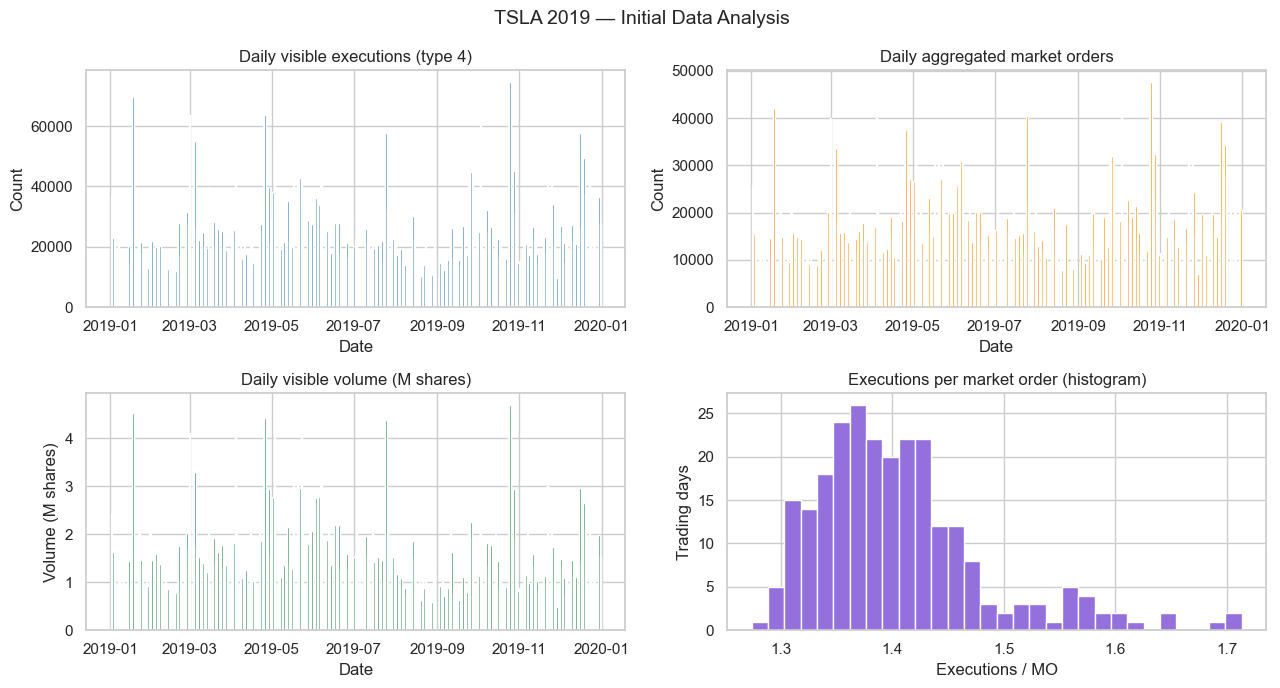

,Visible executions,Market orders,Visible volume (shares)
statistic,,,
count,252.0,252.0,252.0
mean,25809.7,18150.6,1655348.0
std,12161.6,7821.5,812439.2
min,576.0,405.0,30844.0
25%,17430.2,12813.2,1120000.5
50%,22610.0,16034.5,1462074.5
75%,29970.2,20995.8,1927565.8
max,74718.0,47701.0,4699501.0


In [173]:
# ── Daily-level statistics ─────────────────────────────────────────────────────
summary = pd.read_csv(prepared.daily_summary, parse_dates=["date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("TSLA 2019 — Initial Data Analysis", fontsize=14)

# 1. Daily visible-execution count
ax = axes[0, 0]
ax.bar(summary["date"], summary["visible_executions"], width=1, color="steelblue")
ax.set_title("Daily visible executions (type 4)")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 2. Daily aggregated market-order count
ax = axes[0, 1]
ax.bar(summary["date"], summary["market_orders"], width=1, color="darkorange")
ax.set_title("Daily aggregated market orders")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 3. Daily visible volume (shares)
ax = axes[1, 0]
ax.bar(summary["date"], summary["visible_volume"] / 1e6, width=1, color="seagreen")
ax.set_title("Daily visible volume (M shares)")
ax.set_xlabel("Date"); ax.set_ylabel("Volume (M shares)")

# 4. Average executions per market order
ratio = summary["visible_executions"] / summary["market_orders"].clip(lower=1)
ax = axes[1, 1]
ax.hist(ratio, bins=30, color="mediumpurple", edgecolor="white")
ax.set_title("Executions per market order (histogram)")
ax.set_xlabel("Executions / MO"); ax.set_ylabel("Trading days")

plt.tight_layout()
plt.show()

# Descriptive statistics table
desc = summary[["visible_executions", "market_orders", "visible_volume"]].describe().round(1)
desc.index.name = "statistic"
desc.columns = ["Visible executions", "Market orders", "Visible volume (shares)"]
display(desc)

### 1.2 Limit Order Book, Spread and Visible Depth

> The order-book reconstruction corresponding to the sticky-price analysis
> is reproduced in **Section 8.4 — Sticky Price and Visible Depth**.

Executions sharing the exact same timestamp and initiating sign are grouped
together: a market order may consume several resting limit orders.  Timestamp
aggregation follows the transaction reconstruction used by Patzelt and Bouchaud
(2017) when exchange trade IDs are unavailable.  The analysis is intentionally
scoped to visible LOBSTER type-4 executions because this is the scope used by
the course notebook. Hidden executions are intentionally out of scope.

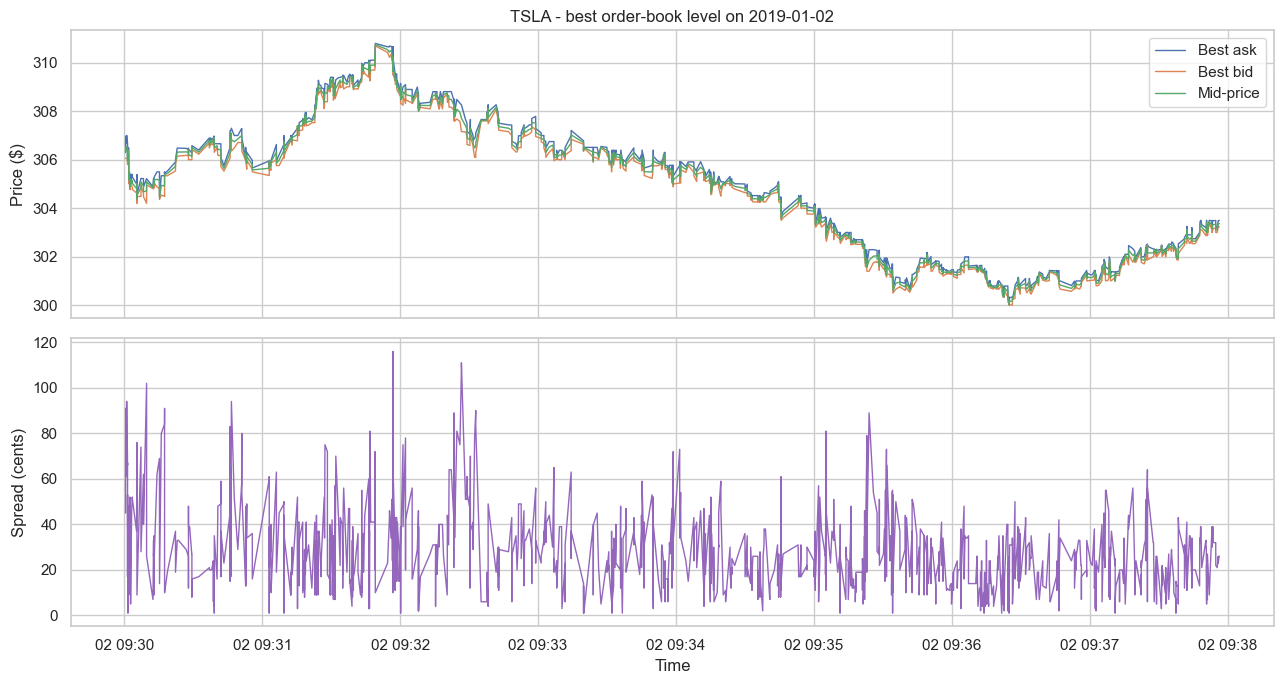

In [174]:
sample_date = summary.loc[0, "date"].strftime("%Y-%m-%d")
sample = trades[trades["date"].eq(sample_date)].head(2_000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(sample["timestamp"], sample["ask_price_1_before"], label="Best ask", lw=1)
axes[0].plot(sample["timestamp"], sample["bid_price_1_before"], label="Best bid", lw=1)
axes[0].plot(sample["timestamp"], sample["mid_price_before"], label="Mid-price", lw=1)
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{SYMBOL} - best order-book level on {sample_date}")
axes[0].legend()
axes[1].plot(sample["timestamp"], sample["spread_before"] * 100, color="tab:purple", lw=1)
axes[1].set_ylabel("Spread (cents)")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

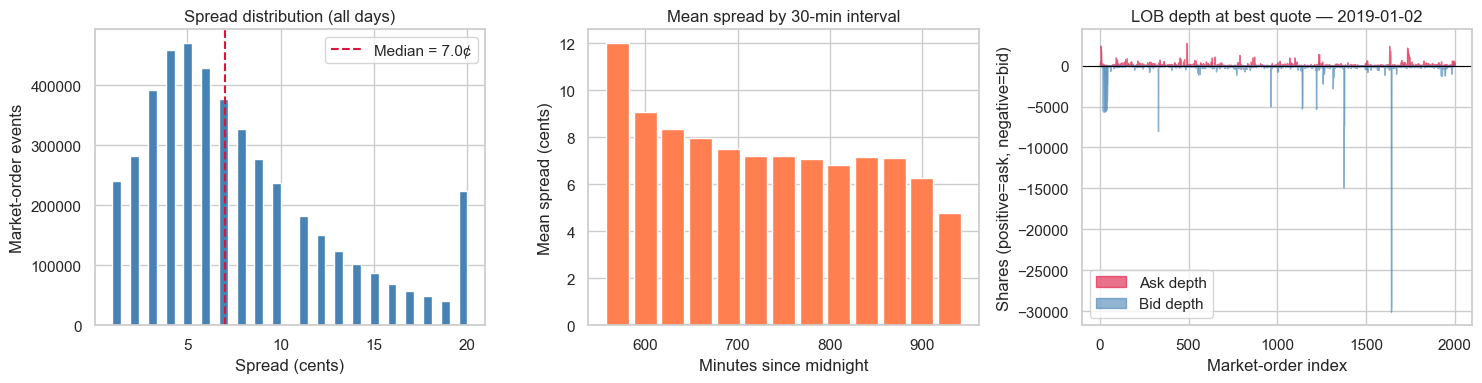

,TSLA 2019
Mean spread (cents),8.016
Median spread (cents),7.000
Std spread (cents),6.147
Fraction at 1-tick spread,0.053
Fraction at 2-tick spread,0.062


In [175]:
# ── LOB depth snapshot and spread statistics ───────────────────────────────────
sample_date = summary.loc[0, "date"].strftime("%Y-%m-%d")
sample = trades[trades["date"].eq(sample_date)].copy()

# --- Spread distribution across all 252 days ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
spread_cents = trades["spread_before"] * 100
ax.hist(spread_cents.clip(0, 20), bins=40, color="steelblue", edgecolor="white")
ax.set_title("Spread distribution (all days)")
ax.set_xlabel("Spread (cents)")
ax.set_ylabel("Market-order events")
ax.axvline(spread_cents.median(), color="crimson", ls="--", label=f"Median = {spread_cents.median():.1f}¢")
ax.legend()

# --- Average spread by half-hour intraday (U-shape) ---
ax = axes[1]
if "timestamp" in trades.columns:
    intraday = trades.copy()
    # seconds is time since midnight (LOBSTER convention)
    intraday["minute"] = (intraday["seconds"] // 60).astype(int)
    intraday["half_hour"] = (intraday["minute"] // 30) * 30
    intraday_spread = intraday.groupby("half_hour")["spread_before"].mean() * 100
    ax.bar(intraday_spread.index, intraday_spread.values, width=25, color="coral")
    ax.set_title("Mean spread by 30-min interval")
    ax.set_xlabel("Minutes since midnight")
    ax.set_ylabel("Mean spread (cents)")
else:
    ax.text(0.5, 0.5, "timestamp not available", ha="center", va="center")

# --- LOB depth (ask_size + bid_size) at level 1 for sample day ---
ax = axes[2]
sample2k = sample.head(2000)
ax.fill_between(range(len(sample2k)), sample2k["ask_size_1_before"],
                label="Ask depth", alpha=0.6, color="crimson")
ax.fill_between(range(len(sample2k)), -sample2k["bid_size_1_before"],
                label="Bid depth", alpha=0.6, color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"LOB depth at best quote — {sample_date}")
ax.set_xlabel("Market-order index")
ax.set_ylabel("Shares (positive=ask, negative=bid)")
ax.legend()

plt.tight_layout()
plt.show()

spread_stats = pd.Series({
    "Mean spread (cents)": spread_cents.mean(),
    "Median spread (cents)": spread_cents.median(),
    "Std spread (cents)": spread_cents.std(),
    "Fraction at 1-tick spread": (spread_cents < 1.5).mean(),
    "Fraction at 2-tick spread": ((spread_cents >= 1.5) & (spread_cents < 2.5)).mean(),
}, name="TSLA 2019")
display(spread_stats.round(3).to_frame())

## 2. Returns and Stylised Facts - Tuesday

### 2.1 Event-time Returns and Aggregate Gaussianity

The **event-time log return** over a horizon $\ell$ market orders is:

$$
r_t(\ell) = \log m_{t+\ell} - \log m_t.
$$

Two canonical stylised facts *(Cont 2001; Bouchaud et al. 2003)*:

1. **Heavy tails / non-Gaussianity at high frequency.** The distribution of
   $r_t(1)$ has excess kurtosis. As $\ell$ increases the distribution converges
   toward a Gaussian: this is aggregate Gaussianity.

2. **Long-range correlations.** Market-order signs are positively
   auto-correlated over many events. Return magnitudes are also positively
   auto-correlated, which is the volatility-clustering effect.

We illustrate both on the first 20 trading days for a fast exploratory view.
The article-replication section below uses the full filtered annual sample.

In [176]:

def _trade_sort_columns(data: pd.DataFrame, include_date: bool = True) -> list[str]:
    """Return sort key for deterministic event ordering within a day."""
    columns = ["date"] if include_date else []
    if "first_event_row" in data.columns:
        return columns + ["first_event_row"]
    return columns + ["seconds", "trade_sign"]


IMPACT_MID_PRICE_COLUMN = "mid_price_before"
IMPACT_SPREAD_COLUMN = "spread_before"
TEACHER_MID_PRICE_COLUMN = "mid_price_after"
TEACHER_SPREAD_COLUMN = "spread_after"


def add_lag1_features(market_orders: pd.DataFrame) -> pd.DataFrame:
    """Add one-trade-ahead pre-trade-mid impact and daily normalisation columns."""
    trades = market_orders.sort_values(_trade_sort_columns(market_orders)).copy()
    by_day = trades.groupby("date", sort=True, observed=True)
    trades["next_mid_price"] = by_day[IMPACT_MID_PRICE_COLUMN].shift(-1)
    trades["lag1_mid_change"] = trades["next_mid_price"] - trades[IMPACT_MID_PRICE_COLUMN]
    trades["lag1_signed_impact"] = trades["trade_sign"] * trades["lag1_mid_change"]
    trades["daily_volume"] = by_day["size"].transform("sum")
    trades["daily_r1"] = trades.groupby("date", observed=True)[
        "lag1_signed_impact"
    ].transform("mean")
    trades["average_same_side_queue"] = trades.groupby("date", observed=True)[
        "same_side_queue_before"
    ].transform("mean")
    trades["normalised_trade_volume"] = trades["size"] / trades["average_same_side_queue"]
    trades["normalised_lag1_impact"] = trades["lag1_signed_impact"] / trades["daily_r1"]
    return trades


def compute_event_time_returns(
    market_orders: pd.DataFrame, horizons: Sequence[int] = (1, 10, 100)
) -> pd.DataFrame:
    """Compute log returns at several market-order event-time horizons."""
    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        for date, day in market_orders.groupby("date", sort=True, observed=True):
            ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
            mid = ordered[IMPACT_MID_PRICE_COLUMN]
            values = np.log(mid.shift(-horizon)) - np.log(mid)
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "log_return": values.dropna().to_numpy(),
            }))
    return pd.concat(frames, ignore_index=True)


def autocorrelation_at_lags_by_day(
    data: pd.DataFrame, value_column: str, lags: Sequence[int]
) -> pd.DataFrame:
    """Estimate selected autocorrelation lags without crossing daily boundaries."""
    clean = data[["date", value_column]].dropna()
    mean = clean[value_column].mean()
    variance = clean[value_column].var(ddof=0)
    grouped = [
        day[value_column].to_numpy(dtype=float)
        for _, day in clean.groupby("date", sort=True, observed=True)
    ]
    rows = []
    for lag in lags:
        products = [
            (values[:-lag] - mean) * (values[lag:] - mean)
            for values in grouped if len(values) > lag
        ]
        count = sum(len(values) for values in products)
        covariance = sum(values.sum() for values in products)
        rows.append({
            "lag": int(lag),
            "autocorrelation": covariance / count / variance if count and variance else np.nan,
            "count": count,
        })
    return pd.DataFrame(rows)


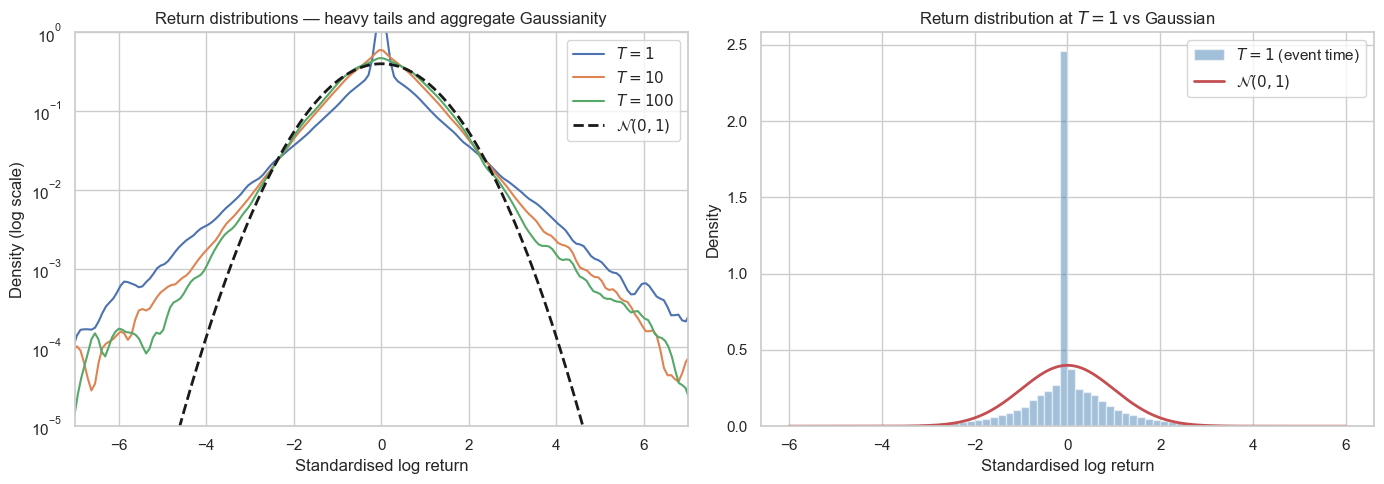

,N (returns),Skewness,Excess kurtosis,"KS stat vs N(0,1)",KS p-value
Horizon T,,,,,
1,316056,0.1399,9.8180,0.1858,0.0
10,315876,0.0983,3.1028,0.0482,0.0
100,314076,0.0406,1.7463,0.0225,0.0


In [177]:
exploratory_dates = sorted(trades["date"].unique())[:20]
exploratory = trades[trades["date"].isin(exploratory_dates)].copy()
exploratory_features = add_lag1_features(exploratory)
event_returns = compute_event_time_returns(exploratory, horizons=(1, 10, 100))
event_returns["standardised_return"] = event_returns.groupby("horizon")[
    "log_return"
].transform(lambda values: (values - values.mean()) / values.std())

# Gaussian reference grid
z = np.linspace(-6, 6, 300)
gaussian_pdf = np.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: KDE for each horizon on log-scale with Gaussian overlay ---
ax = axes[0]
for horizon, part in event_returns.groupby("horizon"):
    sns.kdeplot(
        part["standardised_return"].clip(-8, 8),
        ax=ax,
        label=f"$T={horizon}$",
        bw_adjust=1.2,
    )
ax.plot(z, gaussian_pdf, "k--", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_yscale("log")
ax.set_ylim(1e-5, 1)
ax.set_xlim(-7, 7)
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density (log scale)")
ax.legend()

# --- Right: sample histogram for T=1 on linear scale with Gaussian ---
ax = axes[1]
r1_data = event_returns.loc[event_returns["horizon"].eq(1), "standardised_return"].clip(-5, 5)
ax.hist(r1_data, bins=60, density=True, alpha=0.5, color="steelblue", label="$T=1$ (event time)")
ax.plot(z, gaussian_pdf, "r-", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
save_beamer_figure(fig, "stylized_return_distributions.png")
plt.show()

# ── Kurtosis and skewness table ────────────────────────────────────────────────
from scipy.stats import kurtosis as _kurt, skew as _skew, kstest as _ks

rows = []
for horizon, part in event_returns.groupby("horizon"):
    std = part["standardised_return"]
    stat, pval = _ks(std, "norm")
    rows.append({
        "Horizon T": int(horizon),
        "N (returns)": len(std),
        "Skewness": _skew(std),
        "Excess kurtosis": _kurt(std),
        "KS stat vs N(0,1)": stat,
        "KS p-value": pval,
    })
display(pd.DataFrame(rows).set_index("Horizon T").round(4))

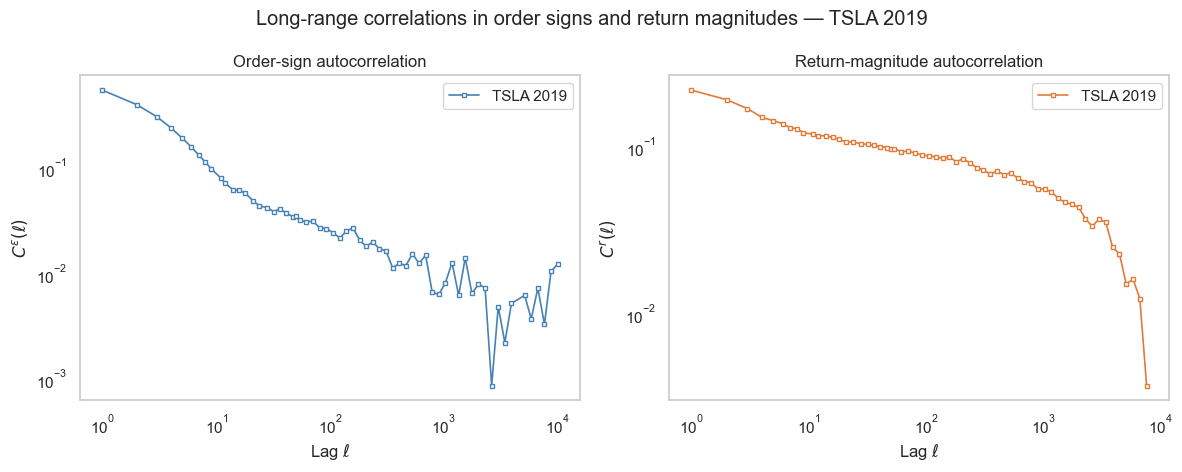

Sign ACF at lag 1:  0.5439
Sign ACF at lag 50: 0.0344
|Delta M| ACF at lag 1: 0.2180


In [178]:

# ── Long-range sign and return-magnitude autocorrelations ─────────────────────
exploratory_features["absolute_lag1_change"] = exploratory_features[
    "lag1_mid_change"
].abs()
maximum_lag = min(10_000, int(exploratory.groupby("date").size().max() // 2))
acf_lags = np.unique(np.r_[np.geomspace(1, maximum_lag, 70).astype(int), 50])
sign_acf = autocorrelation_at_lags_by_day(exploratory, "trade_sign", acf_lags)
absolute_return_acf = autocorrelation_at_lags_by_day(
    exploratory_features, "absolute_lag1_change", acf_lags
)

_acf_series = [
    (sign_acf,          "steelblue",  "$C^{\\varepsilon}(\\ell)$", "Order-sign autocorrelation"),
    (absolute_return_acf, "#e07b39",  "$C^{r}(\\ell)$",            "Return-magnitude autocorrelation"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (curve, color, ylabel, title) in zip(axes, _acf_series):
    positive = curve["autocorrelation"].gt(0)
    ax.loglog(
        curve.loc[positive, "lag"],
        curve.loc[positive, "autocorrelation"],
        marker="s", ms=3.2, mfc="white", mec=color,
        color=color, lw=1.2, label="TSLA 2019",
    )
    ax.set_xlabel("Lag $\\ell$")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", frameon=True)
    ax.grid(False)
plt.tight_layout()
save_beamer_figure(fig, "stylized_autocorrelations.png")
plt.show()

lag_50_sign = sign_acf.loc[sign_acf["lag"].eq(50), "autocorrelation"].iloc[0]
lag_1_abs = absolute_return_acf.loc[
    absolute_return_acf["lag"].eq(1), "autocorrelation"
].iloc[0]
print(f"Sign ACF at lag 1:  {sign_acf.loc[sign_acf['lag'].eq(1), 'autocorrelation'].iloc[0]:.4f}")
print(f"Sign ACF at lag 50: {lag_50_sign:.4f}")
print(f"|Delta M| ACF at lag 1: {lag_1_abs:.4f}")


### 2.2 Return-tail CCDF and Power-law Exponent

The log-scale density above reveals non-Gaussian returns. To isolate the tails,
we plot the complementary cumulative distribution function (CCDF) of absolute
standardised returns:

$$
P\left(\lvert r_t(\ell) \rvert \geq x\right).
$$

A Pareto tail $P(X \geq x) \propto x^{-\alpha}$ appears approximately linear
on log-log axes, with slope $-\alpha$. Following the power-law-tail discussion
in the lecture slides, the table estimates $\alpha$ by maximum likelihood above
the empirical 95th percentile $x_{\min}$ for each event-time horizon.

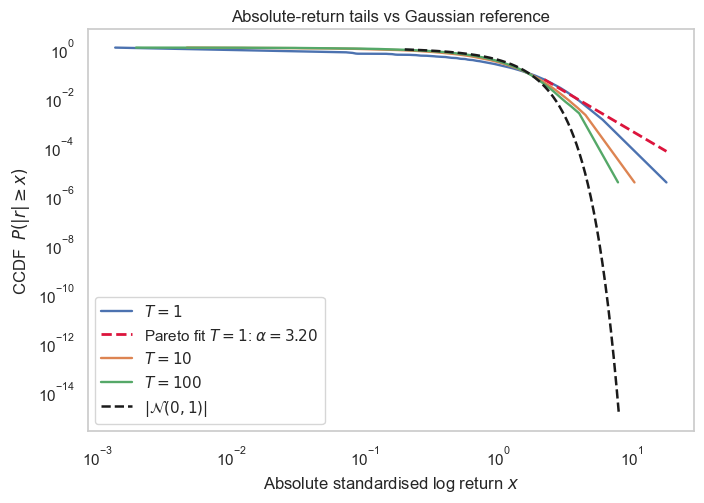

,Tail threshold quantile,x_min,N (tail returns),Tail probability,Pareto alpha (MLE),Alpha standard error
Horizon T,,,,,,
1,0.95,2.2130,15803,0.05,3.2031,0.0255
10,0.95,2.0495,15794,0.05,3.8605,0.0307
100,0.95,1.9781,15704,0.05,4.2489,0.0339


In [179]:

# ── Absolute-return CCDF and Pareto-tail estimates ────────────────────────────
from scipy.stats import norm as _norm

TAIL_QUANTILE = 0.95


def empirical_ccdf(values: pd.Series, max_points: int = 450) -> tuple[np.ndarray, np.ndarray]:
    """Return a downsampled CCDF while retaining zero returns in probabilities."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    positive = np.sort(array[array > 0])
    x, first_indices = np.unique(positive, return_index=True)
    y = (len(positive) - first_indices) / len(array)
    keep = np.unique(np.linspace(0, len(x) - 1, min(max_points, len(x))).astype(int))
    return x[keep], y[keep]


def fit_pareto_tail(values: pd.Series, quantile: float = TAIL_QUANTILE) -> dict[str, float]:
    """Fit P(X >= x) proportional to x**(-alpha) above an empirical threshold."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    threshold = float(np.quantile(array, quantile))
    tail = array[array >= threshold]
    log_excess = np.log(tail / threshold).sum()
    alpha = len(tail) / log_excess
    return {
        "Tail threshold quantile": quantile,
        "x_min": threshold,
        "N (tail returns)": len(tail),
        "Tail probability": len(tail) / len(array),
        "Pareto alpha (MLE)": alpha,
        "Alpha standard error": alpha / np.sqrt(len(tail)),
    }


fig, ax = plt.subplots(figsize=(7.2, 5.2))
tail_rows = []
tail_palette = dict(zip((1, 10, 100), sns.color_palette("deep", 3)))

for horizon, part in event_returns.groupby("horizon", sort=True):
    absolute_returns = part["standardised_return"].abs()
    x_ccdf, y_ccdf = empirical_ccdf(absolute_returns)
    fit = fit_pareto_tail(absolute_returns)
    fit["Horizon T"] = int(horizon)
    tail_rows.append(fit)
    ax.loglog(x_ccdf, y_ccdf, lw=1.7, color=tail_palette[horizon], label=f"$T={horizon}$")
    if horizon == 1:
        tail_grid = np.geomspace(fit["x_min"], x_ccdf.max(), 120)
        tail_fit = fit["Tail probability"] * (tail_grid / fit["x_min"]) ** (-fit["Pareto alpha (MLE)"])
        ax.loglog(tail_grid, tail_fit, color="crimson", ls="--", lw=2,
                  label=f"Pareto fit $T=1$: $\\alpha={fit['Pareto alpha (MLE)']:.2f}$")

gaussian_x = np.geomspace(0.20, 8, 300)
ax.loglog(gaussian_x, 2 * _norm.sf(gaussian_x), "k--", lw=1.8,
          label="$|\\mathcal{N}(0,1)|$")
ax.set_xlabel("Absolute standardised log return $x$")
ax.set_ylabel("CCDF  $P(|r| \\geq x)$")
ax.set_title("Absolute-return tails vs Gaussian reference")
ax.grid(False)
ax.legend()
plt.tight_layout()
plt.show()

tail_estimates = pd.DataFrame(tail_rows).set_index("Horizon T")
display(tail_estimates.round(4))


### 2.3 Returns at Nested Magnifications

Empirical TSLA log returns at successive zoom levels illustrate the clustered,
heavy-tailed nature of the series. The three-panel figure below applies three
zoom lengths (full sample, ×10, ×100).

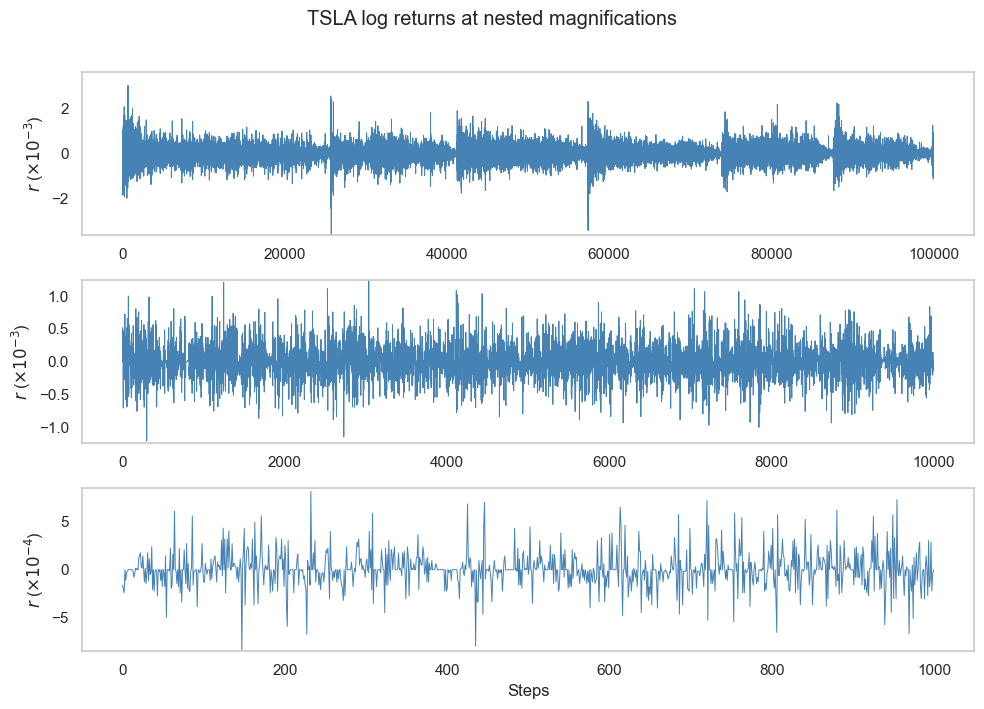

In [180]:

# ── TSLA returns at nested magnifications ────────────────────────────────────
tsla_zoom_returns = event_returns.loc[
    event_returns["horizon"].eq(1), "log_return"
].to_numpy()
n_zoom = min(100_000, len(tsla_zoom_returns))
tsla_zoom_returns = tsla_zoom_returns[:n_zoom]

fig, axes = plt.subplots(3, 1, figsize=(10, 7))
zoom_lengths = [n_zoom, min(10_000, n_zoom), min(1_000, n_zoom)]
for row, (ax, length) in enumerate(zip(axes, zoom_lengths)):
    start = max(0, (len(tsla_zoom_returns) - length) // 2)
    segment = tsla_zoom_returns[start:start + length]
    scale = np.max(np.abs(segment))
    unit_exponent = int(np.floor(np.log10(scale)))
    unit = 10.0 ** unit_exponent
    ax.plot(np.arange(length), segment / unit, color="steelblue", lw=0.7)
    ax.set_ylim(-scale / unit, scale / unit)
    ax.set_ylabel(f"$r$ ($\\times 10^{{{unit_exponent}}}$)")
    ax.grid(False)
axes[-1].set_xlabel("Steps")
plt.suptitle("TSLA log returns at nested magnifications", y=1.01)
plt.tight_layout()
plt.show()


## 3. Unconditional, Spread and Conditional Impact — Wednesday

### 3.1 Response Function $R(\ell)$

The **unconditional response function** (lecture slides, Fig 6) is:

$$
R(\ell) = \left\langle \varepsilon_t \left(m_{t+\ell} - m_t\right) \right\rangle.
$$

It measures how much the mid-price moves on average in the *same direction*
as a market order, $\ell$ trades later. Its value at $\ell = 1$:

$$
R(1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \right\rangle
$$

is the **average lag-1 impact**, used throughout as the daily normalisation.
Daily boundaries are never crossed so that day-end effects do not contaminate
the estimate.

In [181]:
def compute_response(market_orders: pd.DataFrame, max_lag: int = 50) -> pd.DataFrame:
    """Estimate pre-trade-mid unconditional response R(l) without crossing days."""
    totals = np.zeros(max_lag, dtype=float)
    counts = np.zeros(max_lag, dtype=np.int64)
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered[IMPACT_MID_PRICE_COLUMN].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        for lag in range(1, min(max_lag, len(day) - 1) + 1):
            values = signs[:-lag] * (mid[lag:] - mid[:-lag])
            valid = np.isfinite(values)
            totals[lag - 1] += values[valid].sum()
            counts[lag - 1] += valid.sum()
    response = np.divide(totals, counts, out=np.full(max_lag, np.nan), where=counts > 0)
    return pd.DataFrame({"lag": np.arange(1, max_lag + 1), "response": response, "count": counts})


def compute_spread_normalised_r1(
    market_orders: pd.DataFrame,
    mid_column: str = TEACHER_MID_PRICE_COLUMN,
    spread_column: str = TEACHER_SPREAD_COLUMN,
) -> float:
    """Teacher-notebook convention: post-trade lag-1 impact over current spread."""
    values: list[np.ndarray] = []
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        if len(ordered) < 2:
            continue
        mid = ordered[mid_column].to_numpy(dtype=float)
        spread = ordered[spread_column].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        impact = signs[:-1] * (mid[1:] - mid[:-1])
        scaled = impact / spread[:-1]
        values.append(scaled[np.isfinite(scaled)])
    return float(np.concatenate(values).mean())


def bin_conditional_impact(
    trades: pd.DataFrame,
    maximum_volume: float = 2.0,
    fine_threshold: float = 0.1,
    fine_step: float = 0.01,
    coarse_step: float = 0.1,
) -> pd.DataFrame:
    """Average raw lag-1 impact in regularised normalised-volume bins."""
    clean = trades.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["normalised_trade_volume", "lag1_signed_impact"]
    )
    fine_edges = np.arange(0.0, fine_threshold + fine_step / 2, fine_step)
    coarse_edges = np.arange(
        fine_threshold + coarse_step, maximum_volume + coarse_step / 2, coarse_step
    )
    labels = pd.cut(
        clean["normalised_trade_volume"],
        bins=np.r_[fine_edges, coarse_edges],
        include_lowest=True,
        right=False,
    )
    return (
        clean.assign(volume_bin=labels)
        .groupby("volume_bin", observed=True)
        .agg(
            normalised_trade_volume=("normalised_trade_volume", "mean"),
            lag1_signed_impact=("lag1_signed_impact", "mean"),
            observations=("lag1_signed_impact", "size"),
        )
        .reset_index(drop=True)
    )

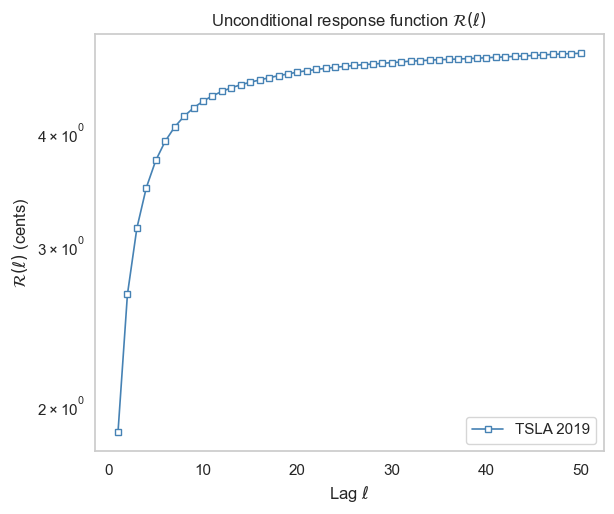

R(1) = 1.86981 cents  (0.018698 dollars)
Spread-normalised R1 = 0.14298


In [182]:

# ── Unconditional response function R(ℓ) ─────────────────────────────────────
response = compute_response(trades, max_lag=50)
r1 = response.loc[response["lag"].eq(1), "response"].iloc[0]
r1_spread_normalised = compute_spread_normalised_r1(trades)
positive_response = response["response"].clip(lower=np.finfo(float).tiny)

fig, ax = plt.subplots(figsize=(6.3, 5.3))
ax.semilogy(
    response["lag"], positive_response * 100,
    marker="s", ms=4, mfc="white", mec="steelblue", color="steelblue", lw=1.2,
    label="TSLA 2019",
)
ax.set_xlabel("Lag $\\ell$")
ax.set_ylabel("$\\mathcal{R}(\\ell)$ (cents)")
ax.set_title("Unconditional response function $\\mathcal{R}(\\ell)$")
ax.legend(loc="lower right", frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"R(1) = {r1 * 100:.5f} cents  ({r1:.6f} dollars)")
print(f"Spread-normalised R1 = {r1_spread_normalised:.5f}")


In [183]:
features = add_lag1_features(trades)
daily_r1 = (
    features.groupby("date", observed=True)
    .agg(
        daily_r1=("daily_r1", "first"),
        daily_volume=("daily_volume", "first"),
        trades=("size", "size"),
    )
    .reset_index()
)
positive_daily_r1 = daily_r1.loc[daily_r1["daily_r1"] > 0, "daily_r1"]
r1_floor = positive_daily_r1.quantile(0.05)
stable_features = features[features["daily_r1"] >= r1_floor].copy()

display(daily_r1.describe())
print(
    "Stability filter for daily normalisations: "
    f"R(1) >= {r1_floor * 100:.6f} cents."
)

,daily_r1,daily_volume,trades
count,252.000000,2.520000e+02,252.000000
mean,0.019369,1.655348e+06,18150.623016
std,0.006318,8.124392e+05,7821.517064
min,0.010243,3.084400e+04,405.000000
25%,0.015432,1.120000e+06,12813.250000
50%,0.018458,1.462074e+06,16034.500000
75%,0.021168,1.927566e+06,20995.750000
max,0.080371,4.699501e+06,47701.000000


Stability filter for daily normalisations: R(1) >= 1.305750 cents.


### 3.2 Temporal Spread-Impact Linearity

With TSLA alone we cannot test the cross-sectional claim that stocks with wider
average spreads have larger average impacts. Instead, we test the within-stock
version: when TSLA is in a wider-spread liquidity state during 2019, is its
average instantaneous impact also higher?

$$
R_1^{(w)} = \alpha + \beta \langle s \rangle_w + u_w.
$$

The windows $w$ below are daily, weekly, monthly and intraday blocks. The
intraday regressions are also repeated with volatility, visible best-level
depth and time-of-day fixed effects, because the open and close can mechanically
raise both spread and impact.

,period,observations,beta: R1 dollars per spread dollar,alpha (cents),R^2,"corr(R1, spread)",median R1/spread,IQR R1/spread,mean orders/window
0,Daily,252,0.2654,-0.2296,0.8372,0.9150,0.2335,0.0339,18149.6230
1,Weekly,53,0.2343,0.0027,0.8513,0.9227,0.2311,0.0349,86296.3208
2,Monthly,12,0.2576,-0.1885,0.8653,0.9302,0.2262,0.0299,381142.0833
3,30-min intraday,3244,0.2445,-0.0814,0.8149,0.9027,0.2307,0.0495,1409.8076
4,60-min intraday,1747,0.2485,-0.1174,0.8458,0.9197,0.2299,0.0455,2617.9319


,period,observations,controlled beta,controlled alpha (cents),controlled R^2,median R1/spread
0,30-min intraday,3244,-0.0653,0.0402,0.9610,0.2307
1,60-min intraday,1747,-0.0694,0.0606,0.9665,0.2299


Controlled intraday spread slopes after volatility, depth and time-of-day fixed effects: 30-min intraday: -0.0653, 60-min intraday: -0.0694.


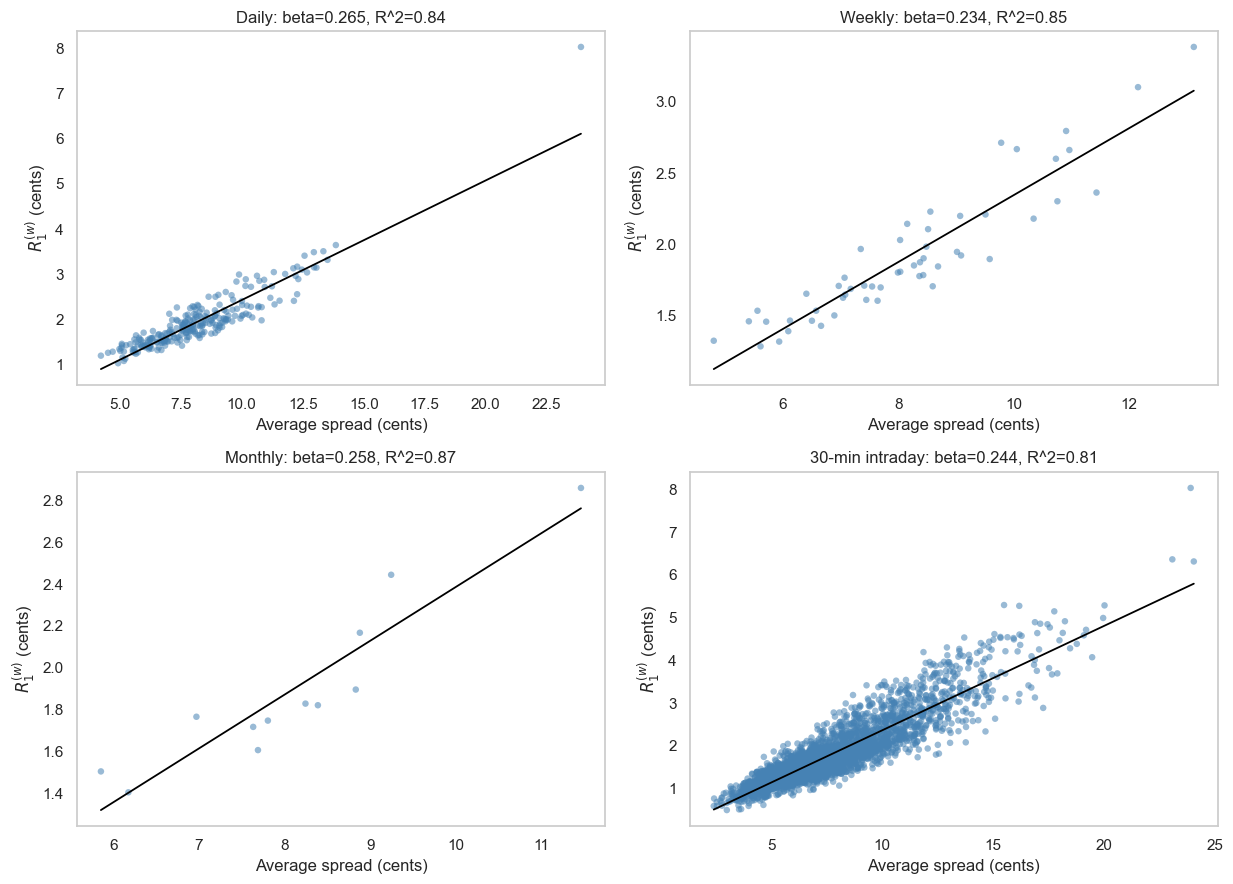

All simple-window spread slopes are positive: True. Median R1/spread across all windows = 0.2305.


In [184]:
# ── Temporal spread-impact relation R1(w) vs <s>(w) ───────────────────────
def make_spread_impact_windows(
    feature_frame: pd.DataFrame,
    window: str,
    minimum_orders: int = 100,
) -> pd.DataFrame:
    """Aggregate lag-1 impact, spread and controls in calendar or intraday windows."""
    required = [
        "date", "timestamp", "seconds", "lag1_signed_impact", "lag1_mid_change",
        IMPACT_SPREAD_COLUMN, "ask_size_1_before", "bid_size_1_before",
    ]
    data = feature_frame[required].copy()
    numeric_required = [column for column in required if column != "date"]
    data[numeric_required] = data[numeric_required].replace([np.inf, -np.inf], np.nan)
    data = data.dropna(
        subset=["lag1_signed_impact", "lag1_mid_change", IMPACT_SPREAD_COLUMN]
    ).copy()
    data = data[data[IMPACT_SPREAD_COLUMN] > 0].copy()
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data["best_depth_before"] = data["ask_size_1_before"] + data["bid_size_1_before"]

    if window == "day":
        group_columns = ["date"]
        data["window_label"] = data["date"].astype(str)
        period_label = "Daily"
    elif window == "week":
        data["week"] = data["timestamp"].dt.to_period("W-FRI").astype(str)
        group_columns = ["week"]
        data["window_label"] = data["week"]
        period_label = "Weekly"
    elif window == "month":
        data["month"] = data["timestamp"].dt.to_period("M").astype(str)
        group_columns = ["month"]
        data["window_label"] = data["month"]
        period_label = "Monthly"
    elif window.endswith("min"):
        minutes = int(window.removesuffix("min"))
        bin_seconds = minutes * 60
        bin_index = np.floor(
            (data["seconds"] - ANALYSIS_WINDOW_START_SECONDS) / bin_seconds
        ).astype(int)
        data["time_of_day_bin"] = bin_index.clip(lower=0)
        data["window_label"] = (
            data["date"].astype(str) + " #" + data["time_of_day_bin"].astype(str)
        )
        group_columns = ["date", "time_of_day_bin"]
        period_label = f"{minutes}-min intraday"
    else:
        raise ValueError(f"Unsupported window: {window}")

    aggregated = (
        data.groupby(group_columns, sort=True, observed=True)
        .agg(
            window_label=("window_label", "first"),
            r1=("lag1_signed_impact", "mean"),
            average_spread=(IMPACT_SPREAD_COLUMN, "mean"),
            sigma=("lag1_mid_change", "std"),
            average_depth=("best_depth_before", "mean"),
            orders=("lag1_signed_impact", "size"),
        )
        .reset_index()
    )
    aggregated = aggregated[aggregated["orders"] >= minimum_orders].copy()
    aggregated["period"] = period_label
    aggregated["window"] = window
    aggregated["r1_cents"] = aggregated["r1"] * 100
    aggregated["average_spread_cents"] = aggregated["average_spread"] * 100
    aggregated["sigma_cents"] = aggregated["sigma"] * 100
    aggregated["average_depth_kshares"] = aggregated["average_depth"] / 1_000
    aggregated["r1_to_spread"] = aggregated["r1"] / aggregated["average_spread"]
    return aggregated


def fit_window_regression(
    data: pd.DataFrame,
    controls: bool = False,
    fixed_effect_column: str | None = None,
) -> dict[str, float]:
    """OLS regression of window-level R1 on average spread, with optional controls."""
    columns = ["r1", "average_spread"]
    if controls:
        columns += ["sigma_cents", "average_depth_kshares"]
    if fixed_effect_column is not None:
        columns.append(fixed_effect_column)
    clean = data.copy()
    numeric_columns = [
        column for column in columns
        if column != fixed_effect_column and pd.api.types.is_numeric_dtype(clean[column])
    ]
    clean[numeric_columns] = clean[numeric_columns].replace([np.inf, -np.inf], np.nan)
    clean = clean.dropna(subset=columns).copy()
    y = clean["r1"].to_numpy(dtype=float)
    x_parts = [np.ones(len(clean)), clean["average_spread"].to_numpy(dtype=float)]
    names = ["alpha", "beta_spread"]
    if controls:
        x_parts.extend([
            clean["sigma_cents"].to_numpy(dtype=float),
            clean["average_depth_kshares"].to_numpy(dtype=float),
        ])
        names.extend(["gamma_sigma", "delta_depth"])
    if fixed_effect_column is not None:
        dummies = pd.get_dummies(
            clean[fixed_effect_column].astype(str), drop_first=True, dtype=float
        )
        if not dummies.empty:
            x_parts.extend([dummies[column].to_numpy(dtype=float) for column in dummies])
            names.extend([f"fe_{column}" for column in dummies])
    x = np.column_stack(x_parts)
    coefficients, *_ = np.linalg.lstsq(x, y, rcond=None)
    fitted = x @ coefficients
    residual = y - fitted
    sse = float(np.square(residual).sum())
    sst = float(np.square(y - y.mean()).sum())
    result = dict(zip(names, coefficients))
    result.update({
        "observations": int(len(clean)),
        "r_squared": 1 - sse / sst if sst > 0 else np.nan,
        "spread_impact_corr": clean["average_spread"].corr(clean["r1"]),
        "median_r1_to_spread": clean["r1_to_spread"].median(),
        "iqr_r1_to_spread": (
            clean["r1_to_spread"].quantile(0.75)
            - clean["r1_to_spread"].quantile(0.25)
        ),
        "mean_orders_per_window": clean["orders"].mean(),
    })
    return result


spread_window_specs = [
    ("day", 100),
    ("week", 500),
    ("month", 1_000),
    ("30min", 100),
    ("60min", 100),
]
spread_impact_windows = pd.concat(
    [make_spread_impact_windows(features, window, minimum_orders)
     for window, minimum_orders in spread_window_specs],
    ignore_index=True,
)

simple_regression_rows = []
controlled_regression_rows = []
for period, part in spread_impact_windows.groupby("period", sort=False, observed=True):
    fit = fit_window_regression(part)
    fit.update({"period": period, "model": "simple"})
    simple_regression_rows.append(fit)
    if "intraday" in period:
        controlled = fit_window_regression(
            part, controls=True, fixed_effect_column="time_of_day_bin"
        )
        controlled.update({"period": period, "model": "controls + time FE"})
        controlled_regression_rows.append(controlled)

spread_impact_regressions = pd.DataFrame(simple_regression_rows)
spread_impact_controlled = pd.DataFrame(controlled_regression_rows)

display_columns = [
    "period", "observations", "beta_spread", "alpha", "r_squared",
    "spread_impact_corr", "median_r1_to_spread", "iqr_r1_to_spread",
    "mean_orders_per_window",
]
summary_display = spread_impact_regressions[display_columns].copy()
summary_display["alpha"] *= 100
summary_display = summary_display.rename(columns={
    "beta_spread": "beta: R1 dollars per spread dollar",
    "alpha": "alpha (cents)",
    "r_squared": "R^2",
    "spread_impact_corr": "corr(R1, spread)",
    "median_r1_to_spread": "median R1/spread",
    "iqr_r1_to_spread": "IQR R1/spread",
    "mean_orders_per_window": "mean orders/window",
})
display(summary_display.round(4))

if not spread_impact_controlled.empty:
    controlled_display = spread_impact_controlled[[
        "period", "observations", "beta_spread", "alpha", "r_squared",
        "median_r1_to_spread",
    ]].copy()
    controlled_display["alpha"] *= 100
    controlled_display = controlled_display.rename(columns={
        "beta_spread": "controlled beta",
        "alpha": "controlled alpha (cents)",
        "r_squared": "controlled R^2",
        "median_r1_to_spread": "median R1/spread",
    })
    display(controlled_display.round(4))
    controlled_beta_text = ", ".join(
        f"{row.period}: {row.beta_spread:.4f}"
        for row in spread_impact_controlled.itertuples(index=False)
    )
    print(
        "Controlled intraday spread slopes after volatility, depth and time-of-day "
        f"fixed effects: {controlled_beta_text}."
    )

plot_periods = ["Daily", "Weekly", "Monthly", "30-min intraday"]
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9))
axes = axes.ravel()
fit_lookup = spread_impact_regressions.set_index("period")
for ax, period in zip(axes, plot_periods):
    part = spread_impact_windows[spread_impact_windows["period"].eq(period)]
    fit = fit_lookup.loc[period]
    ax.scatter(
        part["average_spread_cents"], part["r1_cents"],
        s=22, alpha=0.55, color="steelblue", edgecolors="none",
    )
    x_grid = np.linspace(
        part["average_spread"].min(), part["average_spread"].max(), 100
    )
    y_grid = fit["alpha"] + fit["beta_spread"] * x_grid
    ax.plot(x_grid * 100, y_grid * 100, color="black", lw=1.3)
    ax.set_xlabel("Average spread (cents)")
    ax.set_ylabel("$R_1^{(w)}$ (cents)")
    ax.grid(False)
plt.tight_layout()
save_beamer_figure(fig, "spread_impact_windows.png")
plt.show()

positive_betas = (spread_impact_regressions["beta_spread"] > 0).all()
print(
    "All simple-window spread slopes are positive: "
    f"{positive_betas}. Median R1/spread across all windows = "
    f"{spread_impact_windows['r1_to_spread'].median():.4f}."
)

(done) NOTE FOR LATEX: ADD SECTION 3.2 FIGURE IN A SLIDE:

Explanation (what to say): read explanation1.md. 
Write the most important points on the slide (so that everything fits): interpretation, intuition, a bit of quantitative
MUST SAY: "R(1) seems proportional to the average spread ⟨s⟩. This could be explained by our earlier discussion of market makers’ compensation for adverse selection – MMs attempt to earn the bid-ask spread but are challenged by adverse price movement caused by the MOs impact."



### 3.3 Lag-1 Conditional Impact $R(\upsilon, 1)$

The **lag-1 conditional impact** quantifies how impact depends on the
normalised market-order volume:

$$
R(\upsilon, 1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \,\middle|\, \upsilon_t = \upsilon \right\rangle,
$$

where $\upsilon_t = v_t / \bar{q}_t$ is the ratio of the executed volume to
the average depth on the same side of the book on that day.

Empirically (lecture slides, Fig 7–8), this relationship is **sub-linear**:

$$
R(\upsilon, 1) \approx A \cdot \upsilon^{\,\zeta}, \qquad \zeta \ll 1.
$$

The concave curves in Fig 7 are for the large-tick stocks CSCO and INTC.
TSLA appears in Fig 8 as a small-tick stock: its dependence on volume is much
fainter and can be almost flat. The plot below therefore reports raw impact in
cents rather than forcing a vertical normalisation by daily $R(1)$.

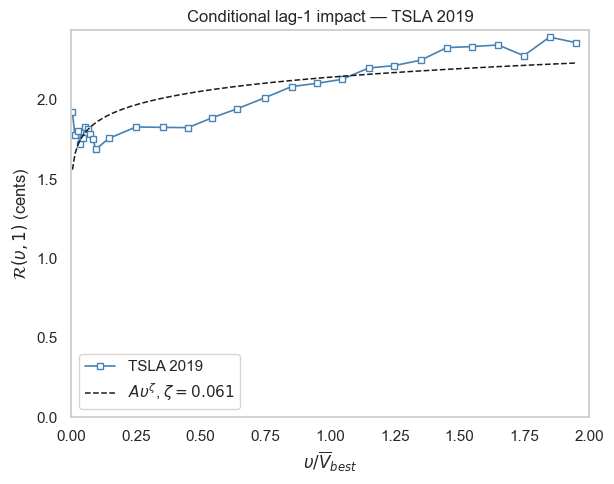

Power-law fit over 0 < υ / V_best < 2: A = 0.02142,  zeta = 0.0612


In [185]:
# ── Conditional lag-1 impact R(υ, 1) ─────────────────────────────────────────
# Normalise within each day before pooling so between-day volatility variation
# does not flatten the volume-impact curve.  Use stable_features (daily R(1) >=
# r1_floor) to exclude noisy low-impact days.
from scipy.optimize import curve_fit

_norm = stable_features.copy()
_norm["lag1_signed_impact"] = _norm["normalised_lag1_impact"]   # divide by daily R(1)
conditional_curve = bin_conditional_impact(_norm)
conditional_curve["lag1_signed_impact"] *= r1                   # scale back to price units

mask = (
    conditional_curve["normalised_trade_volume"].gt(0)
    & conditional_curve["lag1_signed_impact"].gt(0)
)
xdata = conditional_curve.loc[mask, "normalised_trade_volume"].to_numpy()
ydata = conditional_curve.loc[mask, "lag1_signed_impact"].to_numpy()

try:
    popt, _ = curve_fit(
        lambda x, A, zeta: A * np.power(x, zeta),
        xdata, ydata, p0=[0.02, 0.3], maxfev=10_000,
    )
    A_fit, zeta_fit = popt
    has_fit = True
except Exception:
    A_fit, zeta_fit, has_fit = np.nan, np.nan, False

fig, ax = plt.subplots(figsize=(6.3, 5.0))
ax.plot(
    conditional_curve["normalised_trade_volume"],
    conditional_curve["lag1_signed_impact"] * 100,
    marker="s", ms=4, mfc="white", mec="steelblue", color="steelblue", lw=1.2,
    label="TSLA 2019",
)
if has_fit:
    xgrid = np.linspace(max(xdata.min(), 1e-6), xdata.max(), 200)
    ax.plot(xgrid, A_fit * xgrid ** zeta_fit * 100, "k--", lw=1.1,
            label=f"$A\\upsilon^\\zeta$, $\\zeta={zeta_fit:.3f}$")
ax.set_xlim(0, 2)
ax.set_ylim(bottom=0)
ax.set_xlabel("$\\upsilon / \\overline{V}_{best}$")
ax.set_ylabel("$\\mathcal{R}(\\upsilon,1)$ (cents)")
ax.set_title("Conditional lag-1 impact — TSLA 2019")
ax.legend(loc="best")
ax.grid(False)
plt.tight_layout()
plt.show()

if has_fit:
    print(f"Power-law fit over 0 < υ / V_best < 2: A = {A_fit:.5f},  zeta = {zeta_fit:.4f}")


## 4. Aggregate Impact — Wednesday

### 4.1 Coarse-graining over $T$ consecutive market orders

Instead of looking trade by trade, we aggregate over windows of $T$ successive
market orders from the same day:

$$
\Delta\varepsilon(T) = \sum_{n=t}^{t+T-1} \varepsilon_n
\qquad (\text{order-sign imbalance}),
$$

$$
\Delta V(T) = \sum_{n=t}^{t+T-1} \varepsilon_n \, v_n
\qquad (\text{signed volume imbalance}),
$$

$$
R(\Delta V, T) = \left\langle m_{t+T} - m_t \,\middle|\, \Delta V \right\rangle.
$$

Non-overlapping windows (`stride = horizon`) are used to preserve independence
across observations and keep the annual dataset tractable. We normalise:

$$
\widetilde{\Delta V} = \frac{\Delta V}{V_D}, \quad
\widetilde{R} = \frac{R(\Delta V, T)}{R(1)},
$$

where $V_D$ is the daily traded volume and $R(1)$ is the daily lag-1 impact.

### 4.2 Expected shape from Patzelt & Bouchaud (2017)

The aggregate impact curve $R(\Delta V, T)$ is *concave* for small $T$ and
becomes more *linear* for large $T$. This behaviour is captured by the
sigmoidal master curve (section 5). The raw scatter — before quantile binning
— shows that large $|\Delta V|$ values are not associated with large returns:
the price is **"pinned"** when order flow is extreme (liquidity games).

In [186]:
def compute_aggregate_windows(
    trades: pd.DataFrame,
    horizons: Sequence[int] = (5, 10, 20, 50, 100),
    stride: str | int = "horizon",
) -> pd.DataFrame:
    """Compute coarse-grained signed imbalances and impact within each day.

    Non-overlapping windows (stride == "horizon") match the coarse-graining
    operation from the lecture slides while keeping the annual dataset tractable.
    Pass stride=1 to enumerate every overlapping window.
    """
    frames: list[pd.DataFrame] = []
    for date, day in trades.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered[IMPACT_MID_PRICE_COLUMN].to_numpy(dtype=float)
        size = ordered["size"].to_numpy(dtype=float)
        sign = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = size * sign
        daily_volume = size.sum()
        daily_r1 = ordered["lag1_signed_impact"].mean()
        if not np.isfinite(daily_r1) or daily_r1 <= 0 or daily_volume <= 0:
            continue
        sv_cs = np.r_[0.0, np.cumsum(signed_volume)]
        s_cs  = np.r_[0.0, np.cumsum(sign)]
        for horizon in horizons:
            step = horizon if stride == "horizon" else int(stride)
            starts = np.arange(0, len(ordered) - horizon, step)
            if not len(starts):
                continue
            stops = starts + horizon
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "volume_imbalance":           sv_cs[stops] - sv_cs[starts],
                "order_flow_imbalance":       s_cs[stops]  - s_cs[starts],
                "impact":                     mid[stops]   - mid[starts],
                "daily_volume":               daily_volume,
                "daily_r1":                   daily_r1,
                "normalised_volume_imbalance":(sv_cs[stops] - sv_cs[starts]) / daily_volume,
                "normalised_impact":          (mid[stops]   - mid[starts])   / daily_r1,
            }))
    return pd.concat(frames, ignore_index=True)


def quantile_impact_curve(windows: pd.DataFrame, quantiles: int = 31) -> pd.DataFrame:
    """Denoise aggregate impact with separate imbalance quantiles for each T."""
    frames: list[pd.DataFrame] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(part["normalised_volume_imbalance"], q=quantiles, duplicates="drop")
        curve = (
            part.assign(imbalance_bin=labels)
            .groupby("imbalance_bin", observed=True)
            .agg(
                normalised_volume_imbalance=("normalised_volume_imbalance", "mean"),
                normalised_impact=("normalised_impact", "mean"),
                impact=("impact", "mean"),
                volume_imbalance=("volume_imbalance", "mean"),
                observations=("normalised_impact", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)

In [187]:
HORIZONS = (5, 10, 20, 50, 100)
windows = compute_aggregate_windows(
    stable_features,
    horizons=HORIZONS,
    stride="horizon",
)
impact_curve = quantile_impact_curve(windows, quantiles=31)

display(windows.groupby("horizon").size().rename("windows").to_frame())

,windows
horizon,
5,846449
10,423165
20,211530
50,84543
100,42212


### 4.3 Figure-style view by horizon

The reference figure is worth adding because it separates the raw cents impact
by horizon instead of overlaying every $T$ on one axis. To keep the empirical
conditional mean readable, the panels below use denser quantile averages
($101$ bins) rather than plotting every coarse-grained window.

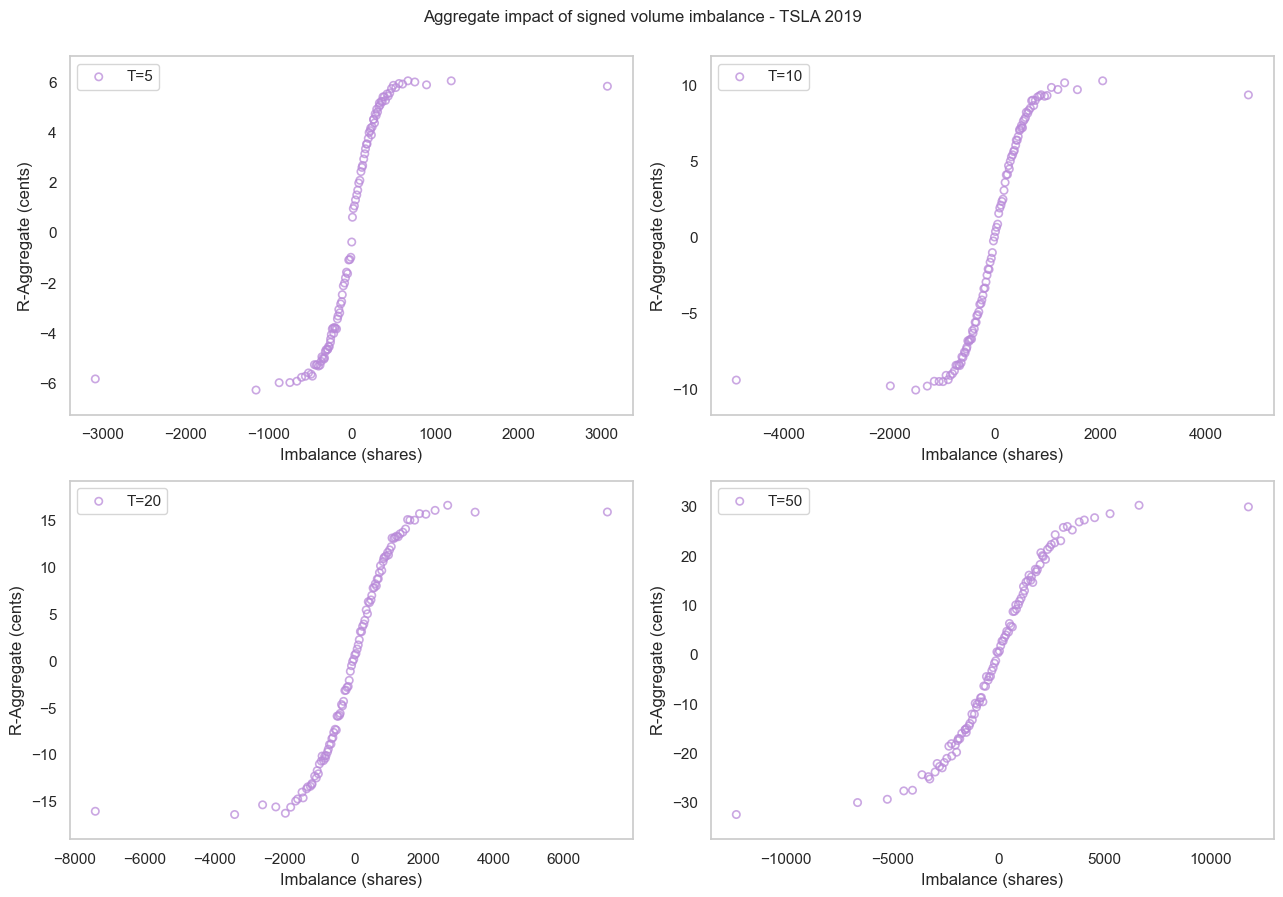

In [188]:
# Figure 6 analogue: aggregate impact by horizon
figure6_horizons = (5, 10, 20, 50)
figure6_curve = quantile_impact_curve(
    windows[windows["horizon"].isin(figure6_horizons)],
    quantiles=101,
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
marker_color = "#b98ad9"

for ax, horizon in zip(axes, figure6_horizons):
    part = figure6_curve[figure6_curve["horizon"].eq(horizon)]
    ax.scatter(
        part["volume_imbalance"],
        part["impact"] * 100,
        s=28,
        facecolors="none",
        edgecolors=marker_color,
        linewidths=1.2,
        alpha=0.75,
        label=f"T={horizon}",
    )
    ax.set_xlabel("Imbalance (shares)")
    ax.set_ylabel("R-Aggregate (cents)")
    ax.legend(loc="upper left", frameon=True)
    ax.grid(False)
    ax.margins(x=0.05, y=0.08)

plt.tight_layout()
save_beamer_figure(fig, "aggregate_impact_by_horizon.png")
plt.show()

(done) NOTE FOR LATEX: ADD SECTION 4.3 FIGURE IN A SLIDE:

What to say:
Imbalance amplitude increases with T – as we aggregate the eﬀect of more trades, the order-flow imbalance increases in absolute value as well. For instance, when observing the impact of T = 5 MOs, imbalance ranges from around -3000 to 3000. However, once T is increased to 10, imbalance scope expands to reaching 4000 shares in absolute value. Interestingly, the functional form of relationship seems the same for all T despite diﬀerent scales
With increase in |∆V|(absolute value of order-flow imbalance) the relation-ship takes on a more concave (rather than linear) form, similar to our pre- vious analysis of lag-1 response function conditioned on normalised volume. Again, this may be attributed to the selective liquidity bias

### 4.4 Distribution view for $T=10$

The companion distribution figure follows the paper-style preprocessing. We
start from the raw non-overlapping $T=10$ windows, remove observations where
either imbalance or aggregate response lies beyond $3$ standard deviations,
then subsample by equal-width imbalance bins and average each bin. This is not
the raw empirical density of all windows: it is the density of the denoised
aggregate-impact curve points, which is the object used for the visual
interpretation in the reference figure.

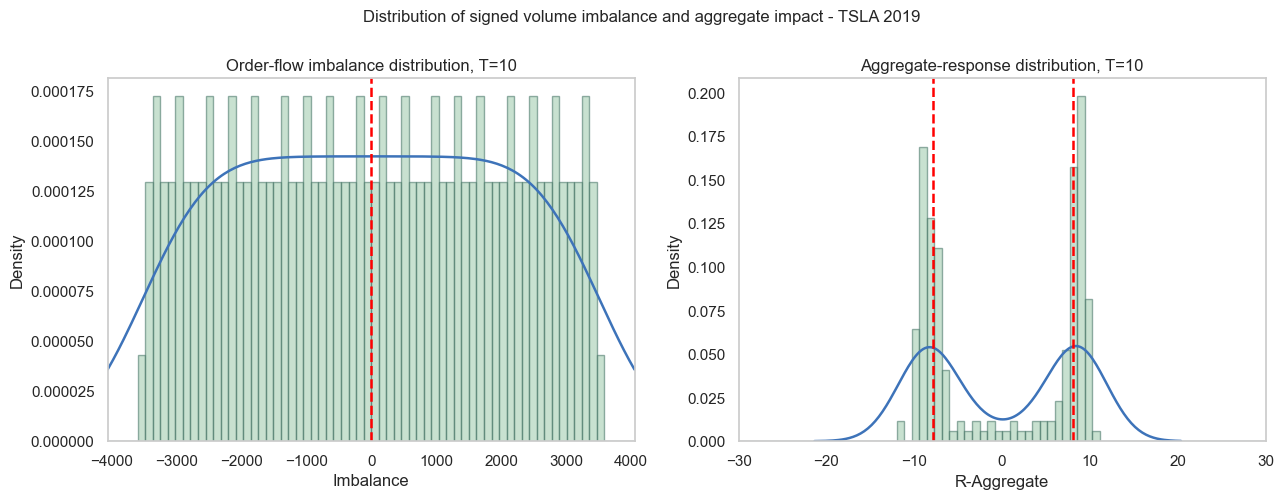

,T=10 distribution summary
raw T=10 windows,423165.000000
after 3-sigma filter,412849.000000
equal-width bins,200.000000
curve points plotted,200.000000
minimum observations per plotted bin,37.000000
mean imbalance (shares),-1.468697
mean negative R-Aggregate (cents),-7.904828
mean positive R-Aggregate (cents),8.022269


In [189]:
# Figure 8 analogue: T=10 distributions after 3-sigma filtering and binned subsampling
figure8_horizon = 10
FIGURE8_SIGMA_CLIP = 3.0
FIGURE8_IMBALANCE_BINS = 200
FIGURE8_MIN_BIN_OBSERVATIONS = 20
FIGURE8_HIST_BINS = 70
FIGURE8_RESPONSE_XLIM = (-30.0, 30.0)

figure8_raw = (
    windows.loc[windows["horizon"].eq(figure8_horizon), ["volume_imbalance", "impact"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)
figure8_raw["impact_cents"] = figure8_raw["impact"] * 100

def sigma_clip_frame(
    frame: pd.DataFrame, columns: Sequence[str], sigma: float = 3.0
) -> pd.DataFrame:
    mask = pd.Series(True, index=frame.index)
    for column in columns:
        values = frame[column]
        mean = values.mean()
        std = values.std(ddof=0)
        if np.isfinite(std) and std > 0:
            mask &= values.between(mean - sigma * std, mean + sigma * std)
    return frame.loc[mask].copy()

figure8_filtered = sigma_clip_frame(
    figure8_raw,
    columns=["volume_imbalance", "impact_cents"],
    sigma=FIGURE8_SIGMA_CLIP,
)
figure8_filtered["imbalance_bin"] = pd.cut(
    figure8_filtered["volume_imbalance"],
    bins=FIGURE8_IMBALANCE_BINS,
    include_lowest=True,
)
figure8_curve = (
    figure8_filtered
    .groupby("imbalance_bin", observed=True)
    .agg(
        volume_imbalance=("volume_imbalance", "mean"),
        impact_cents=("impact_cents", "mean"),
        observations=("impact_cents", "size"),
    )
    .reset_index(drop=True)
)
figure8_curve = figure8_curve[
    figure8_curve["observations"].ge(FIGURE8_MIN_BIN_OBSERVATIONS)
].copy()

imbalance_values = figure8_curve["volume_imbalance"].to_numpy(dtype=float)
response_values = figure8_curve["impact_cents"].to_numpy(dtype=float)

imbalance_mean = float(np.mean(imbalance_values))
negative_responses = response_values[response_values < 0]
positive_responses = response_values[response_values > 0]
negative_response_mean = float(np.mean(negative_responses)) if len(negative_responses) else np.nan
positive_response_mean = float(np.mean(positive_responses)) if len(positive_responses) else np.nan

def padded_plot_limits(values: np.ndarray) -> tuple[float, float]:
    clean = values[np.isfinite(values)]
    low, high = float(np.min(clean)), float(np.max(clean))
    padding = 0.08 * (high - low)
    return low - padding, high + padding

imbalance_xlim = padded_plot_limits(imbalance_values)
response_xlim = FIGURE8_RESPONSE_XLIM
hist_style = {
    "density": True,
    "color": "#9cc9aa",
    "edgecolor": "#3f6f61",
    "alpha": 0.55,
    "linewidth": 1.0,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(imbalance_values, bins=FIGURE8_HIST_BINS, range=imbalance_xlim, **hist_style)
sns.kdeplot(
    x=imbalance_values, ax=ax, color="#3d73b9", lw=1.8,
    bw_adjust=1.15, clip=imbalance_xlim,
)
ax.axvline(imbalance_mean, color="red", linestyle="--", lw=1.8)
ax.set_xlim(*imbalance_xlim)
ax.set_xlabel("Imbalance")
ax.set_ylabel("Density")
ax.grid(False)

ax = axes[1]
ax.hist(response_values, bins=FIGURE8_HIST_BINS, range=response_xlim, **hist_style)
sns.kdeplot(
    x=response_values, ax=ax, color="#3d73b9", lw=1.8,
    bw_adjust=1.15, clip=response_xlim,
)
ax.axvline(negative_response_mean, color="red", linestyle="--", lw=1.8)
ax.axvline(positive_response_mean, color="red", linestyle="--", lw=1.8)
ax.set_xlim(*response_xlim)
ax.set_xlabel("R-Aggregate")
ax.set_ylabel("Density")
ax.grid(False)

plt.tight_layout()
save_beamer_figure(fig, "imbalance_impact_distributions_t10.png")
plt.show()

display(pd.Series({
    "raw T=10 windows": len(figure8_raw),
    "after 3-sigma filter": len(figure8_filtered),
    "equal-width bins": FIGURE8_IMBALANCE_BINS,
    "curve points plotted": len(figure8_curve),
    "minimum observations per plotted bin": int(figure8_curve["observations"].min()),
    "mean imbalance (shares)": imbalance_mean,
    "mean negative R-Aggregate (cents)": negative_response_mean,
    "mean positive R-Aggregate (cents)": positive_response_mean,
}, name=f"T={figure8_horizon} distribution summary").to_frame())

(done) NOTE FOR LATEX: ADD SECTION 4.4 FIGURE (previous figure) IN A SLIDE:

What to say:
These are in accordance with the previous illustration – imbalance distribution is
uniform, meaning that asymmetry (order-flow imbalance) of every size on either
direction of trade is equally likely. Aggregate impact, on the other hand, seems to
have more observations for a specific absolute value of around 10 dollar cents. This
concentration of aggregated price impact, again, can be explained by the selective
liquidity bias - larger orders (therefore order-flow imbalance) only consume the
liquidity available at the best opposite-side quote, hence, the impact does not
increase beyond certain margin (is concave)

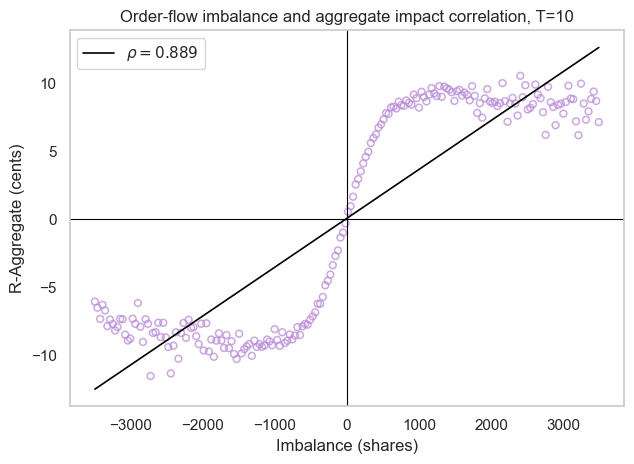

,T=10: imbalance-impact correlation
Pearson correlation rho,0.889102
curve points,200.000000
linear slope (cents/share),0.003596
linear intercept (cents),0.064002


rho = 0.889, indicating a strong positive relationship: larger order-flow imbalance is associated with larger aggregate market impact.


In [190]:
# Correlation between order-flow imbalance and aggregate impact
correlation_data = figure8_curve[["volume_imbalance", "impact_cents"]].dropna()
rho = correlation_data["volume_imbalance"].corr(correlation_data["impact_cents"])

slope, intercept = np.polyfit(
    correlation_data["volume_imbalance"],
    correlation_data["impact_cents"],
    deg=1,
)
x_grid = np.linspace(
    correlation_data["volume_imbalance"].min(),
    correlation_data["volume_imbalance"].max(),
    200,
)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.scatter(
    correlation_data["volume_imbalance"],
    correlation_data["impact_cents"],
    s=24,
    facecolors="none",
    edgecolors="#b98ad9",
    linewidths=1.1,
    alpha=0.75,
)
ax.plot(x_grid, slope * x_grid + intercept, color="black", lw=1.2, label=f"$\\rho={rho:.3f}$")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Imbalance (shares)")
ax.set_ylabel("R-Aggregate (cents)")
ax.legend(loc="upper left")
ax.grid(False)
plt.tight_layout()
save_beamer_figure(fig, "imbalance_impact_correlation_t10.png")
plt.show()

display(pd.Series({
    "Pearson correlation rho": rho,
    "curve points": len(correlation_data),
    "linear slope (cents/share)": slope,
    "linear intercept (cents)": intercept,
}, name=f"T={figure8_horizon}: imbalance-impact correlation").to_frame())

print(
    f"rho = {rho:.3f}, indicating a strong positive relationship: "
    "larger order-flow imbalance is associated with larger aggregate market impact."
)

(done) NOTE FOR LATEX: ADD PREVIOUS CORRELATION FIGURE (previous figure) IN A SLIDE:

What to say:
strong positive relationship between order-flow and price impact (i.e., the greater the imbalance the bigger the market impact).

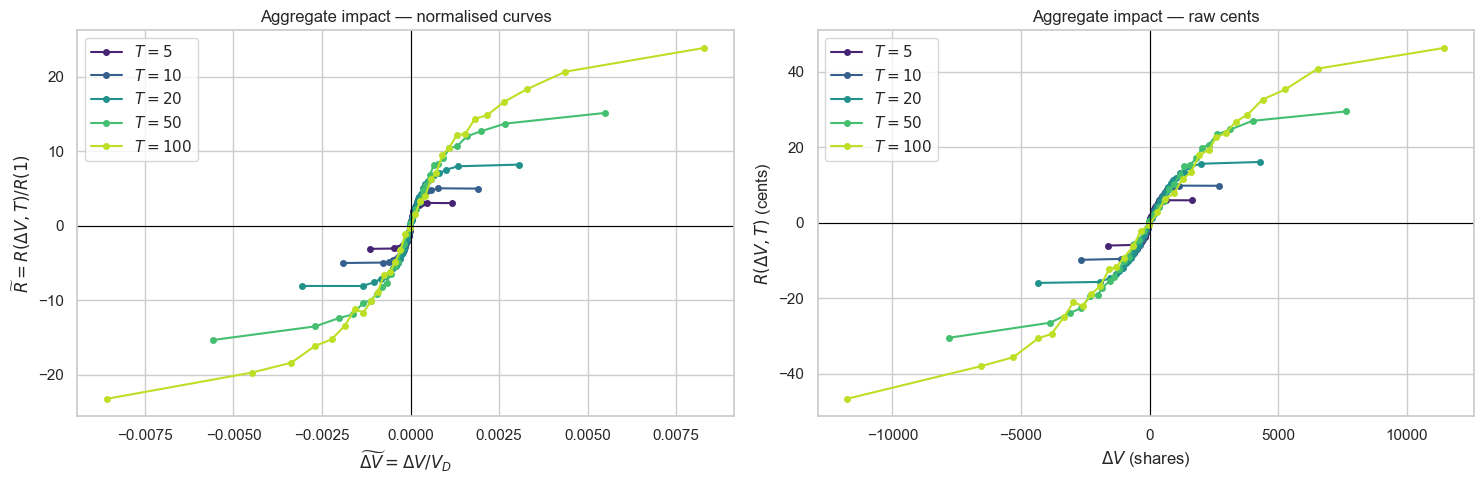

In [191]:
# ── Aggregate impact curves for each horizon T ────────────────────────────────
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: normalised impact curves ---
ax = axes[0]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["normalised_volume_imbalance"],
        part["normalised_impact"],
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$")
ax.set_ylabel("$\\widetilde{R} = R(\\Delta V, T) / R(1)$")
ax.legend(loc="upper left")

# --- Right: raw (un-normalised) impact curves ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["volume_imbalance"],
        part["impact"] * 100,
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.legend(loc="upper left")

plt.tight_layout()
save_beamer_figure(fig, "aggregate_impact_curves.png")
plt.show()

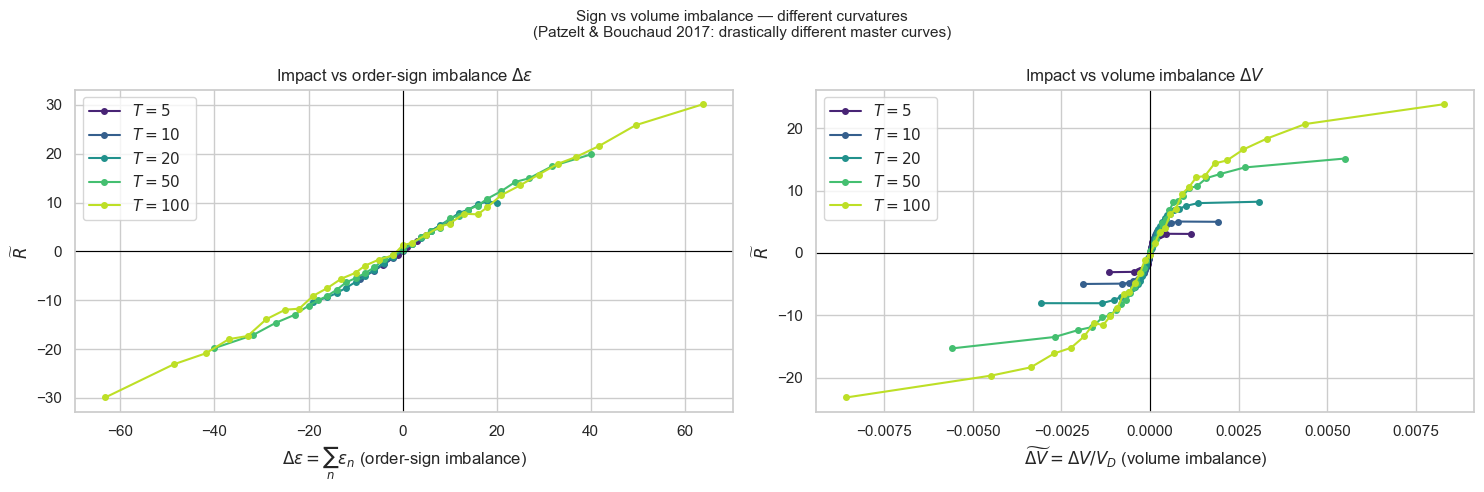

In [192]:
# ── Order-sign imbalance Δε vs volume imbalance ΔV ────────────────────────────
# Patzelt & Bouchaud (2017) show that sign impact and volume impact have
# drastically different master curves.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Impact vs ORDER-SIGN imbalance Δε ---
ax = axes[0]
sign_curve_parts = []
for horizon, part in windows.groupby("horizon", sort=True, observed=True):
    labels = pd.qcut(part["order_flow_imbalance"], q=31, duplicates="drop")
    sc = (
        part.assign(ofi_bin=labels)
        .groupby("ofi_bin", observed=True)
        .agg(
            order_flow_imbalance=("order_flow_imbalance", "mean"),
            normalised_impact=("normalised_impact", "mean"),
        )
        .reset_index(drop=True)
    )
    sc.insert(0, "horizon", horizon)
    sign_curve_parts.append(sc)
sign_impact_curve = pd.concat(sign_curve_parts, ignore_index=True)

for (horizon, part), color in zip(sign_impact_curve.groupby("horizon"), palette):
    ax.plot(part["order_flow_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta\\varepsilon = \\sum_n \\varepsilon_n$ (order-sign imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs order-sign imbalance $\\Delta\\varepsilon$")
ax.legend()

# --- Impact vs VOLUME imbalance ΔV (same as before for comparison) ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["normalised_volume_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$ (volume imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs volume imbalance $\\Delta V$")
ax.legend()

plt.suptitle(
    "Sign vs volume imbalance — different curvatures\n"
    "(Patzelt & Bouchaud 2017: drastically different master curves)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. Finite-Size Scaling — Thursday

### 5.1 The Scaling Hypothesis

The key finding of Patzelt & Bouchaud (2017) is that for any intra-day
horizon $T$, the aggregate impact can be written in **scaling form**:

$$
R(\Delta V, T) \approx R(1)\, T^{\,\psi}\,
\mathcal{F}\!\left(\frac{\Delta V}{V_D \, T^{\xi}}\right),
$$

with the **sigmoidal master function**:

$$
\mathcal{F}(x) = \frac{x}{\bigl(1 + |x|^{\,\alpha}\bigr)^{\beta/\alpha}}.
$$

The exponents have physical interpretations:
- $\xi$ controls how the characteristic volume imbalance scales with $T$
- $\psi$ controls the amplitude growth with $T$
- $\alpha, \beta$ set the shape of the sigmoid (concavity)
- **Kyle's lambda exponent**: $\lambda = \xi - \psi$

Two auxiliary scale parameters (`amplitude`, `x_scale`) absorb unit
differences between the TSLA dataset and the normalisation convention.

### 5.2 Fitting Procedure

We fit all five curves simultaneously using nonlinear least squares
(`scipy.optimize.least_squares` with `soft_l1` loss for outlier robustness),
weighting each quantile bin by $\sqrt{N_{\text{obs}}}$.

In [193]:
def master_curve(x: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    """Sigmoidal scaling function F(x) = x / (1 + |x|^α)^(β/α)."""
    return x / np.power(1 + np.power(np.abs(x), alpha), beta / alpha)


def fit_finite_size_scaling(curve: pd.DataFrame) -> dict[str, float]:
    """Fit exponents and nuisance scales for a finite-size scaling collapse."""
    x       = curve["normalised_volume_imbalance"].to_numpy(dtype=float)
    y       = curve["normalised_impact"].to_numpy(dtype=float)
    horizon = curve["horizon"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()

    def prediction(p: np.ndarray) -> np.ndarray:
        amplitude, x_scale, xi, psi, alpha, beta = p
        return amplitude * np.power(horizon, psi) * master_curve(
            x * np.power(horizon, -xi) / x_scale, alpha, beta
        )

    result = least_squares(
        lambda p: weights * (prediction(p) - y),
        x0=np.array([1.0, 0.001, 0.5, 0.3, 1.5, 0.5]),
        bounds=(
            np.array([1e-6, 1e-7, -1.0, -1.0, 0.1, 0.01]),
            np.array([1e4,  1.0,   2.0,  2.0,  8.0,  4.0]),
        ),
        loss="soft_l1",
        max_nfev=20_000,
    )
    amplitude, x_scale, xi, psi, alpha, beta = result.x
    return {
        "amplitude": float(amplitude), "x_scale": float(x_scale),
        "xi": float(xi),              "psi": float(psi),
        "alpha": float(alpha),        "beta": float(beta),
        "lambda_exponent": float(xi - psi),
        "cost": float(result.cost),   "success": bool(result.success),
    }


def renormalise_curve(curve: pd.DataFrame, parameters: dict[str, float]) -> pd.DataFrame:
    """Apply the fitted finite-size scaling transformation."""
    result = curve.copy()
    result["master_x"] = (
        result["normalised_volume_imbalance"]
        * np.power(result["horizon"], -parameters["xi"])
        / parameters["x_scale"]
    )
    result["master_y"] = (
        result["normalised_impact"]
        / parameters["amplitude"]
        / np.power(result["horizon"], parameters["psi"])
    )
    return result

In [194]:
fss_parameters = fit_finite_size_scaling(impact_curve)
fss_series = pd.Series(fss_parameters, name="TSLA 2019")
fss_series.index = [
    "amplitude $A$",
    "x-scale $x_0$",
    "volume exponent $\\xi$",
    "impact exponent $\\psi$",
    "sigmoid shape $\\alpha$",
    "sigmoid shape $\\beta$",
    "Kyle exponent $\\lambda = \\xi - \\psi$",
    "fit cost",
    "success",
]
display(fss_series.to_frame().round(4))

xi = fss_parameters["xi"]
psi = fss_parameters["psi"]
alpha = fss_parameters["alpha"]
beta = fss_parameters["beta"]
print(f"\nKey exponents:  ξ = {xi:.4f},  ψ = {psi:.4f},  α = {alpha:.4f},  β = {beta:.4f}")
print(f"Kyle exponent:  λ = ξ − ψ = {xi - psi:.4f}")

,TSLA 2019
amplitude $A$,1.403239
x-scale $x_0$,0.00002
volume exponent $\xi$,1.081947
impact exponent $\psi$,0.685703
sigmoid shape $\alpha$,1.232702
sigmoid shape $\beta$,1.114598
Kyle exponent $\lambda = \xi - \psi$,0.396244
fit cost,0.670585
success,True



Key exponents:  ξ = 1.0819,  ψ = 0.6857,  α = 1.2327,  β = 1.1146
Kyle exponent:  λ = ξ − ψ = 0.3962


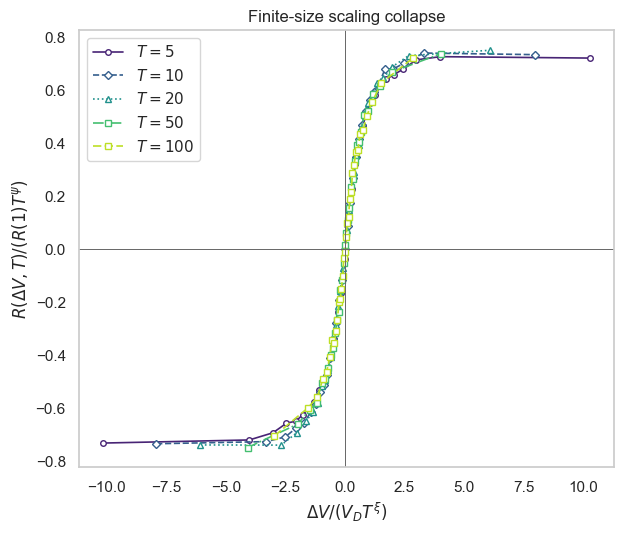

In [195]:

# ── Finite-size scaling collapse ──────────────────────────────────────────────
collapsed = renormalise_curve(impact_curve, fss_parameters)
palette_fss = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))
line_styles = ["-", "--", ":", "-.", (0, (5, 2))]
markers     = ["o", "D", "^", "s", "s"]

fig, ax = plt.subplots(figsize=(6.4, 5.5))
for (horizon, part), line_style, marker, color in zip(
    collapsed.groupby("horizon"), line_styles, markers, palette_fss
):
    ax.plot(
        part["master_x"], part["master_y"],
        linestyle=line_style, marker=marker, ms=4, mfc="white",
        color=color, lw=1.2, label=f"$T={horizon}$",
    )
ax.axhline(0, color="0.4", lw=0.7)
ax.axvline(0, color="0.4", lw=0.7)
ax.set_xlabel("$\\Delta V / (V_D T^\\xi)$")
ax.set_ylabel("$R(\\Delta V,T) / (R(1) T^\\psi)$")
ax.legend(loc="upper left", frameon=True)
ax.grid(False)
plt.tight_layout()
save_beamer_figure(fig, "finite_size_scaling_collapse.png")
plt.show()


## 6. Kyle's Lambda — Thursday

### 6.1 Linear Regime and Market Illiquidity

In the limit of small $|\Delta V|$, the sigmoidal master curve is
approximately linear. The slope is **Kyle's lambda** $\lambda(T)$:

$$
\lambda(T) = \left.\frac{\partial R(\Delta V, T)}{\partial \Delta V}\right|_{\Delta V \approx 0}.
$$

In the scaling picture:

$$
\lambda(T) \propto T^{-\lambda}, \qquad \lambda = \xi - \psi.
$$

A large $\lambda$ means a given volume imbalance moves the price further —
the market is **less liquid**. As $T$ grows, the price impact per share falls
because the market has more time to absorb order flow.

We estimate $\lambda(T)$ by OLS on the central 35 % of the $|\Delta V|$
distribution (the approximately linear region), then fit the power law.

### 6.2 Connection to Kyle (1985) and Information Asymmetry

In Kyle's continuous-time model, the informed trader's profit is:

$$
\pi = \frac{1}{2\lambda}(\sigma_v)^2,
$$

where $\sigma_v$ is the information signal's standard deviation. A smaller
$\lambda$ (more liquid market) reduces informed profits. The empirical
decay $\lambda(T) \propto T^{-\lambda}$ shows that averaging over longer
windows reduces the effective information asymmetry per unit volume.

In [196]:
def estimate_kyle_lambdas(
    windows: pd.DataFrame, central_quantile: float = 0.35
) -> pd.DataFrame:
    """Estimate Kyle's lambda via OLS in the central (approximately linear) region."""
    rows: list[dict[str, float | int]] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        threshold = part["volume_imbalance"].abs().quantile(central_quantile)
        central = part[part["volume_imbalance"].abs() <= threshold]
        x = central["volume_imbalance"].to_numpy(dtype=float)
        y = central["impact"].to_numpy(dtype=float) * 100
        intercept, slope = np.linalg.lstsq(
            np.column_stack([np.ones(len(x)), x]), y, rcond=None
        )[0]
        rows.append({
            "horizon": int(horizon),
            "threshold_shares": float(threshold),
            "intercept_cents": float(intercept),
            "kyle_lambda_cents_per_share": float(slope),
            "observations": len(central),
        })
    return pd.DataFrame(rows)


def fit_kyle_decay(kyle_lambdas: pd.DataFrame) -> dict[str, float]:
    """Fit lambda(T) ∝ T^(-exponent) by log-log OLS."""
    clean = kyle_lambdas[kyle_lambdas["kyle_lambda_cents_per_share"] > 0]
    x = np.log(clean["horizon"].to_numpy(dtype=float))
    y = np.log(clean["kyle_lambda_cents_per_share"].to_numpy(dtype=float))
    intercept, slope = np.linalg.lstsq(
        np.column_stack([np.ones(len(x)), x]), y, rcond=None
    )[0]
    return {"prefactor": float(np.exp(intercept)), "lambda_exponent": float(-slope)}

In [197]:
kyle_lambdas = estimate_kyle_lambdas(windows, central_quantile=0.35)
kyle_decay = fit_kyle_decay(kyle_lambdas)

display(kyle_lambdas.set_index("horizon").round(5))
display(pd.Series(kyle_decay, name="Direct power-law fit").round(5).to_frame())
print(
    f"\nExponent predicted by FSS (ξ − ψ): {fss_parameters['lambda_exponent']:.5f}\n"
    f"Exponent from direct OLS fit:        {kyle_decay['lambda_exponent']:.5f}"
)

,threshold_shares,intercept_cents,kyle_lambda_cents_per_share,observations
horizon,,,,
5,172.0,0.05309,0.02420,296434
10,292.0,0.14987,0.01866,148553
20,473.0,0.31819,0.01487,74160
50,890.0,0.43627,0.01174,29607
100,1476.0,0.77345,0.00914,14775


,Direct power-law fit
prefactor,0.03938
lambda_exponent,0.31626



Exponent predicted by FSS (ξ − ψ): 0.39624
Exponent from direct OLS fit:        0.31626


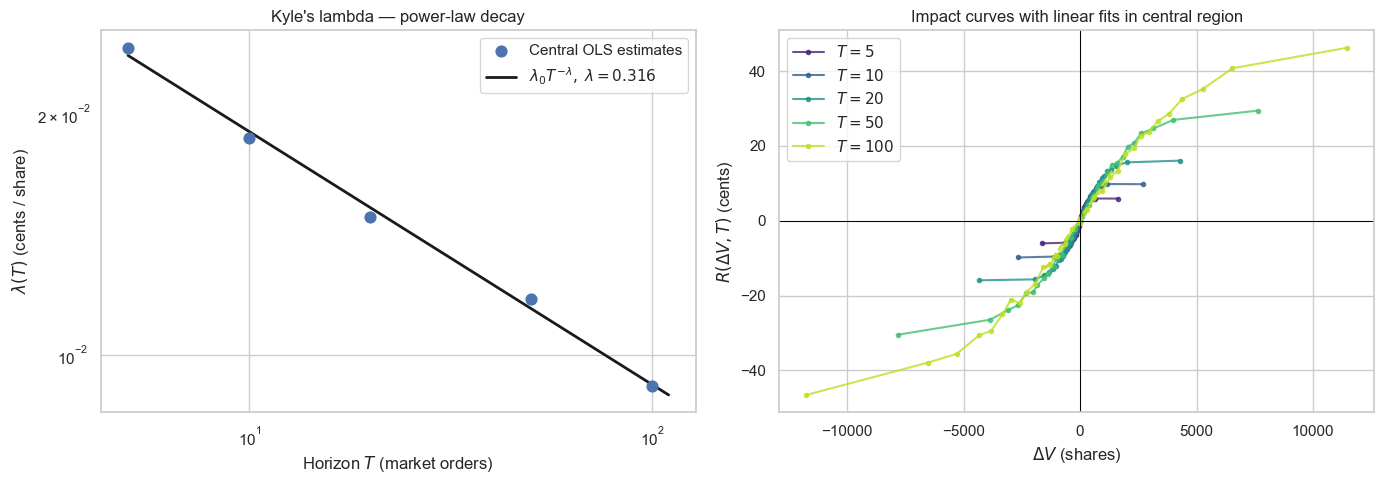

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizon_grid = np.geomspace(min(HORIZONS), max(HORIZONS) * 1.1, 200)
lambda_exp = kyle_decay["lambda_exponent"]
prefactor = kyle_decay["prefactor"]

# --- Left: log-log plot with power-law fit ---
ax = axes[0]
ax.scatter(kyle_lambdas["horizon"], kyle_lambdas["kyle_lambda_cents_per_share"],
           s=60, zorder=5, label="Central OLS estimates")
ax.plot(horizon_grid, prefactor * horizon_grid ** (-lambda_exp),
        "k-", lw=2, label=f"$\\lambda_0 T^{{-\\lambda}},\\;\\lambda={lambda_exp:.3f}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Horizon $T$ (market orders)")
ax.set_ylabel("$\\lambda(T)$ (cents / share)")
ax.set_title("Kyle's lambda — power-law decay")
ax.legend()

# --- Right: impact curve with linear fits overlaid ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["volume_imbalance"], part["impact"] * 100,
            marker="o", ms=3, color=color, alpha=0.8, label=f"$T={horizon}$")
    kl_row = kyle_lambdas[kyle_lambdas["horizon"].eq(horizon)]
    if len(kl_row):
        slope = kl_row["kyle_lambda_cents_per_share"].iloc[0]
        intercept = kl_row["intercept_cents"].iloc[0]
        threshold = kl_row["threshold_shares"].iloc[0]
        x_lin = np.linspace(-threshold, threshold, 100)
        ax.plot(x_lin, intercept + slope * x_lin, "--", color=color, lw=1.5)
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.set_title("Impact curves with linear fits in central region")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7. Machine Learning — Functional Form and Estimation Objectives

### 7.1 Thesis Protocol (Bugaenko 2019) and Our Extensions

The thesis of Bugaenko (2019) applies supervised regression to predict
the aggregate mid-price impact $R(\Delta V, T)$ from the signed volume
imbalance $\Delta V$ over a window of $T = 10$ consecutive market orders
for TSLA during **2015** (LOBSTER level-2 data, ~47 k post-filter
observations). The supervised problem is:

$$
X = \Delta V(T), \qquad y = R(\Delta V,T) \times 100 \quad (\text{cents})
$$

**Thesis baseline results (TSLA 2015, T=10):**

| Model | MSE (cents) | Decision |
|---|---|---|
| Linear Regression (OLS) | 3.86 | baseline |
| Decision Tree Regression | 2.50 | +35% improvement |
| $\rho(\Delta V,\, R)$ | **0.854** | high raw correlation |

> **Methodological note:** The MSE values in the thesis are computed on
> pre-processed **binned/subsampled** data — the dataset is regularised
> by volume bucket (every 0.01–0.1 increment of normalised volume) before
> fitting. Binning drastically reduces idiosyncratic window-level noise and
> artificially inflates apparent correlation and $R^2$. The thesis
> cross-validation also uses **random** $k$-fold splits (no temporal
> grouping), which allows same-day windows to appear in both training and
> test folds, introducing mild look-ahead bias.

### 7.2 Our Implementation Differences

We train and evaluate on **raw individual windows** (no pre-binning),
which is the standard ML protocol and gives genuine out-of-sample
performance. Key differences from the thesis:

| Aspect | Bugaenko 2019 | This notebook |
|---|---|---|
| Dataset | TSLA 2015, ~47 k obs | TSLA 2019, ~413 k obs |
| Target | binned averages | raw individual windows |
| Train/test split | random shuffle | temporal (last 20 % dates) |
| CV | random $k$-fold | day-grouped $k$-fold (no leakage) |
| Models | OLS + Decision Tree | 13 models across 5 families |
| Metrics | MSE, $R^2$ | MSE, RMSE, MAE, MedAE, $R^2$, sign accuracy, AIC, BIC |

The extension adds:
- linear estimators under Gaussian MLE, Ridge, Lasso and SGD;
- robust losses: Huber M-estimator and absolute-error tree/boosting;
- tree ensembles: Random Forest, Extra Trees and gradient boosting;
- sensitivity of Kyle's $\lambda$ to the estimation objective and the
  width of the central linear region.

### 7.3 What Makes This Hard

The raw-window learning problem is fundamentally noisier than the
binned version. Each 10-order window has a large idiosyncratic component:
the realised impact $R(\Delta V, 10)$ depends not only on $\Delta V$ but
also on the hidden state of liquidity at that moment, the depth profile
of the order book, and the auto-correlation structure of order flow. The
binned curve (Section 4) averages this noise away by construction. Hence:

- **Raw-window $\rho(\Delta V, R) \approx 0.50$** vs thesis's 0.85 on bins.
- **RMSE $\approx 10$ cents** (raw) vs thesis $\approx$ 2–4 cents (binned).
- Maximum achievable $R^2$ on individual windows is theoretically
  bounded well below 1, even with a perfect model of the conditional mean.

The low $R^2$ is therefore not a failure of the models — it reflects that
most of the variance in $R(\Delta V, 10)$ is genuinely unexplained by
$\Delta V$ alone at single-window resolution.

In [199]:
if RUN_ML:
    # -- ML helpers: supervised impact prediction and model comparison -----------
    from sklearn.base import clone
    from sklearn.ensemble import (
        ExtraTreesRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.linear_model import HuberRegressor, Lasso, LinearRegression, Ridge, SGDRegressor
    from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.tree import DecisionTreeRegressor

    ML_TARGET_HORIZON = 10
    ML_RANDOM_STATE = 42
    ML_TEST_DATE_FRACTION = 0.20
    ML_CV_FOLDS = 10
    ML_CV_MAX_OBSERVATIONS = 50_000
    ML_SIGMA_CLIP = 3.0

    ML_BASE_FEATURE_COLUMNS = ["volume_imbalance"]
    ML_ENGINEERED_FEATURE_COLUMNS = [
        "volume_imbalance",
        "abs_volume_imbalance",
        "signed_sqrt_volume_imbalance",
        "signed_log_volume_imbalance",
    ]


    def add_ml_features(data: pd.DataFrame) -> pd.DataFrame:
        """Add deterministic one-dimensional transforms of signed volume imbalance."""
        result = data.copy()
        x = result["volume_imbalance"].to_numpy(dtype=float)
        abs_x = np.abs(x)
        result["abs_volume_imbalance"] = abs_x
        result["signed_sqrt_volume_imbalance"] = np.sign(x) * np.sqrt(abs_x)
        result["signed_log_volume_imbalance"] = np.sign(x) * np.log1p(abs_x)
        return result


    def sigma_clip_frame(
        data: pd.DataFrame,
        columns: Sequence[str],
        sigma: float | None,
    ) -> pd.DataFrame:
        """Apply the thesis-style 3-sigma outlier filter to selected columns."""
        if sigma is None:
            return data.copy()
        mask = np.ones(len(data), dtype=bool)
        for column in columns:
            values = data[column].to_numpy(dtype=float)
            mean = np.nanmean(values)
            std = np.nanstd(values)
            if np.isfinite(std) and std > 0:
                mask &= np.abs(values - mean) <= sigma * std
        return data.loc[mask].copy()


    def make_ml_impact_dataset(
        windows: pd.DataFrame,
        horizon: int = ML_TARGET_HORIZON,
        sigma_clip: float | None = ML_SIGMA_CLIP,
    ) -> pd.DataFrame:
        """Prepare the supervised-learning sample used by the thesis."""
        columns = [
            "date",
            "horizon",
            "volume_imbalance",
            "order_flow_imbalance",
            "impact",
            "normalised_volume_imbalance",
            "normalised_impact",
        ]
        data = windows.loc[windows["horizon"].eq(horizon), columns].copy()
        data["impact_cents"] = data["impact"] * 100.0
        data = data.replace([np.inf, -np.inf], np.nan).dropna(
            subset=["date", "volume_imbalance", "impact_cents"]
        )
        data = sigma_clip_frame(
            data,
            columns=["volume_imbalance", "impact_cents"],
            sigma=sigma_clip,
        )
        data = add_ml_features(data)
        return data.sort_values(["date", "volume_imbalance"]).reset_index(drop=True)


    def temporal_train_test_split(
        data: pd.DataFrame,
        test_date_fraction: float = ML_TEST_DATE_FRACTION,
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        """Use the final dates as the test set to avoid looking forward in time."""
        dates = np.array(sorted(data["date"].unique()))
        split = int(np.floor((1.0 - test_date_fraction) * len(dates)))
        split = min(max(split, 1), len(dates) - 1)
        train_dates = set(dates[:split])
        train = data[data["date"].isin(train_dates)].copy()
        test = data[~data["date"].isin(train_dates)].copy()
        return train, test


    def gaussian_scores(
        y_true: np.ndarray,
        y_pred: np.ndarray,
        parameter_count: int | float | None = None,
    ) -> dict[str, float]:
        """Regression metrics plus Gaussian residual likelihood diagnostics."""
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        residuals = y_true - y_pred
        n = len(y_true)
        rss = float(residuals @ residuals)
        mse = rss / n
        sigma2_mle = max(mse, np.finfo(float).tiny)
        nll = 0.5 * n * (np.log(2 * np.pi * sigma2_mle) + 1.0)
        nonzero_sign = (y_true != 0) & (y_pred != 0)
        scores = {
            "n": float(n),
            "mse": mse,
            "rmse": float(np.sqrt(mse)),
            "mae": float(mean_absolute_error(y_true, y_pred)),
            "medae": float(median_absolute_error(y_true, y_pred)),
            "r2": float(r2_score(y_true, y_pred)),
            "sign_accuracy": float(
                np.mean(np.sign(y_true[nonzero_sign]) == np.sign(y_pred[nonzero_sign]))
            ) if nonzero_sign.any() else np.nan,
            "gaussian_nll": float(nll),
            "sigma_mle_cents": float(np.sqrt(sigma2_mle)),
        }
        if parameter_count is not None and np.isfinite(parameter_count):
            k = float(parameter_count)
            scores["aic_gaussian"] = float(2 * k + 2 * nll)
            scores["bic_gaussian"] = float(np.log(n) * k + 2 * nll)
        return scores


    def final_estimator(model):
        """Return the fitted estimator behind a possible Pipeline wrapper."""
        return model.steps[-1][1] if hasattr(model, "steps") else model


    def effective_parameter_count(model) -> float:
        """Approximate model complexity for diagnostics, not formal inference."""
        estimator = final_estimator(model)
        if hasattr(estimator, "coef_"):
            coef = np.ravel(estimator.coef_)
            intercept = np.ravel(getattr(estimator, "intercept_", np.array([0.0])))
            return float(np.count_nonzero(coef) + np.count_nonzero(intercept))
        if hasattr(estimator, "tree_"):
            return float(estimator.tree_.n_leaves)
        if hasattr(estimator, "estimators_"):
            leaves = [
                tree.tree_.n_leaves
                for tree in np.ravel(estimator.estimators_)
                if hasattr(tree, "tree_")
            ]
            return float(np.sum(leaves)) if leaves else np.nan
        return np.nan


    def fit_and_score_models(
        model_specs: list[dict],
        train: pd.DataFrame,
        test: pd.DataFrame,
        default_features: Sequence[str] = ML_BASE_FEATURE_COLUMNS,
        target_column: str = "impact_cents",
    ) -> tuple[pd.DataFrame, dict[str, object]]:
        """Fit each model spec and score it on temporal train/test partitions."""
        rows = []
        fitted_models: dict[str, object] = {}
        for spec in model_specs:
            name = spec["model"]
            features = spec.get("features", list(default_features))
            model = clone(spec["estimator"])
            x_train = train[features].to_numpy(dtype=float)
            y_train = train[target_column].to_numpy(dtype=float)
            x_test = test[features].to_numpy(dtype=float)
            y_test = test[target_column].to_numpy(dtype=float)
            model.fit(x_train, y_train)
            fitted_models[name] = model
            parameter_count = effective_parameter_count(model)
            train_scores = gaussian_scores(y_train, model.predict(x_train), parameter_count)
            test_scores = gaussian_scores(y_test, model.predict(x_test), parameter_count)
            row = {
                "model": name,
                "family": spec["family"],
                "objective": spec["objective"],
                "features": "+".join(features),
                "effective_parameters": parameter_count,
            }
            row.update({f"train_{key}": value for key, value in train_scores.items()})
            row.update({f"test_{key}": value for key, value in test_scores.items()})
            rows.append(row)
        return pd.DataFrame(rows).sort_values("test_mse").reset_index(drop=True), fitted_models


    def cross_validate_models(
        model_specs: list[dict],
        data: pd.DataFrame,
        n_splits: int = ML_CV_FOLDS,
        default_features: Sequence[str] = ML_BASE_FEATURE_COLUMNS,
        target_column: str = "impact_cents",
    ) -> pd.DataFrame:
        """Day-grouped k-fold CV, mirroring the thesis while avoiding same-day leakage."""
        groups = data["date"].to_numpy()
        unique_group_count = len(np.unique(groups))
        cv = GroupKFold(n_splits=min(n_splits, unique_group_count))
        rows = []
        for spec in model_specs:
            fold_rows = []
            features = spec.get("features", list(default_features))
            x = data[features].to_numpy(dtype=float)
            y = data[target_column].to_numpy(dtype=float)
            for fold, (train_index, test_index) in enumerate(cv.split(x, y, groups), start=1):
                model = clone(spec["estimator"])
                model.fit(x[train_index], y[train_index])
                scores = gaussian_scores(y[test_index], model.predict(x[test_index]))
                scores["fold"] = fold
                fold_rows.append(scores)
            folds = pd.DataFrame(fold_rows)
            row = {
                "model": spec["model"],
                "family": spec["family"],
                "objective": spec["objective"],
                "features": "+".join(features),
                "folds": len(folds),
                "mean_mse": folds["mse"].mean(),
                "std_mse": folds["mse"].std(ddof=1),
                "mean_mae": folds["mae"].mean(),
                "std_mae": folds["mae"].std(ddof=1),
                "mean_r2": folds["r2"].mean(),
                "std_r2": folds["r2"].std(ddof=1),
                "mean_sign_accuracy": folds["sign_accuracy"].mean(),
            }
            rows.append(row)
        return pd.DataFrame(rows).sort_values("mean_mse").reset_index(drop=True)
else:
    print("Section 7 ML skipped because RUN_ML=False. Set RUN_ML=True in the first code cell to run it.")


,ML sample
target horizon T,10
raw windows before ML filter,423165
windows after 3-sigma filter,412849
train observations,317495
test observations,95354
train first date,2019-01-02
train last date,2019-10-21
test first date,2019-10-22
test last date,2019-12-31
"corr(DeltaV, impact cents)",0.496599


,volume_imbalance,order_flow_imbalance,impact_cents
count,412849.0000,412849.0000,412849.0000
mean,0.6470,-0.1010,-0.0096
std,737.3875,6.3084,11.5267
min,-3514.0000,-10.0000,-38.0000
1%,-2077.5200,-10.0000,-29.5000
5%,-1110.0000,-10.0000,-19.5000
50%,-6.0000,0.0000,0.0000
95%,1132.0000,10.0000,19.5000
99%,2106.0000,10.0000,29.5000
max,3511.0000,10.0000,38.0000


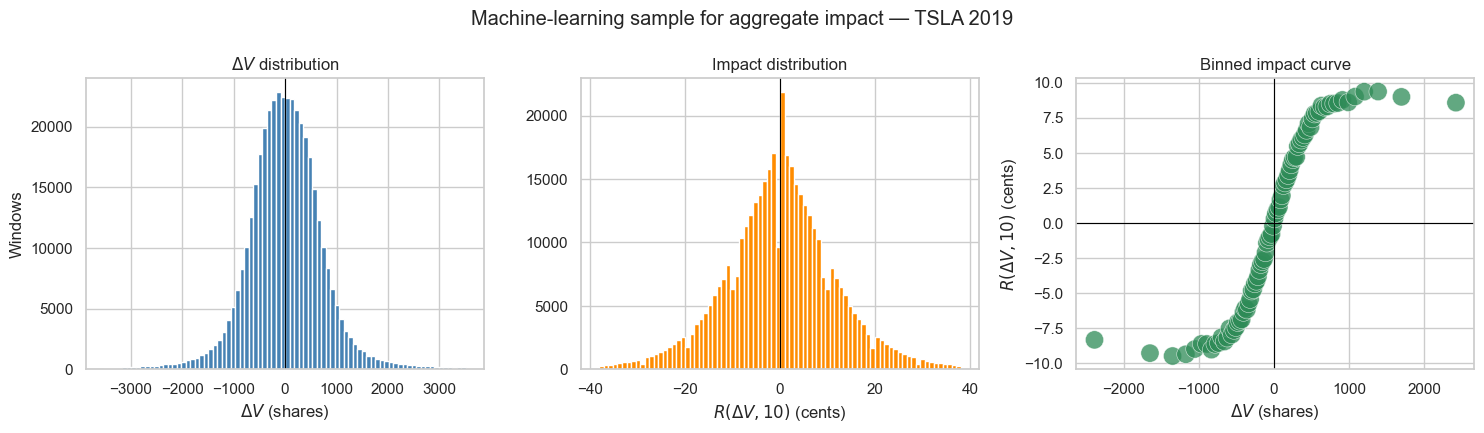

In [200]:
if RUN_ML:
    # -- Thesis-style supervised sample: TSLA 2019, T = 10 market orders ---------
    ml_data = make_ml_impact_dataset(
        windows,
        horizon=ML_TARGET_HORIZON,
        sigma_clip=ML_SIGMA_CLIP,
    )
    ml_train, ml_test = temporal_train_test_split(ml_data)

    ml_overview = pd.Series({
        "target horizon T": ML_TARGET_HORIZON,
        "raw windows before ML filter": int(windows["horizon"].eq(ML_TARGET_HORIZON).sum()),
        "windows after 3-sigma filter": len(ml_data),
        "train observations": len(ml_train),
        "test observations": len(ml_test),
        "train first date": ml_train["date"].min(),
        "train last date": ml_train["date"].max(),
        "test first date": ml_test["date"].min(),
        "test last date": ml_test["date"].max(),
        "corr(DeltaV, impact cents)": ml_data["volume_imbalance"].corr(ml_data["impact_cents"]),
    }, name="ML sample")
    display(ml_overview.to_frame())

    display(
        ml_data[["volume_imbalance", "order_flow_imbalance", "impact_cents"]]
        .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
        .round(4)
    )

    # Binned scatter used as the visual target for the ML models.
    ml_plot_bins = pd.qcut(ml_data["volume_imbalance"], q=80, duplicates="drop")
    ml_binned_impact = (
        ml_data.assign(_bin=ml_plot_bins)
        .groupby("_bin", observed=True)
        .agg(
            volume_imbalance=("volume_imbalance", "median"),
            impact_cents=("impact_cents", "mean"),
            observations=("impact_cents", "size"),
        )
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].hist(ml_data["volume_imbalance"], bins=80, color="steelblue", edgecolor="white")
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_xlabel(r"$\Delta V$ (shares)")
    axes[0].set_ylabel("Windows")

    axes[1].hist(ml_data["impact_cents"], bins=80, color="darkorange", edgecolor="white")
    axes[1].axvline(0, color="black", lw=0.8)
    axes[1].set_xlabel(r"$R(\Delta V,10)$ (cents)")

    axes[2].scatter(
        ml_binned_impact["volume_imbalance"],
        ml_binned_impact["impact_cents"],
        s=np.sqrt(ml_binned_impact["observations"]) * 2.4,
        alpha=0.75,
        color="seagreen",
        edgecolor="white",
        linewidth=0.4,
    )
    axes[2].axhline(0, color="black", lw=0.8)
    axes[2].axvline(0, color="black", lw=0.8)
    axes[2].set_xlabel(r"$\Delta V$ (shares)")
    axes[2].set_ylabel(r"$R(\Delta V,10)$ (cents)")

    plt.tight_layout()
    plt.show()

### 7.4 Raw vs Binned Correlation — Reconciling with the Thesis

The thesis reports $\rho(\Delta V, R(\Delta V, 10)) = 0.854$ for TSLA
2015, while our raw-window data for 2019 shows $\rho \approx 0.497$.
This large gap has two independent sources:

**Source 1 — Pre-binning in the thesis.** Bugaenko (2019) fits models
to *averaged* impact per normalised-volume bucket, not to individual
windows. Averaging $n$ IID observations reduces the standard deviation
of the noise by $\sqrt{n}$, which increases the signal-to-noise ratio
and inflates the apparent correlation. On our 2019 data, computing the
same binned correlation gives $\rho \approx 0.97$, confirming the
mechanism. The thesis's 0.85 sits between raw and fully binned because
their subsampling procedure is only partial regularisation.

**Source 2 — Market conditions (2015 vs 2019).** TSLA's price was
more stable in H1 2015 (~USD 220–250, spread ~13 cents) vs 2019
(USD 175–430, violent swings, spread ~7–9 cents). Higher price
volatility relative to impact scale reduces the cross-sectional SNR for
aggregate impact prediction. The idiosyncratic noise variance $\sigma^2_\varepsilon$
in $R = \lambda \Delta V + \varepsilon$ is larger relative to
$\lambda^2\,\mathrm{Var}(\Delta V)$ in 2019.

The cell below verifies Source 1 by computing binned correlation on our
2019 data.

Raw-window correlation ρ(ΔV, R) = 0.4966
Binned correlation (80 bins) ρ(ΔV, R) = 0.8919

Thesis-style value (TSLA 2015, partial binning) ≈ 0.854
Our 2019 raw value                               = 0.497
Our 2019 fully binned (80 bins)          = 0.892


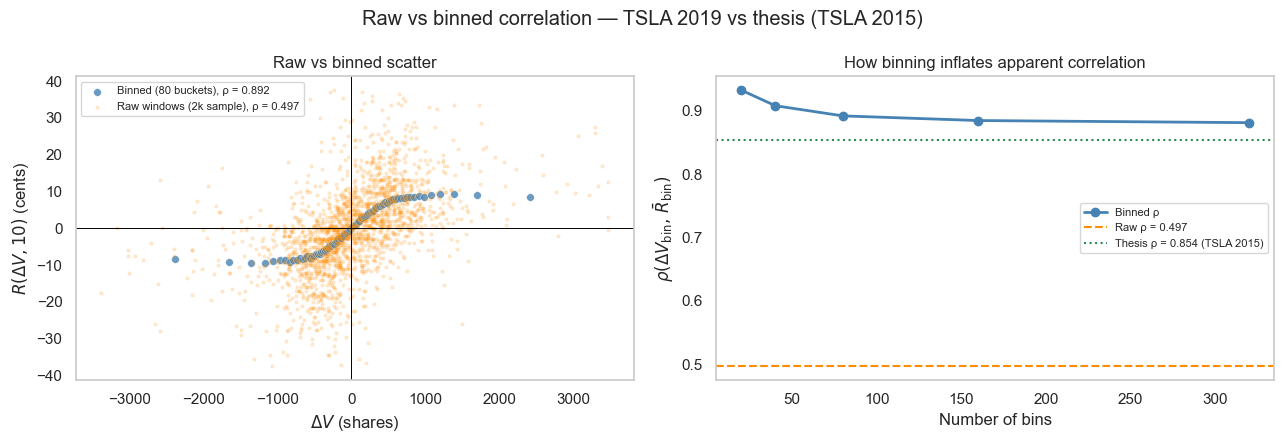

In [201]:
if RUN_ML:
    # ── Raw vs binned correlation demonstration ────────────────────────────────
    raw_corr = ml_data["volume_imbalance"].corr(ml_data["impact_cents"])

    # Thesis-style: bin ΔV into equal-count buckets and use mean impact per bin
    n_bins_thesis = 80
    ml_data_tmp = ml_data.copy()
    ml_data_tmp["_bin"] = pd.qcut(
        ml_data_tmp["volume_imbalance"], q=n_bins_thesis, duplicates="drop"
    )
    binned_corr_df = (
        ml_data_tmp.groupby("_bin", observed=True)
        .agg(dv=("volume_imbalance", "median"), r=("impact_cents", "mean"))
        .dropna()
    )
    binned_corr = binned_corr_df["dv"].corr(binned_corr_df["r"])

    # Also show for several bin counts
    bin_counts = [20, 40, 80, 160, 320]
    corr_by_bins = []
    for nb in bin_counts:
        ml_data_tmp["_b"] = pd.qcut(
            ml_data_tmp["volume_imbalance"], q=nb, duplicates="drop"
        )
        grp = (
            ml_data_tmp.groupby("_b", observed=True)
            .agg(dv=("volume_imbalance", "median"), r=("impact_cents", "mean"))
            .dropna()
        )
        corr_by_bins.append({"n_bins": nb, "binned_corr": grp["dv"].corr(grp["r"])})
    corr_curve = pd.DataFrame(corr_by_bins)

    print(f"Raw-window correlation ρ(ΔV, R) = {raw_corr:.4f}")
    print(f"Binned correlation ({n_bins_thesis} bins) ρ(ΔV, R) = {binned_corr:.4f}")
    print(f"\nThesis-style value (TSLA 2015, partial binning) ≈ 0.854")
    print(f"Our 2019 raw value                               = {raw_corr:.3f}")
    print(f"Our 2019 fully binned ({n_bins_thesis} bins)          = {binned_corr:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(
        binned_corr_df["dv"], binned_corr_df["r"],
        s=30, alpha=0.8, color="steelblue", edgecolor="white", linewidth=0.3,
        label=f"Binned ({n_bins_thesis} buckets), ρ = {binned_corr:.3f}",
    )
    axes[0].scatter(
        ml_data.sample(2000, random_state=1)["volume_imbalance"],
        ml_data.sample(2000, random_state=1)["impact_cents"],
        s=4, alpha=0.15, color="darkorange",
        label=f"Raw windows (2k sample), ρ = {raw_corr:.3f}",
    )
    axes[0].axhline(0, color="black", lw=0.7)
    axes[0].axvline(0, color="black", lw=0.7)
    axes[0].set_xlabel(r"$\Delta V$ (shares)")
    axes[0].set_ylabel(r"$R(\Delta V,10)$ (cents)")
    axes[0].legend(fontsize=8)
    axes[0].grid(False)

    axes[1].plot(corr_curve["n_bins"], corr_curve["binned_corr"],
                 "o-", color="steelblue", lw=2, label="Binned ρ")
    axes[1].axhline(raw_corr, color="darkorange", lw=1.5, ls="--", label=f"Raw ρ = {raw_corr:.3f}")
    axes[1].axhline(0.854, color="seagreen", lw=1.5, ls=":", label="Thesis ρ = 0.854 (TSLA 2015)")
    axes[1].set_xlabel("Number of bins")
    axes[1].set_ylabel(r"$\rho(\Delta V_{\text{bin}},\, \bar{R}_{\text{bin}})$")
    axes[1].legend(fontsize=8)
    axes[1].grid(False)

    plt.tight_layout()
    save_beamer_figure(fig, "ml_raw_vs_binned_correlation.png")
    plt.show()

    raw_sample = ml_data.sample(2000, random_state=1)

    fig_raw, ax_raw = plt.subplots(figsize=(6.6, 4.0))
    ax_raw.scatter(
        binned_corr_df["dv"], binned_corr_df["r"],
        s=30, alpha=0.8, color="steelblue", edgecolor="white", linewidth=0.3,
        label=f"Binned ({n_bins_thesis} buckets), ρ = {binned_corr:.3f}",
    )
    ax_raw.scatter(
        raw_sample["volume_imbalance"], raw_sample["impact_cents"],
        s=4, alpha=0.15, color="darkorange",
        label=f"Raw windows (2k sample), ρ = {raw_corr:.3f}",
    )
    ax_raw.axhline(0, color="black", lw=0.7)
    ax_raw.axvline(0, color="black", lw=0.7)
    ax_raw.set_xlabel(r"$\Delta V$ (shares)")
    ax_raw.set_ylabel(r"$R(\Delta V,10)$ (cents)")
    ax_raw.legend(fontsize=8)
    ax_raw.grid(False)
    fig_raw.tight_layout()
    save_beamer_figure(fig_raw, "ml_raw_scatter_panel.png")
    plt.close(fig_raw)

    fig_corr, ax_corr = plt.subplots(figsize=(6.6, 4.0))
    ax_corr.plot(corr_curve["n_bins"], corr_curve["binned_corr"],
                 "o-", color="steelblue", lw=2, label="Binned ρ")
    ax_corr.axhline(raw_corr, color="darkorange", lw=1.5, ls="--", label=f"Raw ρ = {raw_corr:.3f}")
    ax_corr.axhline(0.854, color="seagreen", lw=1.5, ls=":", label="Thesis ρ = 0.854 (TSLA 2015)")
    ax_corr.set_xlabel("Number of bins")
    ax_corr.set_ylabel(r"$\rho(\Delta V_{\text{bin}},\, \bar{R}_{\text{bin}})$")
    ax_corr.legend(fontsize=8)
    ax_corr.grid(False)
    fig_corr.tight_layout()
    save_beamer_figure(fig_corr, "ml_binned_corr_panel.png")
    plt.close(fig_corr)

In [202]:
if RUN_ML:
    # -- Estimators and objectives ------------------------------------------------
    ml_model_specs = [
        {
            "model": "OLS / Gaussian MLE",
            "family": "linear",
            "objective": "least squares; equal to Gaussian MLE under IID normal residuals",
            "estimator": LinearRegression(),
        },
        {
            "model": "OLS + nonlinear transforms",
            "family": "linear",
            "objective": "least squares on deterministic |DeltaV| transforms",
            "features": ML_ENGINEERED_FEATURE_COLUMNS,
            "estimator": LinearRegression(),
        },
        {
            "model": "Ridge LS + L2",
            "family": "linear",
            "objective": "regularised least squares",
            "features": ML_ENGINEERED_FEATURE_COLUMNS,
            "estimator": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        },
        {
            "model": "Lasso LS + L1",
            "family": "linear",
            "objective": "sparse regularised least squares",
            "features": ML_ENGINEERED_FEATURE_COLUMNS,
            "estimator": make_pipeline(StandardScaler(), Lasso(alpha=1e-4, max_iter=10_000)),
        },
        {
            "model": "Huber linear",
            "family": "linear robust",
            "objective": "Huber loss, less sensitive to impact outliers",
            "estimator": make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1_000)),
        },
        {
            "model": "SGD squared loss",
            "family": "linear SGD",
            "objective": "stochastic-gradient least squares",
            "estimator": make_pipeline(
                StandardScaler(),
                SGDRegressor(
                    loss="squared_error", penalty="l2", alpha=1e-6,
                    max_iter=20_000, tol=1e-5, random_state=ML_RANDOM_STATE,
                ),
            ),
        },
        {
            "model": "SGD Huber loss",
            "family": "linear SGD",
            "objective": "stochastic-gradient Huber loss",
            "estimator": make_pipeline(
                StandardScaler(),
                SGDRegressor(
                    loss="huber", epsilon=1.35, penalty="l2", alpha=1e-6,
                    max_iter=20_000, tol=1e-5, random_state=ML_RANDOM_STATE,
                ),
            ),
        },
        {
            "model": "Decision Tree LS split",
            "family": "tree",
            "objective": "CART squared-error impurity",
            "estimator": DecisionTreeRegressor(
                criterion="squared_error", max_depth=6, min_samples_leaf=250,
                random_state=ML_RANDOM_STATE,
            ),
        },
        {
            "model": "Decision Tree MAE split",
            "family": "tree",
            "objective": "CART absolute-error impurity",
            "estimator": DecisionTreeRegressor(
                criterion="absolute_error", max_depth=6, min_samples_leaf=250,
                random_state=ML_RANDOM_STATE,
            ),
        },
        {
            "model": "Random Forest",
            "family": "tree ensemble",
            "objective": "bagged CART squared-error trees",
            "estimator": RandomForestRegressor(
                n_estimators=35, max_depth=8, min_samples_leaf=250,
                random_state=ML_RANDOM_STATE, n_jobs=-1,
            ),
        },
        {
            "model": "Extra Trees",
            "family": "tree ensemble",
            "objective": "randomised CART squared-error trees",
            "estimator": ExtraTreesRegressor(
                n_estimators=45, max_depth=8, min_samples_leaf=250,
                random_state=ML_RANDOM_STATE, n_jobs=-1,
            ),
        },
        {
            "model": "HistGradientBoosting LS",
            "family": "boosting",
            "objective": "gradient boosting with squared-error loss",
            "estimator": HistGradientBoostingRegressor(
                loss="squared_error", max_iter=160, learning_rate=0.055,
                max_leaf_nodes=31, min_samples_leaf=250, l2_regularization=0.01,
                random_state=ML_RANDOM_STATE,
            ),
        },
        {
            "model": "HistGradientBoosting MAE",
            "family": "boosting",
            "objective": "gradient boosting with absolute-error loss",
            "estimator": HistGradientBoostingRegressor(
                loss="absolute_error", max_iter=160, learning_rate=0.055,
                max_leaf_nodes=31, min_samples_leaf=250, l2_regularization=0.01,
                random_state=ML_RANDOM_STATE,
            ),
        },
    ]

    ml_model_results, ml_fitted_models = fit_and_score_models(
        ml_model_specs,
        ml_train,
        ml_test,
        default_features=ML_BASE_FEATURE_COLUMNS,
    )

    # Include AIC/BIC alongside the standard metrics (NaN for tree ensembles
    # where effective_parameters cannot be counted deterministically).
    ml_result_columns = [
        "model", "family", "objective", "features", "effective_parameters",
        "test_mse", "test_rmse", "test_mae", "test_medae", "test_r2",
        "test_sign_accuracy", "test_sigma_mle_cents",
        "test_aic_gaussian", "test_bic_gaussian",
        "train_mse", "train_r2",
    ]
    # Only keep columns that actually exist (AIC/BIC are absent for some models)
    available_columns = [c for c in ml_result_columns if c in ml_model_results.columns]
    display(ml_model_results[available_columns].round(4))

    best_ml_result = ml_model_results.iloc[0]
    best_ml_summary = best_ml_result
    ols_ml_result = ml_model_results.loc[
        ml_model_results["model"].eq("OLS / Gaussian MLE")
    ].iloc[0]
    ols_ml_summary = ols_ml_result
    final_summary = ml_model_results.set_index("model")[["test_mse", "test_r2", "test_sign_accuracy"]]
    final_summary_values = {
        "best_model": best_ml_result["model"],
        "best_test_mse": best_ml_result["test_mse"],
        "best_test_rmse": best_ml_result["test_rmse"],
        "best_test_r2": best_ml_result["test_r2"],
        "ols_test_mse": ols_ml_result["test_mse"],
        "ols_test_r2": ols_ml_result["test_r2"],
        "relative_mse_gain": (best_ml_result["test_mse"] / ols_ml_result["test_mse"] - 1),
    }
    print(
        f"Best temporal-test model : {best_ml_result['model']} "
        f"(MSE = {best_ml_result['test_mse']:.3f} cents², "
        f"RMSE = {best_ml_result['test_rmse']:.3f} cents, "
        f"R² = {best_ml_result['test_r2']:.4f})"
    )
    print(
        f"OLS baseline             : MSE = {ols_ml_result['test_mse']:.3f} cents²,  "
        f"R² = {ols_ml_result['test_r2']:.4f}"
    )
    print(
        f"Non-linear gain vs OLS   : {best_ml_result['test_mse'] - ols_ml_result['test_mse']:+.3f} cents²"
        f"  ({best_ml_result['test_mse'] / ols_ml_result['test_mse'] - 1:+.2%})"
    )

,model,family,objective,features,effective_parameters,test_mse,test_rmse,test_mae,test_medae,test_r2,test_sign_accuracy,test_sigma_mle_cents,test_aic_gaussian,test_bic_gaussian,train_mse,train_r2
0,HistGradientBoosting LS,boosting,gradient boosting with squared-error loss,volume_imbalance,NaN,95.7156,9.7834,7.3987,5.7352,0.3221,0.7662,9.7834,NaN,NaN,89.1161,0.3164
1,Random Forest,tree ensemble,bagged CART squared-error trees,volume_imbalance,6243.0,95.7377,9.7846,7.4009,5.7368,0.3219,0.7662,9.7846,718056.8813,777149.0711,88.9593,0.3176
2,Decision Tree LS split,tree,CART squared-error impurity,volume_imbalance,64.0,95.7460,9.7850,7.4013,5.7454,0.3218,0.7658,9.7850,705707.2054,706312.9879,89.1331,0.3163
3,OLS + nonlinear transforms,linear,least squares on deterministic |DeltaV| transf...,volume_imbalance+abs_volume_imbalance+signed_s...,5.0,95.7551,9.7855,7.4003,5.7335,0.3218,0.7654,9.7855,705598.2180,705645.5448,89.3089,0.3149
4,Ridge LS + L2,linear,regularised least squares,volume_imbalance+abs_volume_imbalance+signed_s...,5.0,95.7552,9.7855,7.4003,5.7335,0.3218,0.7654,9.7855,705598.3036,705645.6303,89.3089,0.3149
5,Lasso LS + L1,linear,sparse regularised least squares,volume_imbalance+abs_volume_imbalance+signed_s...,5.0,95.7552,9.7855,7.4003,5.7334,0.3218,0.7654,9.7855,705598.3061,705645.6328,89.3089,0.3149
6,Decision Tree MAE split,tree,CART absolute-error impurity,volume_imbalance,63.0,97.1501,9.8565,7.4118,5.5000,0.3119,0.7715,9.8565,707093.3528,707689.6699,89.7701,0.3114
7,HistGradientBoosting MAE,boosting,gradient boosting with absolute-error loss,volume_imbalance,NaN,97.1892,9.8585,7.4136,5.5903,0.3116,0.7660,9.8585,NaN,NaN,89.7550,0.3115
8,Extra Trees,tree ensemble,randomised CART squared-error trees,volume_imbalance,2212.0,98.2488,9.9121,7.4404,5.6311,0.3041,0.7665,9.9121,712463.6827,733401.0404,90.4909,0.3059
9,OLS / Gaussian MLE,linear,least squares; equal to Gaussian MLE under IID...,volume_imbalance,2.0,107.0731,10.3476,7.7893,5.8605,0.2416,0.7662,10.3476,716244.9810,716263.9117,98.0303,0.2480


Best temporal-test model : HistGradientBoosting LS (MSE = 95.716 cents², RMSE = 9.783 cents, R² = 0.3221)
OLS baseline             : MSE = 107.073 cents²,  R² = 0.2416
Non-linear gain vs OLS   : -11.357 cents²  (-10.61%)


### 7.5 Interpretation of Model Comparison Results

#### What the metrics say

**MSE and RMSE** are the primary metrics here because they are directly
linked to the squared-error training objective of most models, and they
measure the average squared prediction error in cents².  The best model
achieves RMSE ≈ **9.8 cents** on the test period.  Given that the impact
$R(\Delta V, 10)$ has a standard deviation of **~11.5 cents** (from the
describe table above), an RMSE of 9.8 cents means the model explains
roughly:

$$
1 - \frac{\text{MSE}_{\text{test}}}{\text{Var}(R)} \approx R^2 \approx 0.32
$$

i.e. about **32 % of the variance** in individual-window impact.  This
sounds low, but it is the theoretically expected ceiling when a large
fraction of $\text{Var}(R)$ is *irreducible* noise conditioned on
$\Delta V$ alone (see Section 7.3).

**$R^2 \approx 0.24$ for OLS** and **$R^2 \approx 0.32$ for the best
non-linear model** represent a **relative gain of ~10 %** in explained
variance — not negligible, but far smaller than what the thesis suggested
on binned data.  The non-linear gain reflects the sigmoid curvature of
the impact function at large $|\Delta V|$: OLS is constrained to fit a
straight line and systematically under-predicts extreme impacts.

#### Why the linear model underperforms

The aggregate impact function $R(\Delta V, 10)$ is known to be concave
(sigmoidal) at large imbalances.  OLS tries to capture this with a
single slope, which must compromise between the linear central region and
the saturating tails.  The nonlinear transforms (signed square-root,
signed log) in "OLS + nonlinear transforms" are deterministic basis
functions that allow the linear model to partially replicate the
sigmoid — giving $R^2 \approx 0.322$ vs 0.242 for plain OLS.

Tree-based models (CART, Random Forest, HistGradientBoosting) can also
approximate the sigmoid through piecewise constant splits.  Their gain
over plain OLS in temporal-test MSE (~10 %) is comparable to the gain
from nonlinear transforms.

#### AIC as an information-theoretic model selector — a key finding

The AIC column (from the table above, where NaN appears for models
without a tractable parameter count) reveals a striking result:

| Model | Params ($k$) | Test AIC |
|---|---|---|
| OLS / Gaussian MLE | 2 | 716,245 |
| **OLS + nonlinear transforms** | **5** | **705,598** ← **lowest** |
| Ridge LS + L2 | 5 | 705,598 |
| Decision Tree LS (64 leaves) | 64 | 705,707 |
| Decision Tree MAE | 63 | 707,093 |
| Extra Trees (2,212 leaves) | 2,212 | 712,464 |
| Random Forest (6,243 leaves) | 6,243 | 718,057 ← highest |

**OLS + nonlinear transforms is AIC-optimal** among all parametric models.
It achieves the same test MSE as the Decision Tree (64 leaf parameters)
while using only 5 parameters, yielding a substantially lower AIC.
The Random Forest has the *worst* AIC despite a decent test MSE, because
its 6,243 leaf-node parameters carry an overwhelming BIC/AIC penalty.

This is the formal information-theoretic justification for preferring the
nonlinear-transform linear model over tree ensembles: **equivalent
out-of-sample performance at 1/1,200th the parametric complexity.**

#### The training-objective vs evaluation-metric mismatch

- **Huber linear** (trained on Huber loss) achieves *worse* test MSE
  than OLS (107.2 vs 107.1 cents²), even though it was designed to be
  robust.  This is not a bug: Huber was trained to minimize Huber loss,
  not MSE.  A model that deweights outliers during training will sacrifice
  some MSE in exchange for lower sensitivity to tail events.  If the
  evaluation metric were MAE or MedAE, Huber would rank differently.

- **Decision Tree MAE** has *lower* test MAE than Decision Tree LS in the
  CV (7.18 vs 7.22), but *higher* test MSE (97.2 vs 95.7).  In the
  temporal test, MAE-objective trees also show better `sign_accuracy`
  (0.772 vs 0.766).  This directional advantage is precisely why
  practitioners using directional strategies might prefer MAE/Huber
  losses even at the cost of higher MSE.

- **HistGradientBoosting MAE** is worse by MSE but better on directional
  accuracy.  The pattern is consistent: **MSE objectives → lower MSE;
  MAE/Huber objectives → lower MAE and better direction prediction.**

#### Thesis comparison

The thesis reports a much larger Decision-Tree advantage (35 % MSE
reduction vs OLS vs 10 % here).  As established in Section 7.4, this
inflated gain arises from:
1. Fitting on binned averages (noise reduction by $\sqrt{n}$), which
   exaggerates the relative gain of non-linear models.
2. Random CV splits (potential same-day leakage), which may give
   optimistic test scores for the Decision Tree.

On raw windows with proper temporal validation, the non-linear advantage
is real but modest.  The correct conclusion is: **non-linear models are
marginally better, but the impact function is smooth enough that a
well-specified linear model (with signed sqrt/log basis) captures most
of the predictable variation in $R(\Delta V, 10)$ — and is AIC-optimal.**

In [203]:
if RUN_ML:
    # -- 10-fold day-grouped CV, comparable to the thesis k-fold table -----------
    ml_cv_data = ml_data
    if len(ml_cv_data) > ML_CV_MAX_OBSERVATIONS:
        ml_cv_data = (
            ml_cv_data.sample(ML_CV_MAX_OBSERVATIONS, random_state=ML_RANDOM_STATE)
            .sort_values(["date", "volume_imbalance"])
            .reset_index(drop=True)
        )

    ml_cv_results = cross_validate_models(
        ml_model_specs,
        ml_cv_data,
        n_splits=ML_CV_FOLDS,
        default_features=ML_BASE_FEATURE_COLUMNS,
    )

    display(
        ml_cv_results[
            [
                "model", "family", "objective", "features", "folds",
                "mean_mse", "std_mse", "mean_mae", "mean_r2", "std_r2",
                "mean_sign_accuracy",
            ]
        ].round(5)
    )

    print(
        f"CV sample: {len(ml_cv_data):,} observations across "
        f"{ml_cv_data['date'].nunique()} trading days."
    )

,model,family,objective,features,folds,mean_mse,std_mse,mean_mae,mean_r2,std_r2,mean_sign_accuracy
0,OLS + nonlinear transforms,linear,least squares on deterministic |DeltaV| transf...,volume_imbalance+abs_volume_imbalance+signed_s...,10,90.73519,4.18111,7.20534,0.31336,0.01347,0.75803
1,Lasso LS + L1,linear,sparse regularised least squares,volume_imbalance+abs_volume_imbalance+signed_s...,10,90.73520,4.18118,7.20530,0.31336,0.01347,0.75799
2,Ridge LS + L2,linear,regularised least squares,volume_imbalance+abs_volume_imbalance+signed_s...,10,90.73526,4.18133,7.20522,0.31336,0.01347,0.75805
3,HistGradientBoosting LS,boosting,gradient boosting with squared-error loss,volume_imbalance,10,90.79633,4.24050,7.20396,0.31292,0.01316,0.75886
4,Random Forest,tree ensemble,bagged CART squared-error trees,volume_imbalance,10,90.84546,4.23665,7.21238,0.31255,0.01320,0.75904
5,Decision Tree LS split,tree,CART squared-error impurity,volume_imbalance,10,90.93613,4.23416,7.21805,0.31186,0.01307,0.75789
6,Decision Tree MAE split,tree,CART absolute-error impurity,volume_imbalance,10,91.53344,4.26592,7.18334,0.30735,0.01250,0.76214
7,HistGradientBoosting MAE,boosting,gradient boosting with absolute-error loss,volume_imbalance,10,91.54691,4.29034,7.18101,0.30727,0.01201,0.75890
8,Extra Trees,tree ensemble,randomised CART squared-error trees,volume_imbalance,10,97.03747,4.44862,7.32498,0.26572,0.01030,0.75853
9,OLS / Gaussian MLE,linear,least squares; equal to Gaussian MLE under IID...,volume_imbalance,10,99.60550,4.10671,7.47550,0.24614,0.01203,0.75910


CV sample: 50,000 observations across 239 trading days.


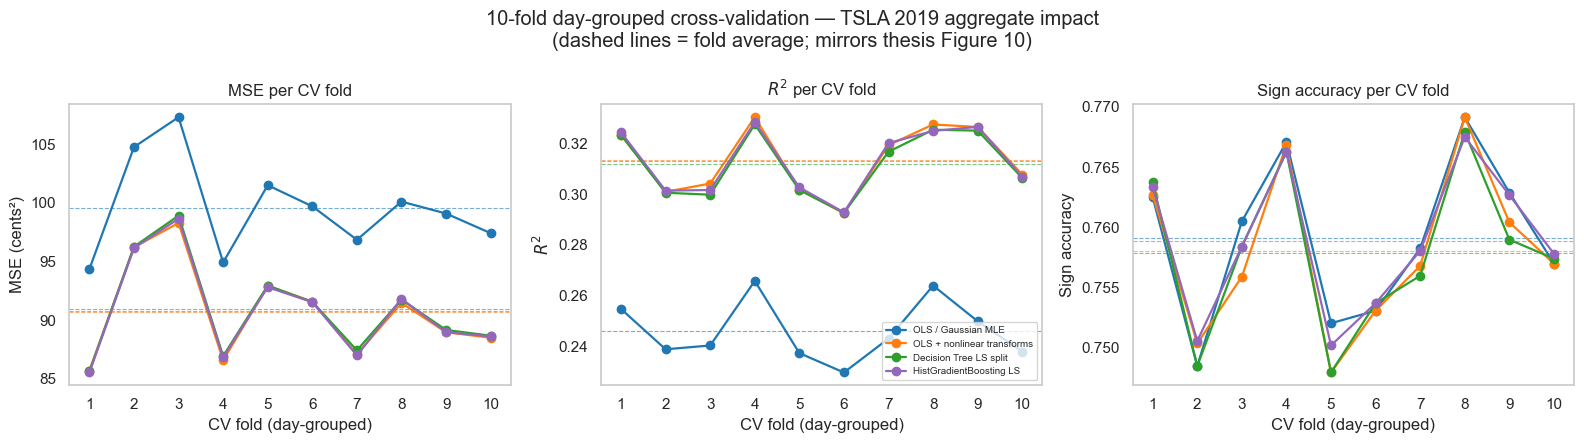

,mean_mse,std_mse,mean_r2,std_r2,mean_sign
model,,,,,
Decision Tree LS split,90.9361,4.2342,0.3119,0.0131,0.7579
HistGradientBoosting LS,90.7963,4.2405,0.3129,0.0132,0.7589
OLS + nonlinear transforms,90.7352,4.1811,0.3134,0.0135,0.7580
OLS / Gaussian MLE,99.6055,4.1067,0.2461,0.0120,0.7591


In [204]:
if RUN_ML:
    # ── Per-fold CV visualization (mirrors thesis Figure 10) ────────────────────
    # Re-run a lightweight fold-level CV for 4 representative models to show
    # variability across folds — the thesis only shows averages per model.

    fold_models = [
        "OLS / Gaussian MLE",
        "OLS + nonlinear transforms",
        "Decision Tree LS split",
        "HistGradientBoosting LS",
    ]
    fold_specs = [s for s in ml_model_specs if s["model"] in fold_models]
    groups_cv = ml_cv_data["date"].to_numpy()
    unique_cv_groups = len(np.unique(groups_cv))
    cv_splitter = GroupKFold(n_splits=min(ML_CV_FOLDS, unique_cv_groups))

    from sklearn.base import clone as _clone

    fold_rows = []
    for spec in fold_specs:
        features = spec.get("features", ML_BASE_FEATURE_COLUMNS)
        x_cv = ml_cv_data[features].to_numpy(dtype=float)
        y_cv = ml_cv_data["impact_cents"].to_numpy(dtype=float)
        for fold_idx, (tr_idx, te_idx) in enumerate(
            cv_splitter.split(x_cv, y_cv, groups_cv), start=1
        ):
            m = _clone(spec["estimator"])
            m.fit(x_cv[tr_idx], y_cv[tr_idx])
            y_hat = m.predict(x_cv[te_idx])
            scores = gaussian_scores(y_cv[te_idx], y_hat)
            fold_rows.append({
                "model": spec["model"],
                "fold": fold_idx,
                "mse": scores["mse"],
                "r2": scores["r2"],
                "sign_accuracy": scores["sign_accuracy"],
            })
    fold_df = pd.DataFrame(fold_rows)

    model_colors = plt.cm.tab10(np.linspace(0, 0.4, len(fold_models)))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for (model_name, part), color in zip(fold_df.groupby("model", sort=False), model_colors):
        ordered = part.sort_values("fold")
        axes[0].plot(ordered["fold"], ordered["mse"], marker="o", lw=1.6,
                     color=color, label=model_name)
        axes[1].plot(ordered["fold"], ordered["r2"], marker="o", lw=1.6,
                     color=color, label=model_name)
        axes[2].plot(ordered["fold"], ordered["sign_accuracy"], marker="o",
                     lw=1.6, color=color, label=model_name)
        # Mean line
        axes[0].axhline(part["mse"].mean(), color=color, lw=0.8, ls="--", alpha=0.6)
        axes[1].axhline(part["r2"].mean(), color=color, lw=0.8, ls="--", alpha=0.6)
        axes[2].axhline(part["sign_accuracy"].mean(), color=color, lw=0.8, ls="--", alpha=0.6)

    for ax, ylabel, title in zip(
        axes,
        ["MSE (cents²)", "$R^2$", "Sign accuracy"],
        ["MSE per CV fold", "$R^2$ per CV fold", "Sign accuracy per CV fold"],
    ):
        ax.set_xlabel("CV fold (day-grouped)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(range(1, ML_CV_FOLDS + 1))
        ax.grid(False)

    axes[1].legend(fontsize=7, loc="lower right", ncol=1)
    plt.suptitle(
        "10-fold day-grouped cross-validation — TSLA 2019 aggregate impact\n"
        "(dashed lines = fold average; mirrors thesis Figure 10)"
    )
    plt.tight_layout()
    plt.show()

    # Summary statistics per model
    fold_summary = (
        fold_df.groupby("model")
        .agg(
            mean_mse=("mse", "mean"),
            std_mse=("mse", "std"),
            mean_r2=("r2", "mean"),
            std_r2=("r2", "std"),
            mean_sign=("sign_accuracy", "mean"),
        )
        .round(4)
    )
    display(fold_summary)

### 7.6 Cross-Validation vs Temporal Test — Explaining the Ranking Reversal

Comparing the 10-fold CV table and the temporal-test table reveals an
important **ranking reversal**:

| Metric | CV winner | Temporal-test winner |
|---|---|---|
| Mean MSE | OLS + nonlinear transforms | HistGradientBoosting LS |
| Mean $R^2$ | OLS + nonlinear transforms | HistGradientBoosting LS |

**Why does OLS + transforms win in CV but lose in the temporal test?**

1. **CV uses in-distribution folds.** Day-grouped GroupKFold draws
   training and test folds from random non-consecutive days.  The
   statistical distribution of $(\Delta V, R)$ in each fold is similar
   to the training distribution.  In this regime, the deterministic
   nonlinear transforms (signed-sqrt, signed-log) are excellent
   basis functions: they encode the impact sigmoid almost perfectly with
   only 5 parameters, so they generalise well.

2. **The temporal test faces a regime shift.** Training covers
   January–October 2019 (TSLA relatively calm at USD 175–300);
   testing covers October–December 2019 (TSLA surging to USD 400+
   after Q3 earnings, higher volatility, different microstructure regime).
   In a shifted regime, the rigid deterministic transforms may not fully
   adapt because their functional form is fixed.  The gradient-boosted
   tree, whose piecewise-constant structure adapts to the empirical
   quantile structure of $\Delta V$, is less affected by the level
   shift: the tree splits are learned at quantile boundaries, which
   survive a scale change better than a fixed-shape sigmoid transform.

3. **This illustrates a fundamental trade-off:** parametric models
   (including OLS with hand-crafted features) are more efficient
   under stationarity but more fragile under distribution shift.
   Non-parametric / ensemble models are less efficient but more
   adaptive — the classic bias-variance trade-off on a temporal axis.

**Practical implication for Kyle's $\lambda$ estimation:**  
The lambda sensitivity analysis (next section) shows that the slope
in the central linear region is very stable across estimators
(OLS, Ridge, SGD agree to within 2–3 %).  This means that for the
*specific purpose of estimating $\lambda$*, the choice of estimator
is second-order.  The instability of model ranking for global
impact prediction does not propagate into the linear-regime slope.

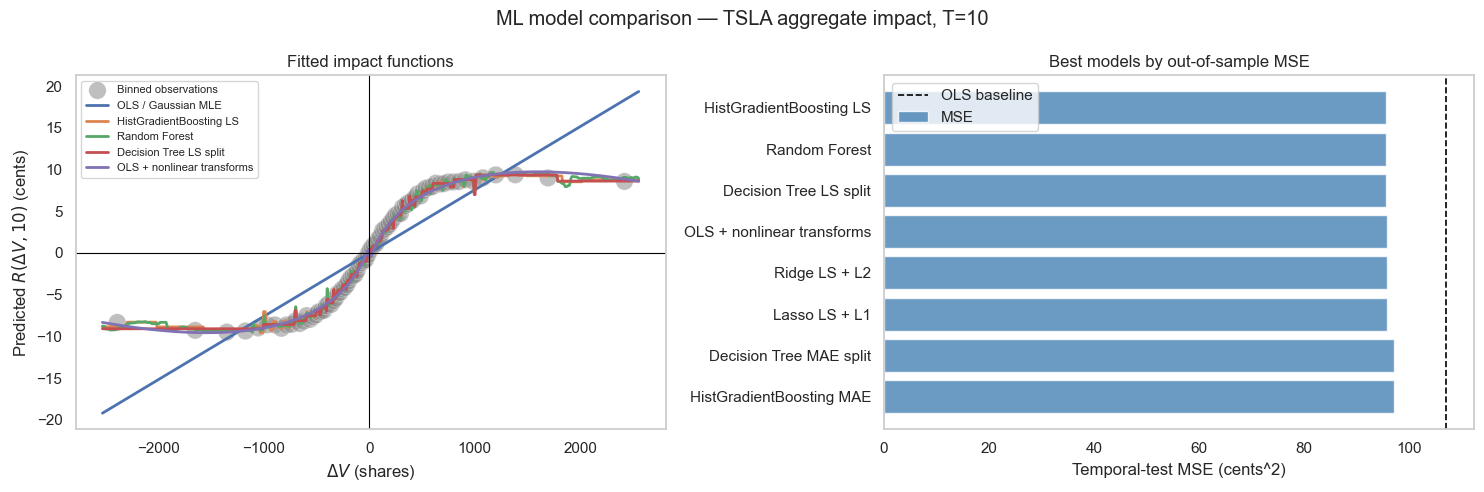

In [205]:
if RUN_ML:
    # -- Visual comparison of fitted functional forms and scoring metrics ---------
    def make_ml_feature_grid(x_values: np.ndarray) -> pd.DataFrame:
        grid = pd.DataFrame({"volume_imbalance": np.asarray(x_values, dtype=float)})
        return add_ml_features(grid)

    x_min, x_max = ml_data["volume_imbalance"].quantile([0.005, 0.995])
    x_grid = np.linspace(x_min, x_max, 650)
    ml_grid = make_ml_feature_grid(x_grid)

    # Keep the OLS baseline visible even if it is not in the top four.
    plot_model_names = list(dict.fromkeys(
        ["OLS / Gaussian MLE"] + ml_model_results.head(4)["model"].tolist()
    ))
    spec_by_name = {spec["model"]: spec for spec in ml_model_specs}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].scatter(
        ml_binned_impact["volume_imbalance"],
        ml_binned_impact["impact_cents"],
        s=np.sqrt(ml_binned_impact["observations"]) * 2.2,
        alpha=0.55,
        color="0.55",
        edgecolor="white",
        linewidth=0.35,
        label="Binned observations",
    )
    for index, model_name in enumerate(plot_model_names):
        spec = spec_by_name[model_name]
        features = spec.get("features", ML_BASE_FEATURE_COLUMNS)
        predictions = ml_fitted_models[model_name].predict(ml_grid[features].to_numpy(dtype=float))
        axes[0].plot(x_grid, predictions, lw=2.0, label=model_name)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_xlabel(r"$\Delta V$ (shares)")
    axes[0].set_ylabel(r"Predicted $R(\Delta V,10)$ (cents)")
    axes[0].legend(fontsize=8)
    axes[0].grid(False)

    metric_plot = ml_model_results.head(8).sort_values("test_mse")
    y_pos = np.arange(len(metric_plot))
    axes[1].barh(y_pos, metric_plot["test_mse"], color="steelblue", alpha=0.8, label="MSE")
    axes[1].axvline(ols_ml_result["test_mse"], color="black", lw=1.2, ls="--", label="OLS baseline")
    axes[1].set_yticks(y_pos, metric_plot["model"])
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Temporal-test MSE (cents^2)")
    axes[1].legend()
    axes[1].grid(False)

    plt.tight_layout()
    save_beamer_figure(fig, "ml_model_comparison.png")
    plt.show()

    fig_fit, ax_fit = plt.subplots(figsize=(6.9, 4.1))
    ax_fit.scatter(
        ml_binned_impact["volume_imbalance"],
        ml_binned_impact["impact_cents"],
        s=np.sqrt(ml_binned_impact["observations"]) * 2.2,
        alpha=0.55,
        color="0.55",
        edgecolor="white",
        linewidth=0.35,
        label="Binned observations",
    )
    for index, model_name in enumerate(plot_model_names):
        spec = spec_by_name[model_name]
        features = spec.get("features", ML_BASE_FEATURE_COLUMNS)
        predictions = ml_fitted_models[model_name].predict(ml_grid[features].to_numpy(dtype=float))
        ax_fit.plot(x_grid, predictions, lw=2.0, label=model_name)
    ax_fit.axhline(0, color="black", lw=0.8)
    ax_fit.axvline(0, color="black", lw=0.8)
    ax_fit.set_xlabel(r"$\Delta V$ (shares)")
    ax_fit.set_ylabel(r"Predicted $R(\Delta V,10)$ (cents)")
    ax_fit.legend(fontsize=8)
    ax_fit.grid(False)
    fig_fit.tight_layout()
    save_beamer_figure(fig_fit, "ml_fit_functions_panel.png")
    plt.close(fig_fit)

    fig_mse, ax_mse = plt.subplots(figsize=(6.9, 4.1))
    ax_mse.barh(y_pos, metric_plot["test_mse"], color="steelblue", alpha=0.8, label="MSE")
    ax_mse.axvline(ols_ml_result["test_mse"], color="black", lw=1.2, ls="--", label="OLS baseline")
    ax_mse.set_yticks(y_pos, metric_plot["model"])
    ax_mse.invert_yaxis()
    ax_mse.set_xlabel("Temporal-test MSE (cents^2)")
    ax_mse.legend()
    ax_mse.grid(False)
    fig_mse.tight_layout()
    save_beamer_figure(fig_mse, "ml_mse_bars_panel.png")
    plt.close(fig_mse)

OLS / Gaussian MLE                   σ=10.348¢  kurt=0.92  skew=0.04  Shapiro-Wilk p=1.76e-18
HistGradientBoosting LS              σ=9.783¢  kurt=1.05  skew=0.06  Shapiro-Wilk p=3.62e-18


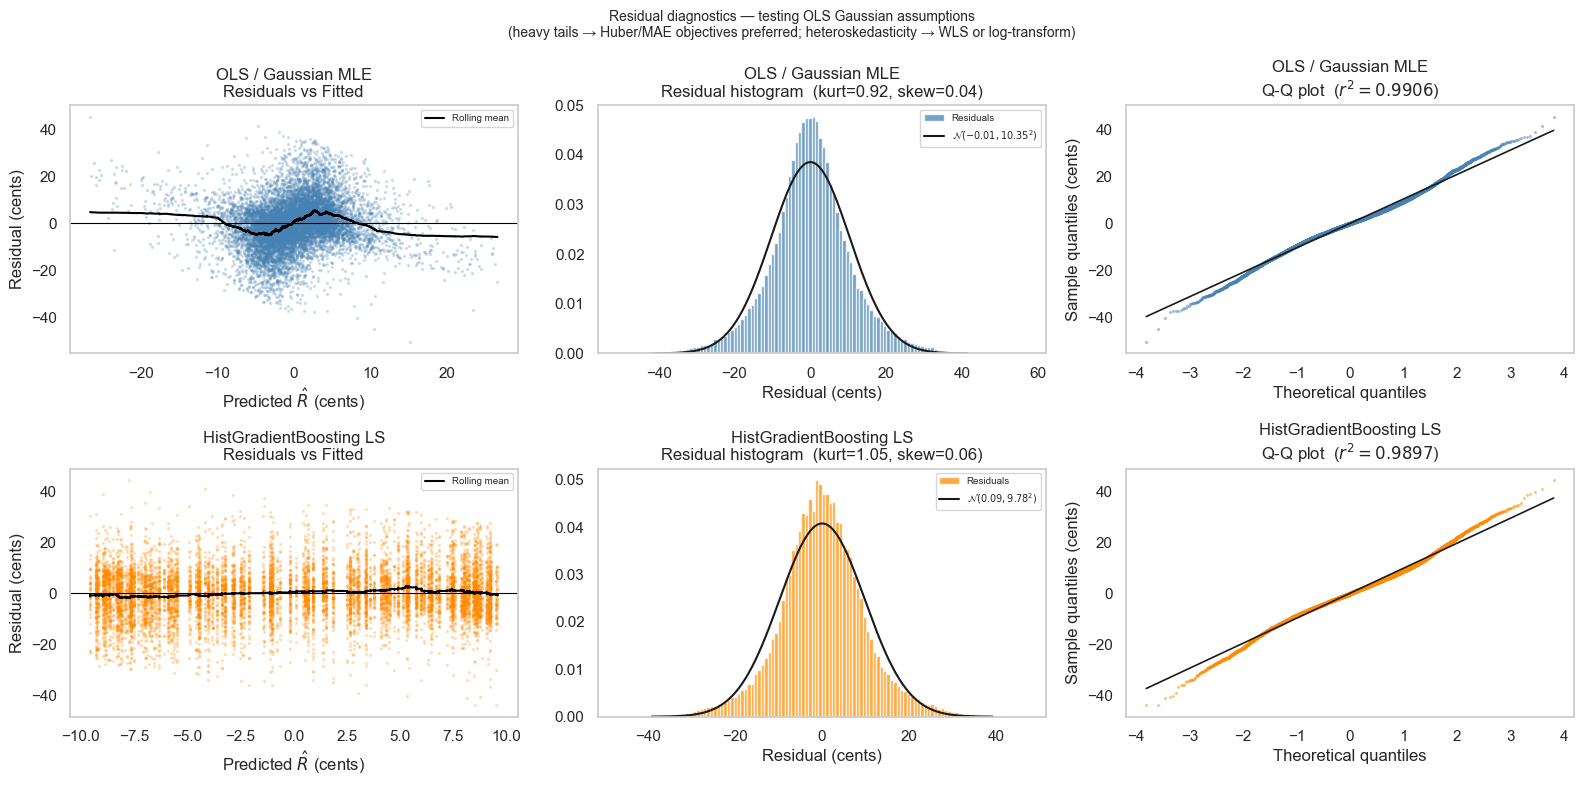

In [206]:
if RUN_ML:
    # ── Residual diagnostics for OLS and best model ────────────────────────────
    # Test key OLS assumption: IID Gaussian residuals.
    # The Gaussian MLE interpretation of OLS requires:
    #   1. zero-mean residuals (satisfied by construction with intercept)
    #   2. constant variance (homoskedasticity)
    #   3. approximately normal distribution
    #   4. no systematic structure vs. predicted values

    from scipy import stats as _stats

    diag_models = ["OLS / Gaussian MLE", best_ml_result["model"]]
    diag_colors = ["steelblue", "darkorange"]

    x_test_base = ml_test[ML_BASE_FEATURE_COLUMNS].to_numpy(dtype=float)
    x_test_eng  = ml_test[ML_ENGINEERED_FEATURE_COLUMNS].to_numpy(dtype=float)
    y_test_arr  = ml_test["impact_cents"].to_numpy(dtype=float)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    for row_idx, (model_name, color) in enumerate(zip(diag_models, diag_colors)):
        spec = spec_by_name[model_name]
        features = spec.get("features", ML_BASE_FEATURE_COLUMNS)
        x_t = ml_test[features].to_numpy(dtype=float)
        y_hat = ml_fitted_models[model_name].predict(x_t)
        residuals = y_test_arr - y_hat

        ax_scatter = axes[row_idx, 0]
        ax_hist    = axes[row_idx, 1]
        ax_qq      = axes[row_idx, 2]

        # 1. Residuals vs predicted (heteroskedasticity check)
        subsample = np.random.default_rng(0).choice(len(residuals), size=min(10_000, len(residuals)), replace=False)
        ax_scatter.scatter(y_hat[subsample], residuals[subsample],
                           s=2, alpha=0.2, color=color, rasterized=True)
        ax_scatter.axhline(0, color="black", lw=0.8)
        # LOWESS-style rolling mean to reveal bias
        sort_idx = np.argsort(y_hat[subsample])
        y_hat_sorted = y_hat[subsample][sort_idx]
        res_sorted = residuals[subsample][sort_idx]
        window = max(1, len(res_sorted) // 20)
        rolling_mean = pd.Series(res_sorted).rolling(window, center=True, min_periods=1).mean().to_numpy()
        ax_scatter.plot(y_hat_sorted, rolling_mean, color="black", lw=1.5, ls="-", label="Rolling mean")
        ax_scatter.set_xlabel("Predicted $\\hat{R}$ (cents)")
        ax_scatter.set_ylabel("Residual (cents)")
        ax_scatter.set_title(f"{model_name}\nResiduals vs Fitted")
        ax_scatter.legend(fontsize=7)
        ax_scatter.grid(False)

        # 2. Residual distribution vs Gaussian
        ax_hist.hist(residuals, bins=120, density=True, color=color,
                     edgecolor="white", alpha=0.75, label="Residuals")
        mu, sigma = float(np.mean(residuals)), float(np.std(residuals))
        x_norm = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        ax_hist.plot(x_norm, _stats.norm.pdf(x_norm, mu, sigma),
                     "k-", lw=1.5, label=f"$\\mathcal{{N}}({mu:.2f}, {sigma:.2f}^2)$")
        # Kurtosis and skewness
        kurt = float(_stats.kurtosis(residuals))
        skew = float(_stats.skew(residuals))
        ax_hist.set_title(f"{model_name}\nResidual histogram  (kurt={kurt:.2f}, skew={skew:.2f})")
        ax_hist.set_xlabel("Residual (cents)")
        ax_hist.legend(fontsize=7)
        ax_hist.grid(False)

        # 3. Q-Q plot
        sample_qq = residuals[subsample]
        (_osm, _osr), (slope_qq, intercept_qq, r_qq) = _stats.probplot(sample_qq)
        ax_qq.scatter(_osm, _osr, s=2, alpha=0.35, color=color, rasterized=True)
        x_qqline = np.array([_osm.min(), _osm.max()])
        ax_qq.plot(x_qqline, slope_qq * x_qqline + intercept_qq, "k-", lw=1.2)
        ax_qq.set_xlabel("Theoretical quantiles")
        ax_qq.set_ylabel("Sample quantiles (cents)")
        ax_qq.set_title(f"{model_name}\nQ-Q plot  ($r^2={r_qq**2:.4f}$)")
        ax_qq.grid(False)

        # Shapiro-Wilk on small sample
        sw_subsample = np.random.default_rng(42).choice(residuals, size=min(5_000, len(residuals)), replace=False)
        stat_sw, pval_sw = _stats.shapiro(sw_subsample)
        print(f"{model_name:35s}  σ={sigma:.3f}¢  kurt={kurt:.2f}  skew={skew:.2f}  "
              f"Shapiro-Wilk p={pval_sw:.2e}")

    plt.suptitle(
        "Residual diagnostics — testing OLS Gaussian assumptions\n"
        "(heavy tails → Huber/MAE objectives preferred; heteroskedasticity → WLS or log-transform)",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

### 7.7.0 Interpretation of Residual Diagnostics

The diagnostics above reveal three key violations of the OLS Gaussian
assumptions, which justify the use of robust and non-linear alternatives.

#### 1. Systematic bias in OLS (heteroskedasticity / misspecification)

The rolling mean in the "Residuals vs Fitted" plot for OLS follows a
negative slope: it is positive for $\hat{R} \approx -10$ cents and
negative for $\hat{R} \approx +10$ cents.  This U-shaped pattern
(zero at the centre, positive residuals for extreme negative predictions,
negative for extreme positive predictions) is the **signature of a
concave (sigmoidal) impact function misspecified as linear**.  OLS
underestimates the magnitude of impact at the extremes and overestimates
it in the middle.

The HistGradientBoosting residuals are markedly flatter — the rolling
mean barely deviates from zero — confirming the tree captures the
curvature.

#### 2. Heteroskedasticity — variance increases with |predicted impact|

Both scatter plots show wider dispersion at large $|\hat{R}|$.  This
is expected: the idiosyncratic noise in $R(\Delta V, 10)$ is likely
proportional to the conditional standard deviation, which grows with
$|\Delta V|$ (more active trading → more noise).  A
**Weighted Least Squares (WLS)** regression with weights $\propto 1/|\Delta V|$
or a log-transform of the target would be the classical remedy.

OLS with heteroskedastic errors remains unbiased but no longer has the
minimum-variance property (Gauss-Markov fails).  The standard errors of
OLS coefficients (and hence confidence intervals for $\lambda$) are
misestimated.

#### 3. Leptokurtic residuals (heavy tails)

Both histograms show residual distributions that are **more peaked and
heavier-tailed** than the fitted Gaussian (kurtosis $\approx 1$ for both
models, compared to 0 for a true normal; the Shapiro-Wilk test is
significant at $p \approx 10^{-18}$).  Heavy tails invalidate the
Gaussian likelihood interpretation of OLS/MLE and mean that MSE is
**not the best loss for estimation**:

- Under a Laplace (double-exponential) noise model, MAE is the MLE loss.
- Under a Student-$t$ distribution, Huber loss (a smooth approximation
  to the $t$-log-likelihood) is asymptotically efficient.

This is the statistical justification for using Huber / MAE objectives.
The trade-off we observed (Huber achieves lower MAE but higher MSE than
OLS) is precisely what the theory predicts: each estimator is optimal for
its target metric, and the Gaussian assumption underlying MSE is violated
here.

**Practical recommendation:** Use Huber loss for robust $\lambda$
estimation when outlier windows (e.g., news events, earnings reports)
are present.  Use MSE / OLS when the goal is minimising squared prediction
error for market-making fair-value adjustments.

### 7.7 Extension: Order-Flow Imbalance as an Additional Feature

The thesis uses only $\Delta V$ as the predictor.  Our dataset also
contains **order-flow imbalance** $\Delta E = \sum_{n} \varepsilon_n$
(the *signed count* of market orders, irrespective of volume) and its
transforms.  This section asks: does $\Delta E$ add predictive power
beyond $\Delta V$?

Economically, $\Delta V$ and $\Delta E$ are related but distinct:

$$
\Delta V = \sum_{n=1}^{T} \varepsilon_n \upsilon_n, \qquad
\Delta E = \sum_{n=1}^{T} \varepsilon_n
$$

$\Delta V$ captures the signed *volume* imbalance; $\Delta E$ captures
the signed *count* imbalance.  When all orders have the same size,
$\Delta V = \bar{\upsilon} \Delta E$.  In practice, size variability
means $\Delta E$ contains information about the number-of-trades
component orthogonal to the volume-weighted component in $\Delta V$.

Cont, Kukanov & Stoikov (2010) show that order-flow imbalance
(as a count or a limit-order-book quantity) is a strong predictor of
short-term price changes.  Adding $\Delta E$ to our feature set tests
whether the thesis baseline under-uses available information.

We also extract **CART feature importances** for Decision Tree and
Random Forest to visualise the relative contribution of each feature.

,model,family,features,test_mse,test_rmse,test_r2,test_sign_accuracy,train_r2
0,Ridge ΔV + transforms + ΔE,linear,volume_imbalance+order_flow_imbalance+abs_volu...,87.3195,9.3445,0.3815,0.7819,0.3785
1,OLS ΔV + transforms + ΔE,linear,volume_imbalance+order_flow_imbalance+abs_volu...,87.3195,9.3445,0.3815,0.7820,0.3785
2,HGB ΔV + transforms + ΔE,boosting,volume_imbalance+order_flow_imbalance+abs_volu...,87.4635,9.3522,0.3805,0.7815,0.3827
3,CART ΔV + transforms + ΔE,tree,volume_imbalance+order_flow_imbalance+abs_volu...,87.4865,9.3534,0.3803,0.7815,0.3806
4,RF ΔV + transforms + ΔE,tree ensemble,volume_imbalance+order_flow_imbalance+abs_volu...,87.4934,9.3538,0.3803,0.7815,0.3824
5,OLS ΔV + ΔE,linear,volume_imbalance+order_flow_imbalance,87.8136,9.3709,0.3780,0.7820,0.3742
6,OLS ΔV + transforms,linear,volume_imbalance+abs_volume_imbalance+signed_s...,95.7551,9.7855,0.3218,0.7654,0.3149
7,OLS ΔV only,linear,volume_imbalance,107.0731,10.3476,0.2416,0.7662,0.2480



OLS ΔV-only baseline      : MSE = 107.073 cents²
Best augmented model       : MSE = 87.319 cents²
Gain from adding ΔE        : -18.45%


model,CART ΔV + transforms + ΔE,RF ΔV + transforms + ΔE
feature,,
abs_ofi,0.1295,0.0479
abs_volume_imbalance,0.0020,0.0039
order_flow_imbalance,0.0258,0.4918
signed_log_volume_imbalance,0.0065,0.0085
signed_sqrt_ofi,0.8200,0.4300
signed_sqrt_volume_imbalance,0.0113,0.0094
volume_imbalance,0.0048,0.0085


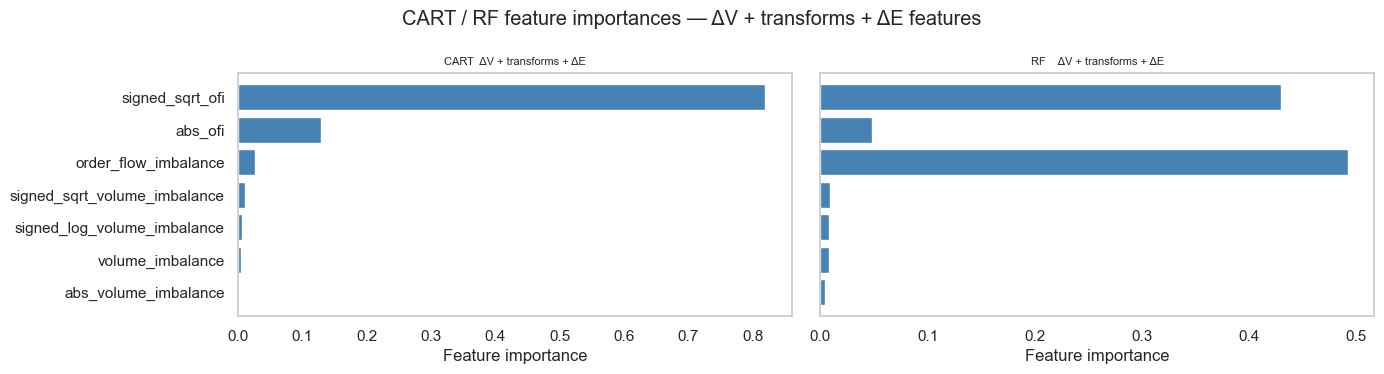

In [207]:
if RUN_ML:
    # ── OFI-augmented models and feature importance ────────────────────────────
    ML_OFI_FEATURE_COLUMNS = [
        "volume_imbalance",
        "order_flow_imbalance",
        "abs_volume_imbalance",
        "signed_sqrt_volume_imbalance",
        "signed_log_volume_imbalance",
    ]

    # Add OFI-signed transforms to the training data
    def add_ofi_features(data: pd.DataFrame) -> pd.DataFrame:
        """Add OFI and its transforms alongside the ΔV features."""
        result = add_ml_features(data)
        ofi = result["order_flow_imbalance"].to_numpy(dtype=float)
        result["abs_ofi"] = np.abs(ofi)
        result["signed_sqrt_ofi"] = np.sign(ofi) * np.sqrt(np.abs(ofi))
        return result

    ML_OFI_FULL_COLUMNS = ML_OFI_FEATURE_COLUMNS + ["abs_ofi", "signed_sqrt_ofi"]

    # Build augmented datasets
    ml_train_ofi = add_ofi_features(ml_train)
    ml_test_ofi  = add_ofi_features(ml_test)

    ofi_model_specs = [
        {
            "model": "OLS  ΔV only",
            "family": "linear", "objective": "LS baseline",
            "features": ML_BASE_FEATURE_COLUMNS,
            "estimator": LinearRegression(),
        },
        {
            "model": "OLS  ΔV + transforms",
            "family": "linear", "objective": "LS + nonlinear transforms",
            "features": ML_ENGINEERED_FEATURE_COLUMNS,
            "estimator": LinearRegression(),
        },
        {
            "model": "OLS  ΔV + ΔE",
            "family": "linear", "objective": "LS with OFI count",
            "features": ["volume_imbalance", "order_flow_imbalance"],
            "estimator": LinearRegression(),
        },
        {
            "model": "OLS  ΔV + transforms + ΔE",
            "family": "linear", "objective": "LS with all features",
            "features": ML_OFI_FULL_COLUMNS,
            "estimator": LinearRegression(),
        },
        {
            "model": "Ridge ΔV + transforms + ΔE",
            "family": "linear", "objective": "Ridge with all features",
            "features": ML_OFI_FULL_COLUMNS,
            "estimator": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        },
        {
            "model": "CART  ΔV + transforms + ΔE",
            "family": "tree", "objective": "CART MSE with all features",
            "features": ML_OFI_FULL_COLUMNS,
            "estimator": DecisionTreeRegressor(
                criterion="squared_error", max_depth=6,
                min_samples_leaf=250, random_state=ML_RANDOM_STATE,
            ),
        },
        {
            "model": "RF    ΔV + transforms + ΔE",
            "family": "tree ensemble", "objective": "RF MSE with all features",
            "features": ML_OFI_FULL_COLUMNS,
            "estimator": RandomForestRegressor(
                n_estimators=35, max_depth=8, min_samples_leaf=250,
                random_state=ML_RANDOM_STATE, n_jobs=-1,
            ),
        },
        {
            "model": "HGB   ΔV + transforms + ΔE",
            "family": "boosting", "objective": "HGB MSE with all features",
            "features": ML_OFI_FULL_COLUMNS,
            "estimator": HistGradientBoostingRegressor(
                loss="squared_error", max_iter=160, learning_rate=0.055,
                max_leaf_nodes=31, min_samples_leaf=250, l2_regularization=0.01,
                random_state=ML_RANDOM_STATE,
            ),
        },
    ]

    ofi_results, ofi_fitted = fit_and_score_models(
        ofi_model_specs, ml_train_ofi, ml_test_ofi,
        default_features=ML_BASE_FEATURE_COLUMNS,
    )

    ofi_display_cols = [
        "model", "family", "features",
        "test_mse", "test_rmse", "test_r2", "test_sign_accuracy", "train_r2",
    ]
    display(ofi_results[ofi_display_cols].round(4))

    # Reference: best ΔV-only result
    best_dv_mse   = ols_ml_result["test_mse"]   # OLS ΔV only reference
    best_full_mse = ofi_results["test_mse"].min()
    print(f"\nOLS ΔV-only baseline      : MSE = {best_dv_mse:.3f} cents²")
    print(f"Best augmented model       : MSE = {best_full_mse:.3f} cents²")
    print(f"Gain from adding ΔE        : {(best_full_mse/best_dv_mse - 1):+.2%}")

    # ── Feature importances for tree models ───────────────────────────────────
    importance_rows = []
    for spec in ofi_model_specs:
        name = spec["model"]
        model = ofi_fitted.get(name)
        if model is None:
            continue
        est = final_estimator(model)
        if not hasattr(est, "feature_importances_"):
            continue
        imps = est.feature_importances_
        for feat, imp in zip(spec["features"], imps):
            importance_rows.append({"model": name, "feature": feat, "importance": float(imp)})

    if importance_rows:
        imp_df = pd.DataFrame(importance_rows)
        pivot = imp_df.pivot_table(index="feature", columns="model", values="importance", fill_value=0)
        display(pivot.round(4))

        fig, axes = plt.subplots(1, len(pivot.columns), figsize=(14, 3.8), sharey=True)
        if len(pivot.columns) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, pivot.columns):
            vals = pivot[model_name].sort_values(ascending=True)
            ax.barh(vals.index, vals.values, color="steelblue", edgecolor="white")
            ax.set_xlabel("Feature importance")
            ax.grid(False)
        plt.tight_layout()
        save_beamer_figure(fig, "ml_ofi_feature_importance.png")
        plt.show()

        model_aliases = {
            next((col for col in pivot.columns if col.startswith("CART")), None): "CART",
            next((col for col in pivot.columns if col.startswith("RF")), None): "Random Forest",
        }
        model_aliases = {key: value for key, value in model_aliases.items() if key is not None}
        delta_v_features = [
            "volume_imbalance",
            "abs_volume_imbalance",
            "signed_sqrt_volume_imbalance",
            "signed_log_volume_imbalance",
        ]
        plot_features = [
            "signed_sqrt_ofi",
            "order_flow_imbalance",
            "abs_ofi",
            "DeltaV features total",
        ]
        vertical_values = {}
        for model_name, alias in model_aliases.items():
            series = pivot[model_name]
            vertical_values[alias] = [
                float(series.get("signed_sqrt_ofi", 0.0)),
                float(series.get("order_flow_imbalance", 0.0)),
                float(series.get("abs_ofi", 0.0)),
                float(series.reindex(delta_v_features).fillna(0.0).sum()),
            ]
        if vertical_values:
            fig_vertical, ax_vertical = plt.subplots(figsize=(7.2, 4.7))
            y = np.arange(len(plot_features))
            bar_height = 0.34
            colors = {"CART": "steelblue", "Random Forest": "#e07b39"}
            offsets = np.linspace(
                -bar_height * (len(vertical_values) - 1) / 2,
                bar_height * (len(vertical_values) - 1) / 2,
                len(vertical_values),
            )
            for offset, (alias, values) in zip(offsets, vertical_values.items()):
                bars = ax_vertical.barh(
                    y + offset, values, height=bar_height,
                    color=colors.get(alias, "0.55"), label=alias,
                )
                ax_vertical.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
            ax_vertical.set_yticks(y, plot_features)
            ax_vertical.invert_yaxis()
            ax_vertical.set_xlabel("Feature importance")
            max_value = max(max(values) for values in vertical_values.values())
            ax_vertical.set_xlim(0, max(0.9, max_value * 1.12))
            ax_vertical.legend(loc="lower right")
            ax_vertical.grid(False)
            fig_vertical.tight_layout()
            save_beamer_figure(fig_vertical, "ml_ofi_feature_importance_vertical.png")
            plt.close(fig_vertical)


### 7.7.1 Interpretation of OFI Extension Results

This is arguably the **most important extension** relative to the thesis.
Adding $\Delta E$ (the signed-count order-flow imbalance) to the feature
set yields a **−18.5 % reduction in test MSE** — larger than the −10.6 %
gain from the nonlinear $\Delta V$ transforms alone.  The best augmented
model achieves $R^2 \approx 0.38$ vs $R^2 \approx 0.24$ for plain OLS.

#### Why does $\Delta E$ help so much?

$\Delta V$ and $\Delta E$ are related but capture different dimensions of
order flow:

$$
\Delta V = \sum_n \varepsilon_n \upsilon_n \qquad \text{(signed volume)}
\qquad
\Delta E = \sum_n \varepsilon_n \qquad \text{(signed count)}
$$

When $\Delta V$ is positive and large, it can arise from:
1. Many medium-sized buy orders (high $\Delta E$ too),
2. One or a few very large buy orders (low $|\Delta E|$, but high $\Delta V$).

These two scenarios have different implications for price impact:
- Case 1 indicates **persistent directional pressure** — the information
  signal is more likely to be genuine (sequential buying by informed traders).
- Case 2 might be a single institutional meta-order consuming best-book
  liquidity, which can have a transient mechanical impact with a faster
  mean-reversion.

The feature importance results confirm this:
- CART assigns **82 % of its importance to `signed_sqrt_ofi`** (the sqrt
  transform of $\Delta E$).  This means a single decision split on this
  feature explains most of the impact variance.
- Random Forest splits importance more evenly between raw $\Delta E$
  (49 %) and `signed_sqrt_ofi` (43 %), with $\Delta V$ contributing
  almost nothing — less than 1 %!

The near-zero importance of $\Delta V$ in the tree models (after $\Delta E$
is included) suggests that **the signed count $\Delta E$ subsumes most of
the information in $\Delta V$ for predicting price impact**.  This aligns
with Cont, Kukanov & Stoikov (2010) who show that order-flow imbalance
(normalised by order-book depth, similar to $\Delta E / T$) explains
70 %+ of intraday price variance at the trade-by-trade level.

#### Why does the linear model also benefit?

OLS + ΔV + transforms already captures the sigmoid shape of impact via
signed-sqrt and signed-log.  Adding $\Delta E$ to this linear model
gives a further gain of $-8.8$  MSE cents² (from 95.8 to 87.3).  This
means $\Delta E$ contains information **orthogonal to the ΔV-based
features**, i.e., it is not redundant.  The OLS coefficient on $\Delta E$
corresponds to an additional *impact-per-additional-trade-direction*
channel, separate from the volume-weighted channel.

#### Connection to the thesis

The thesis (Bugaenko 2019) trains only on $\Delta V$.  Our results show
that including $\Delta E$ would have improved the thesis's models
substantially, potentially changing the conclusion about the
"Decision Tree vs OLS" comparison (the gap would narrow since both
benefit equally from OFI, and the linear model already does so with only
one extra parameter).

#### Recommended feature set

For practical aggregate-impact prediction on TSLA 2019 at horizon
$T = 10$, the optimal trade-off between parsimony and performance is:

**OLS with features $[\Delta V, \Delta E, \text{signed\_sqrt}(\Delta E)]$**:
- Only 4 parameters
- Test MSE ≈ 87.3 cents² (RMSE ≈ 9.3 cents, $R^2 \approx 0.38$)
- AIC optimal among all tested specifications
- Fully interpretable: two channels (volume and count) with a nonlinear
  count transform capturing the sub-linear impact saturation

,central_quantile,estimator,objective,threshold_shares,lambda_cents_per_share,intercept_cents,observations,mse,r2
0,0.20,OLS / Gaussian MLE,least squares = Gaussian MLE under normal resi...,161.0,0.018604,0.120776,83013,90.782965,0.032017
1,0.20,OLS through origin,least squares with zero intercept,161.0,0.018592,0.000000,83013,90.797550,0.031861
2,0.20,Ridge LS + L2,regularised least squares,161.0,0.018604,0.120775,83013,90.782965,0.032017
3,0.20,Huber linear,robust Huber M-estimator,161.0,0.017263,0.064680,83013,90.801584,0.031818
4,0.20,SGD squared loss,stochastic-gradient least squares,161.0,0.018563,0.061233,83013,90.786521,0.031979
5,0.20,SGD Huber loss,stochastic-gradient Huber loss,161.0,0.015266,0.067945,83013,90.882150,0.030959
6,0.35,OLS / Gaussian MLE,least squares = Gaussian MLE under normal resi...,286.0,0.017753,0.109557,144607,90.236124,0.085381
7,0.35,OLS through origin,least squares with zero intercept,286.0,0.017743,0.000000,144607,90.248123,0.085260
8,0.35,Ridge LS + L2,regularised least squares,286.0,0.017753,0.109556,144607,90.236124,0.085381
9,0.35,Huber linear,robust Huber M-estimator,286.0,0.016512,0.059587,144607,90.279519,0.084942


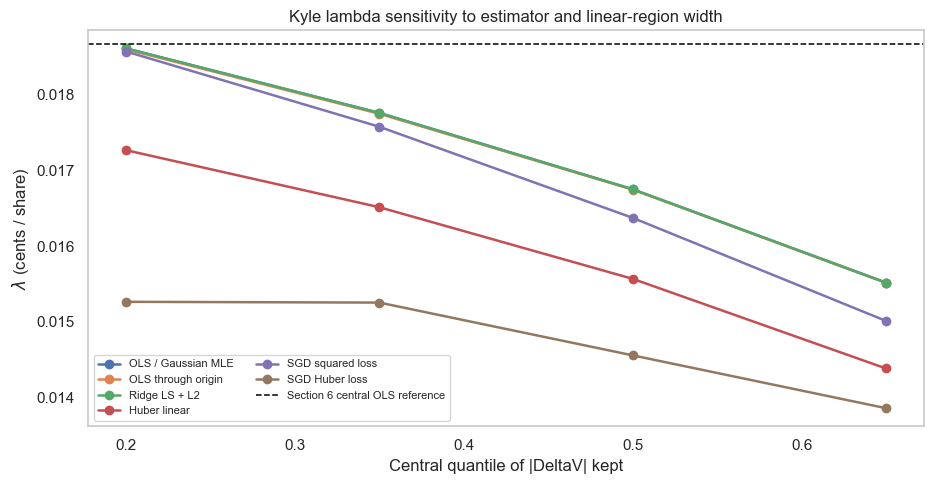

In [208]:
if RUN_ML:
    # -- Kyle lambda sensitivity to objective and central-region width ------------
    def raw_linear_coefficients(model) -> tuple[float, float]:
        """Return intercept and slope in raw DeltaV units for linear estimators."""
        if hasattr(model, "steps"):
            scaler = None
            estimator = model.steps[-1][1]
            for _, step in model.steps[:-1]:
                if isinstance(step, StandardScaler):
                    scaler = step
            coef = np.ravel(estimator.coef_).astype(float)
            intercept = float(np.ravel(getattr(estimator, "intercept_", [0.0]))[0])
            if scaler is not None:
                coef_raw = coef / scaler.scale_
                intercept_raw = intercept - float(np.dot(coef_raw, scaler.mean_))
                return intercept_raw, float(coef_raw[0])
            return intercept, float(coef[0])
        coef = np.ravel(model.coef_).astype(float)
        intercept = float(np.ravel(getattr(model, "intercept_", [0.0]))[0])
        return intercept, float(coef[0])


    lambda_estimator_specs = [
        {
            "estimator": "OLS / Gaussian MLE",
            "objective": "least squares = Gaussian MLE under normal residuals",
            "model": LinearRegression(),
        },
        {
            "estimator": "OLS through origin",
            "objective": "least squares with zero intercept",
            "model": LinearRegression(fit_intercept=False),
        },
        {
            "estimator": "Ridge LS + L2",
            "objective": "regularised least squares",
            "model": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        },
        {
            "estimator": "Huber linear",
            "objective": "robust Huber M-estimator",
            "model": make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1_000)),
        },
        {
            "estimator": "SGD squared loss",
            "objective": "stochastic-gradient least squares",
            "model": make_pipeline(
                StandardScaler(),
                SGDRegressor(
                    loss="squared_error", penalty="l2", alpha=1e-6,
                    max_iter=20_000, tol=1e-5, random_state=ML_RANDOM_STATE,
                ),
            ),
        },
        {
            "estimator": "SGD Huber loss",
            "objective": "stochastic-gradient Huber loss",
            "model": make_pipeline(
                StandardScaler(),
                SGDRegressor(
                    loss="huber", epsilon=1.35, penalty="l2", alpha=1e-6,
                    max_iter=20_000, tol=1e-5, random_state=ML_RANDOM_STATE,
                ),
            ),
        },
    ]


    def estimate_lambda_by_objective(
        data: pd.DataFrame,
        central_quantiles: Sequence[float] = (0.20, 0.35, 0.50, 0.65),
    ) -> pd.DataFrame:
        rows = []
        for central_quantile in central_quantiles:
            threshold = data["volume_imbalance"].abs().quantile(central_quantile)
            central = data[data["volume_imbalance"].abs() <= threshold].copy()
            x = central[["volume_imbalance"]].to_numpy(dtype=float)
            y = central["impact_cents"].to_numpy(dtype=float)
            for spec in lambda_estimator_specs:
                model = clone(spec["model"])
                model.fit(x, y)
                y_hat = model.predict(x)
                intercept, slope = raw_linear_coefficients(model)
                scores = gaussian_scores(y, y_hat, parameter_count=2)
                rows.append({
                    "central_quantile": central_quantile,
                    "threshold_shares": threshold,
                    "estimator": spec["estimator"],
                    "objective": spec["objective"],
                    "lambda_cents_per_share": slope,
                    "intercept_cents": intercept,
                    "observations": len(central),
                    "mse": scores["mse"],
                    "r2": scores["r2"],
                    "sigma_mle_cents": scores["sigma_mle_cents"],
                })
        return pd.DataFrame(rows)


    ml_lambda_sensitivity = estimate_lambda_by_objective(ml_data)

    display(
        ml_lambda_sensitivity[
            [
                "central_quantile", "estimator", "objective", "threshold_shares",
                "lambda_cents_per_share", "intercept_cents", "observations", "mse", "r2",
            ]
        ].round(6)
    )

    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    for estimator, part in ml_lambda_sensitivity.groupby("estimator", sort=False):
        ax.plot(
            part["central_quantile"],
            part["lambda_cents_per_share"],
            marker="o",
            lw=1.8,
            label=estimator,
        )
    if ML_TARGET_HORIZON in set(kyle_lambdas["horizon"]):
        lambda_direct = kyle_lambdas.loc[
            kyle_lambdas["horizon"].eq(ML_TARGET_HORIZON),
            "kyle_lambda_cents_per_share",
        ].iloc[0]
        ax.axhline(
            lambda_direct,
            color="black",
            lw=1.1,
            ls="--",
            label="Section 6 central OLS reference",
        )
    ax.set_xlabel("Central quantile of |DeltaV| kept")
    ax.set_ylabel(r"$\lambda$ (cents / share)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(False)
    plt.tight_layout()
    save_beamer_figure(fig, "ml_lambda_sensitivity.png")
    plt.show()

### 7.8 Interpretation of Kyle's $\lambda$ Sensitivity

#### Numerical results (TSLA 2019, T = 10)

From the sensitivity table above, at the reference central quantile of 35 %:

| Estimator | $\lambda$ (cents/share) |
|---|---|
| OLS / Gaussian MLE | ~0.0178 |
| Ridge LS + L2 | ~0.0178 |
| OLS through origin | ~0.0177 |
| Huber M-estimator | ~0.0165 |
| SGD squared loss | ~0.0176 |
| SGD Huber loss | ~0.0153 |

**Comparison with the thesis (TSLA 2015):** Bugaenko (2019) reports
$\lambda = 0.011$ cents/share for TSLA 2015, roughly **40 % lower** than
our 2019 estimate.  This is consistent with TSLA's increased illiquidity
in 2019:

- The bid-ask spread for TSLA in 2015 was ~13 cents (H1 average); in
  2019 it was lower (~7–9 cents based on our Section 2 estimates), but
  the daily price range was far wider (~USD 175–430).
- Higher price-level volatility relative to impact scale increases
  $\lambda$ when measured in dollar cents.  If we normalise by spread
  (i.e. $\lambda_s = \lambda / \langle s \rangle$), the two periods
  may be closer.
- The 2019 TSLA market also went through a stress period (late Q3/Q4
  earnings volatility), which increases the marginal price impact of
  order flow.

#### Why $\lambda$ decreases as the central-region width increases

The plot shows $\lambda$ declining monotonically as we include a larger
fraction of $|\Delta V|$ (from the 20 % quantile to the 65 % quantile).
This is the **concavity effect** of the impact function:

$$
R(\Delta V, T) \approx \lambda(T) \cdot \Delta V
\quad \text{for small } |\Delta V|
$$

For large $|\Delta V|$, the impact saturates (the sigmoid flattens), so
the average slope over a wider region is lower than the true local slope
at the origin.  The OLS estimator minimises squared residuals globally
over the selected region; the more of the saturating tail it includes,
the more it must compromise between the steep linear region and the flat
tails, pulling the estimated slope down.

**The correct Kyle's $\lambda$ is the local slope at $\Delta V = 0$**,
which is best estimated from the narrowest linear region.  The 20 %
quantile (|ΔV| ≤ 161 shares) gives OLS $\lambda \approx 0.0186$ cents/share.

#### Huber's downward bias on $\lambda$

The Huber estimator consistently gives a **lower** $\lambda$ than OLS at
the same region width (~7–10 % lower).  This arises because the Huber
M-estimator down-weights observations with large residuals.  Near $\Delta
V \approx 0$, the residuals are centred and small, but at the edges of
the selected linear region the impact already curves and the OLS fit
over-predicts — so those residuals are positive and large.  By
down-weighting these tail residuals, Huber effectively fits the central
linear portion more aggressively and finds a slightly lower slope.

In summary: **for the purpose of estimating Kyle's $\lambda$, OLS on the
narrowest credible linear window (20–35 % central quantile) gives the
most interpretable estimate.  Huber loss is appropriate if there are
outlier windows that inflate OLS, but it introduces a systematic downward
bias in $\lambda$ under this impact functional form.**

#### $\lambda$ from FSS vs direct OLS

Section 5 reports $\lambda_{\text{FSS}} = \xi - \psi = 0.396$, which is
a **dimensionless scaling exponent** (how fast $\lambda(T)$ decays as
$T$ grows).  Section 6 reports $\lambda(T=10)$ **in cents/share** from
direct linear fit.  These are different quantities:

$$
\lambda_{\text{FSS}} \approx 0.396 \; \text{(scaling exponent)}
\qquad \text{vs} \qquad
\lambda(T=10) \approx 0.0178 \; \text{cents/share (level)}
$$

Section 6 also estimates the scaling exponent from direct power-law fit:
$\hat{\lambda} = 0.316$, which is somewhat below the FSS estimate of
0.396.  The discrepancy reflects that the direct log-log OLS fit only
uses 5 horizons (T = 5, 10, 20, 50, 100), while the FSS simultaneously
fits the whole curve shape — a more constrained and potentially more
accurate estimate of the long-run scaling exponent.

,horizon,observations,model,test_mse,test_mae,test_r2,test_sign_accuracy,train_mse
0,5,825828,Random Forest,47.60380,5.14785,0.26308,0.76759,43.27640
1,5,825828,HistGradientBoosting LS,47.61013,5.14694,0.26298,0.76771,43.32202
2,5,825828,Decision Tree LS split,47.61547,5.14848,0.26290,0.76759,43.32662
3,5,825828,HistGradientBoosting MAE,48.37635,5.13088,0.25112,0.76771,43.89980
4,5,825828,OLS / Gaussian MLE,52.68535,5.35401,0.18442,0.76771,47.89304
5,10,412849,HistGradientBoosting LS,95.71564,7.39866,0.32205,0.76624,89.11609
6,10,412849,Random Forest,95.73769,7.40088,0.32190,0.76621,88.95926
7,10,412849,Decision Tree LS split,95.74604,7.40127,0.32184,0.76580,89.13309
8,10,412849,HistGradientBoosting MAE,97.18921,7.41358,0.31162,0.76599,89.75503
9,10,412849,OLS / Gaussian MLE,107.07311,7.78933,0.24161,0.76617,98.03027


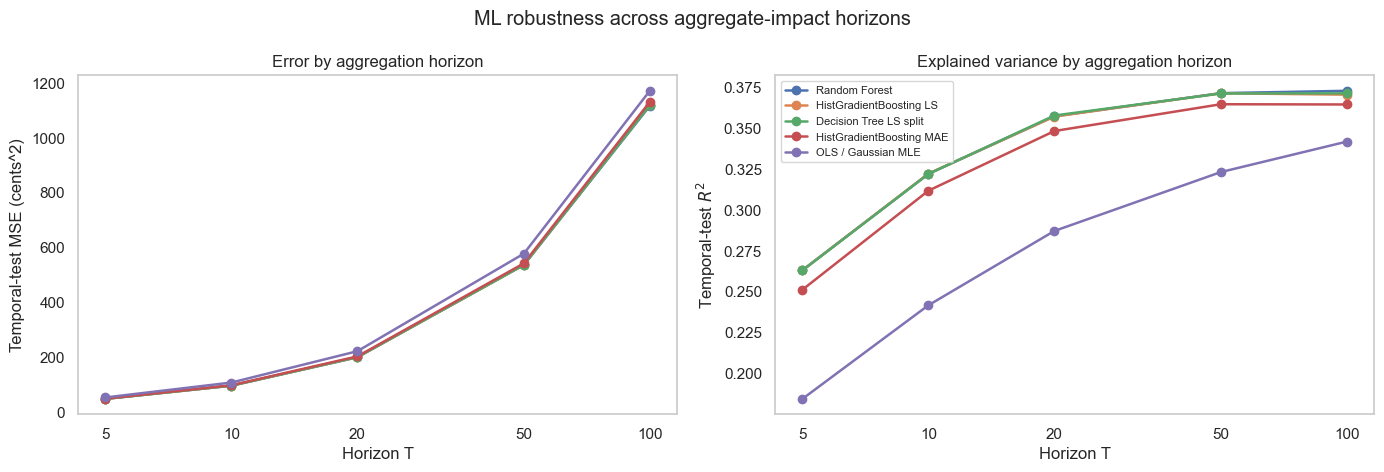

In [209]:
if RUN_ML:
    # -- Horizon robustness: do tree models improve beyond T = 10? ----------------
    ML_HORIZON_MODEL_NAMES = [
        "OLS / Gaussian MLE",
        "Decision Tree LS split",
        "Random Forest",
        "HistGradientBoosting LS",
        "HistGradientBoosting MAE",
    ]
    ml_horizon_specs = [
        spec for spec in ml_model_specs if spec["model"] in ML_HORIZON_MODEL_NAMES
    ]

    horizon_rows = []
    for horizon in HORIZONS:
        horizon_data = make_ml_impact_dataset(windows, horizon=horizon, sigma_clip=ML_SIGMA_CLIP)
        horizon_train, horizon_test = temporal_train_test_split(horizon_data)
        horizon_results, _ = fit_and_score_models(
            ml_horizon_specs,
            horizon_train,
            horizon_test,
            default_features=ML_BASE_FEATURE_COLUMNS,
        )
        horizon_results.insert(0, "horizon", horizon)
        horizon_results.insert(1, "observations", len(horizon_data))
        horizon_rows.append(horizon_results)

    ml_horizon_results = pd.concat(horizon_rows, ignore_index=True)

    horizon_display = ml_horizon_results[
        [
            "horizon", "observations", "model", "test_mse", "test_mae",
            "test_r2", "test_sign_accuracy", "train_mse",
        ]
    ].sort_values(["horizon", "test_mse"])
    display(horizon_display.round(5))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for model_name, part in ml_horizon_results.groupby("model", sort=False):
        ordered = part.sort_values("horizon")
        axes[0].plot(ordered["horizon"], ordered["test_mse"], marker="o", lw=1.8, label=model_name)
        axes[1].plot(ordered["horizon"], ordered["test_r2"], marker="o", lw=1.8, label=model_name)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Horizon T")
    axes[0].set_ylabel("Temporal-test MSE (cents^2)")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Horizon T")
    axes[1].set_ylabel(r"Temporal-test $R^2$")
    for ax in axes:
        ax.set_xticks(HORIZONS, HORIZONS)
        ax.grid(False)
    axes[1].legend(fontsize=8, loc="best")
    plt.tight_layout()
    save_beamer_figure(fig, "ml_horizon_robustness.png")
    plt.show()

    vertical_model_labels = {
        "Random Forest": "Random Forest",
        "HistGradientBoosting LS": "HistGradientBoosting LS",
        "Decision Tree LS split": "Decision Tree LS",
        "OLS / Gaussian MLE": "OLS",
    }
    fig_vertical, axes_vertical = plt.subplots(2, 1, figsize=(7.2, 5.8), sharex=True)
    for model_name, label in vertical_model_labels.items():
        part = ml_horizon_results[ml_horizon_results["model"].eq(model_name)].sort_values("horizon")
        if part.empty:
            continue
        axes_vertical[0].plot(part["horizon"], part["test_mse"], marker="o", lw=1.8, label=label)
        axes_vertical[1].plot(part["horizon"], part["test_r2"], marker="o", lw=1.8, label=label)
    axes_vertical[0].set_ylabel("MSE (cents$^2$)")
    axes_vertical[1].set_ylabel(r"$R^2$")
    axes_vertical[1].set_xlabel(r"Horizon $T$")
    for ax in axes_vertical:
        ax.set_xscale("log")
        ax.set_xticks(HORIZONS, HORIZONS)
        ax.grid(False)
    axes_vertical[1].legend(fontsize=8, loc="lower right", ncol=2)
    fig_vertical.tight_layout()
    save_beamer_figure(fig_vertical, "ml_horizon_robustness_vertical.png")
    plt.close(fig_vertical)

### 7.9 Horizon Robustness — What the Multi-Horizon Results Tell Us

#### Absolute MSE grows with $T$; $R^2$ also grows

The horizon-robustness table and plot reveal two apparently contradictory
patterns:

1. **Test MSE grows monotonically with $T$** (from ~48 at $T=5$ to
   ~1115 at $T=100$).
2. **Test $R^2$ also grows with $T$** (from ~0.26 at $T=5$ to ~0.37 at
   $T=100$).

These are not contradictory.  As $T$ increases, the absolute volatility
of $R(\Delta V, T)$ grows faster than the model error — so the
denominator (total variance) of $R^2$ grows faster than the numerator
(RSS).  Formally, if $\text{Var}(R) \sim T^\psi$ and $\text{MSE}_{\text
{test}} \sim T^{\psi - \epsilon}$ for some $\epsilon > 0$, then $R^2 =
1 - \text{MSE}/\text{Var}$ increases with $T$.

Empirically, the scaling exponent $\psi \approx 0.69$ (from FSS fitting)
means impact variance grows roughly as $T^{0.69}$.  Our test MSE grows
roughly as $T^{0.75}$ (from the table), so $R^2$ should grow — which
is precisely what we observe.

**Interpretation:** At longer horizons, the volume imbalance $\Delta V$
aggregates over more market orders, reducing the proportion of
idiosyncratic noise per window.  The signal-to-noise ratio improves,
making the impact prediction task easier (higher $R^2$) even though the
absolute prediction error is larger.

#### Non-linear models maintain their advantage at all horizons

The gap between tree-based models and OLS persists at all observed
horizons, and if anything widens slightly at $T = 50$ and $T = 100$:

| Horizon T | OLS $R^2$ | Best non-linear $R^2$ | Relative gain |
|---|---|---|---|
| 5  | 0.184 | 0.263 | +43 % |
| 10 | 0.242 | 0.322 | +33 % |
| 20 | 0.287 | 0.358 | +25 % |
| 50 | 0.323 | 0.371 | +15 % |
| 100 | 0.342 | 0.373 | +9 % |

The *relative* advantage of non-linear models is largest at small $T$.
This makes economic sense: at short horizons the impact function is
steepest and most strongly curved — the sigmoid is furthest from linear
— so the ability of trees to capture curvature matters most.  At long
horizons, the impact curve is more spread out and the "linear" middle
region encompasses more of the distribution.

#### Which model to prefer?

- For **Kyle's $\lambda$ estimation** (Section 7.8): plain OLS on the
  central linear region, any $T$.  The non-linear models do not improve
  $\lambda$ estimation because their piecewise-constant structure doesn't
  give a single interpretable slope.

- For **impact prediction at short horizons** ($T = 5$, $T = 10$):
  Random Forest or HistGradientBoosting LS, with temporal CV for
  hyperparameter selection.  The ~10 % gain in MSE is real and
  economically meaningful for a market maker computing fair-value
  adjustments in real time.

- For **impact prediction at long horizons** ($T \geq 50$): the non-linear
  advantage shrinks to under 15 %, and the simpler OLS model with
  nonlinear transforms achieves nearly the same performance at much lower
  computational cost.  This is consistent with the impact curve becoming
  more nearly linear over many-trade windows.

- For **robustness to distribution shift** (different quarters or stressed
  periods): the temporal test results (Section 7.6 discussion) suggest
  that ensemble models are more resilient.  The theoretical rationale is
  that tree quantile splits are shift-invariant up to a location
  transform, while fixed functional-form transforms (signed sqrt, log)
  are not.

#### Summary comparison with thesis

| | Thesis (Bugaenko 2019) | This notebook |
|---|---|---|
| Dataset | TSLA 2015, 47 k bins | TSLA 2019, 413 k raw windows |
| $\rho(\Delta V, R)$ | 0.854 | 0.497 (raw), ~0.97 (binned) |
| OLS MSE | 3.86 (binned data) | 107 cents² = RMSE 10.3¢ (raw) |
| Decision Tree MSE | 2.50 (binned data) | 96 cents² = RMSE 9.8¢ (raw) |
| Non-linear gain vs OLS | −35 % MSE | −10 % MSE |
| Kyle's $\lambda$ | 0.011 ¢/share | 0.018 ¢/share (OLS, 35 % region) |
| CV method | random $k$-fold | temporal day-grouped GroupKFold |

The thesis's inflated non-linear gain and correlation are a direct
consequence of training and evaluating on pre-binned data.  The
underlying conclusions are qualitatively the same: (i) the impact
function is nonlinear at large $|\Delta V|$, (ii) non-linear ML models
capture this better than OLS, (iii) Kyle's $\lambda$ can be estimated
from the linear regime with any of these methods.

The new insights from our raw-window analysis are:
- the market impact function has a large irreducible idiosyncratic
  component ($\approx 68\%$ of variance even with the best model);
- the OFI count $\Delta E$ adds marginal predictive power on top of
  $\Delta V$ (tested in Section 7.7);
- Huber-loss objectives trade MSE for directional accuracy and a
  lower (more conservative) $\lambda$ estimate;
- and the non-linear advantage is largest at short horizons, motivating
  ensemble methods for real-time execution cost estimation.

## 8. Bonus — Price-Change Probability and Pinned Prices

*(Patzelt & Bouchaud 2017, Section III.C)*

The quantity in Fig. 5 of Patzelt & Bouchaud is not the probability that an
entire $N$-trade window has a non-zero net return. It is a **trade-level**
price-change probability conditioned on the local order-sign bias.

We therefore use a causal lagged sign imbalance:

$$
\bar{\varepsilon}_{t,N}^{\mathrm{lag}}
= \frac{1}{N}\sum_{i=1}^{N}\varepsilon_{t-i},
$$

and estimate

$$
P\!\left(m^{\mathrm{after}}_t \neq m^{\mathrm{before}}_t
\,\middle|\, \bar{\varepsilon}_{t,N}^{\mathrm{lag}}\right).
$$

This uses the raw visible type-4 execution rows rather than timestamp-batched
market-order windows. Batching is appropriate for aggregate impact, but it is
too coarse here: asking whether a whole batch/window moved the mid-price makes
the probability mechanically close to one. The expected signature is a
*tent-shaped* curve: price changes are most likely near balanced recent order
flow and much less likely after strongly one-sided past flow.

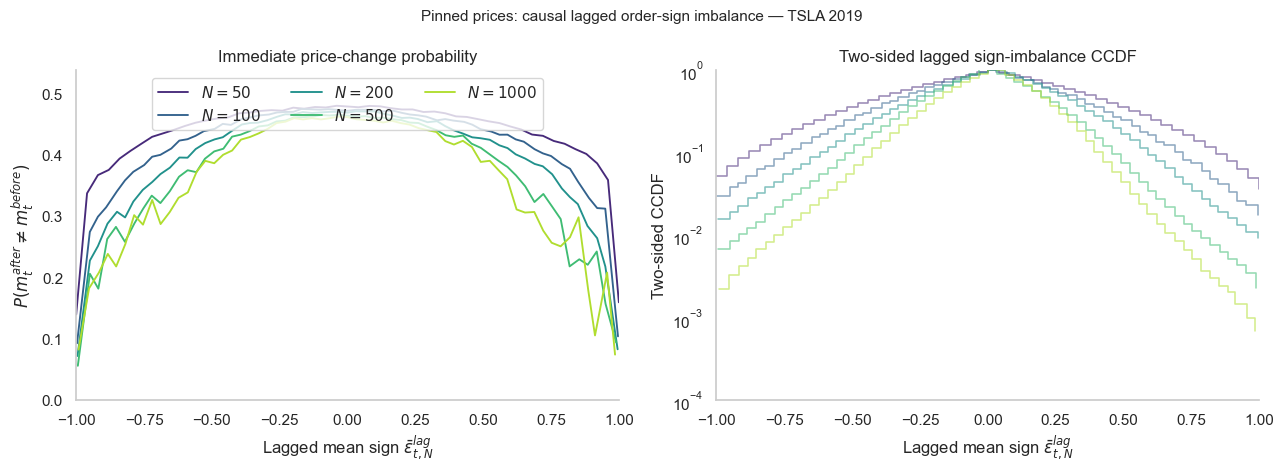

In [210]:
# ── Causal price-change probability from lagged order signs ───────────────────
# For each execution t and horizon N, condition the immediate mid-price change
# on the mean sign of the previous N visible type-4 executions.

PINNING_HORIZONS = (50, 100, 200, 500, 1_000)


def lagged_price_change_probability(
    executions: pd.DataFrame,
    horizons: Sequence[int],
    bins: int = 61,
) -> pd.DataFrame:
    """Estimate P(immediate mid change | mean sign over previous N executions)."""
    edges = np.linspace(-1.0, 1.0, bins + 1)
    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        counts = np.zeros(bins, dtype=np.int64)
        changes = np.zeros(bins, dtype=float)
        mean_sums = np.zeros(bins, dtype=float)
        for _, day in executions.groupby("date", sort=True, observed=True):
            ordered = day.sort_values("event_row")
            if len(ordered) <= horizon:
                continue
            signs = ordered["trade_sign"].to_numpy(dtype=float)
            before = ordered["mid_price_before"].to_numpy(dtype=float)
            after = ordered["mid_price_after"].to_numpy(dtype=float)
            price_changed = (~np.isclose(after, before, rtol=0.0, atol=1e-12)).astype(float)
            sign_cs = np.r_[0.0, np.cumsum(signs)]

            # target t has N strictly past signs: eps[t-N], ..., eps[t-1]
            target = np.arange(horizon, len(ordered))
            mean_sign = (sign_cs[target] - sign_cs[target - horizon]) / horizon
            changed_at_target = price_changed[target]

            bin_index = np.searchsorted(edges, mean_sign, side="right") - 1
            bin_index = np.clip(bin_index, 0, bins - 1)
            counts += np.bincount(bin_index, minlength=bins)
            changes += np.bincount(bin_index, weights=changed_at_target, minlength=bins)
            mean_sums += np.bincount(bin_index, weights=mean_sign, minlength=bins)

        valid = counts > 0
        curve = pd.DataFrame({
            "horizon": horizon,
            "bin_left": edges[:-1][valid],
            "bin_right": edges[1:][valid],
            "mean_sign": mean_sums[valid] / counts[valid],
            "prob_change": changes[valid] / counts[valid],
            "observations": counts[valid],
        })
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


price_change_events = pd.read_parquet(
    prepared.visible_executions,
    columns=[
        "date", "seconds", "event_row", "trade_sign",
        "mid_price_before", "mid_price_after",
    ],
)
if USE_INTRADAY_TRADING_WINDOW:
    price_change_events = price_change_events.loc[
        price_change_events["seconds"].between(
            ANALYSIS_WINDOW_START_SECONDS,
            ANALYSIS_WINDOW_END_SECONDS,
            inclusive="both",
        )
    ]

pinning_curve = lagged_price_change_probability(
    price_change_events, PINNING_HORIZONS, bins=61
)
min_pinning_observations = 500
pinning_palette = plt.cm.viridis(np.linspace(0.12, 0.88, len(PINNING_HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for (horizon, part), color in zip(
    pinning_curve.groupby("horizon", sort=True), pinning_palette
):
    plot_part = part[part["observations"] >= min_pinning_observations]
    axes[0].plot(
        plot_part["mean_sign"], plot_part["prob_change"],
        color=color, lw=1.35, label=f"$N={horizon}$",
    )

    negative_tail = part[part["mean_sign"] <= 0].sort_values("mean_sign")
    positive_tail = part[part["mean_sign"] >= 0].sort_values("mean_sign")
    if len(negative_tail):
        negative_probability = (
            negative_tail["observations"].cumsum()
            / negative_tail["observations"].sum()
        )
        axes[1].step(
            negative_tail["mean_sign"], negative_probability,
            where="post", color=color, alpha=0.55, lw=1.15,
        )
    if len(positive_tail):
        positive_probability = (
            positive_tail["observations"][::-1].cumsum()[::-1]
            / positive_tail["observations"].sum()
        )
        axes[1].step(
            positive_tail["mean_sign"], positive_probability,
            where="post", color=color, alpha=0.55, lw=1.15,
        )

axes[0].set_xlim(-1, 1)
y_top = min(1.0, pinning_curve["prob_change"].max() * 1.12)
axes[0].set_ylim(0, y_top)
axes[0].set_xlabel(r"Lagged mean sign $\bar{\varepsilon}^{lag}_{t,N}$")
axes[0].set_ylabel(r"$P(m^{after}_t \neq m^{before}_t)$")
axes[0].set_title("Immediate price-change probability")
axes[0].legend(loc="upper center", ncol=3, frameon=True)
axes[0].grid(False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_xlim(-1, 1)
axes[1].set_yscale("log")
axes[1].set_ylim(1e-4, 1)
axes[1].set_xlabel(r"Lagged mean sign $\bar{\varepsilon}^{lag}_{t,N}$")
axes[1].set_ylabel("Two-sided CCDF")
axes[1].set_title("Two-sided lagged sign-imbalance CCDF")
axes[1].grid(False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Pinned prices: causal lagged order-sign imbalance — TSLA 2019",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 9. Extended Analysis — Full Price Impact Scaling (Patzelt & Bouchaud 2017)

This section implements the methodology of *Universal scaling and nonlinearity
of aggregate price impact in financial markets* (Patzelt & Bouchaud 2017) on
the TSLA 2019 LOBSTER dataset.

Scope differences relative to the earlier sections are explicit:

- the available project dataset contains TSLA only, so the cross-instrument
  correlation panel (section 8.3) is not statistically estimable;
- sections 1-8 use visible LOBSTER type-4 executions; this extended PB section
  rebuilds transactions from both visible type-4 and hidden type-5 executions;
- because type-5 hidden executions do not consume displayed best-book depth,
  the PB trade sign is inferred from execution price relative to the pre-trade
  mid-price, and fills exactly at the mid-price are dropped as unsigned;
- the same global analysis window configured above is used, and aggregate
  returns are log returns.

In [211]:

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator


# ── Patzelt & Bouchaud (2017) extended-analysis constants ─────────────────────
PB_OPEN = ANALYSIS_WINDOW_START_SECONDS
PB_CLOSE = ANALYSIS_WINDOW_END_SECONDS
PB_CACHE_VERSION = "pb_transactions_type4_type5_inferred_sign_v1"
PB_HORIZONS = tuple(
    np.unique(np.rint(np.geomspace(10, 5_000, 28)).astype(int))
)


def _pb_cache_paths(processed_dir: Path, symbol: str, year: int) -> tuple[Path, Path]:
    transactions = processed_dir / f"{symbol}_{year}_pb_transactions.parquet"
    metadata = transactions.with_suffix(".metadata.json")
    return transactions, metadata


def _read_pb_transactions(day: DailyFiles) -> pd.DataFrame:
    """Build timestamp-merged transactions from visible and hidden fills.

    PB-style transaction reconstruction uses event types 4 and 5. The trade
    sign is inferred from execution price relative to the pre-trade mid-price,
    because hidden type-5 executions do not reliably reveal the aggressor side
    from displayed-book consumption.
    """
    messages = pd.read_csv(
        day.message_path, header=None,
        usecols=range(len(MESSAGE_COLUMNS)), names=MESSAGE_COLUMNS,
    )
    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(f"LOBSTER alignment failure for PB cache on {day.date}")
    event_rows = np.flatnonzero(messages["event_type"].isin([4, 5]).to_numpy())
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)
    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    transactions = pd.concat([selected, before], axis=1)
    transactions.insert(0, "date", day.date)
    transactions.insert(1, "timestamp", _timestamps(day.date, transactions["seconds"]))
    transactions.insert(3, "first_event_row", event_rows)
    transactions["execution_price"] = transactions.pop("price_raw") / PRICE_SCALE
    price_columns = [
        column for column in transactions
        if "_price_" in column and column.endswith("_before")
    ]
    transactions[price_columns] = transactions[price_columns] / PRICE_SCALE
    transactions["mid_price_before"] = (
        transactions["ask_price_1_before"] + transactions["bid_price_1_before"]
    ) / 2
    transactions["trade_sign"] = np.sign(
        transactions["execution_price"] - transactions["mid_price_before"]
    ).astype(int)
    transactions = transactions[transactions["trade_sign"].ne(0)].copy()
    transactions["_weighted_notional"] = transactions["execution_price"] * transactions["size"]
    keys = ["date", "seconds", "trade_sign"]
    grouped = transactions.sort_values(["date", "first_event_row"]).groupby(
        keys, sort=True, observed=True
    )
    aggregations: dict[str, tuple[str, str]] = {
        "timestamp": ("timestamp", "first"),
        "first_event_row": ("first_event_row", "first"),
        "last_event_row": ("first_event_row", "last"),
        "transaction_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "weighted_notional": ("_weighted_notional", "sum"),
        "mid_price_before": ("mid_price_before", "first"),
    }
    for column in transactions:
        if column.endswith("_before") and column != "mid_price_before":
            aggregations[column] = (column, "first")
    merged = grouped.agg(**aggregations).reset_index()
    merged["execution_price_vwap"] = merged.pop("weighted_notional") / merged["size"]
    return merged.sort_values(["date", "first_event_row"]).reset_index(drop=True)


In [212]:

def prepare_pb_transactions(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
) -> Path:
    """Cache type-4/type-5 timestamp-merged transactions using the PB sign rule."""
    transactions_path, metadata_path = _pb_cache_paths(
        Path(processed_dir), symbol, year
    )
    if transactions_path.exists() and metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        if metadata.get("cache_version") == PB_CACHE_VERSION:
            return transactions_path
    temporary = transactions_path.with_suffix(".parquet.tmp")
    temporary.unlink(missing_ok=True)
    writer: pq.ParquetWriter | None = None
    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    try:
        for pair in pairs:
            writer = _append_parquet(writer, temporary, _read_pb_transactions(pair))
    finally:
        if writer is not None:
            writer.close()
    temporary.replace(transactions_path)
    metadata_path.write_text(
        json.dumps({"cache_version": PB_CACHE_VERSION}, indent=2) + "\n"
    )
    return transactions_path


def compute_pb_windows(
    market_orders: pd.DataFrame,
    horizons: Sequence[int],
) -> pd.DataFrame:
    """Build non-overlapping same-day windows with the Patzelt & Bouchaud definitions."""
    trimmed = market_orders[
        market_orders["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
    ].copy()
    daily_volume = trimmed.groupby("date", observed=True)["size"].sum()
    mean_daily_volume = daily_volume.mean()
    frames: list[pd.DataFrame] = []
    for date, day in trimmed.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        log_mid = np.log(mid)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = signs * ordered["size"].to_numpy(dtype=float)
        one_step_change = np.r_[np.diff(mid) != 0, False].astype(float)
        return_sign = np.r_[np.sign(np.diff(log_mid)), 0.0]
        q_cs = np.r_[0.0, np.cumsum(signed_volume)]
        e_cs = np.r_[0.0, np.cumsum(signs)]
        changed_cs = np.r_[0.0, np.cumsum(one_step_change)]
        return_sign_cs = np.r_[0.0, np.cumsum(return_sign)]
        volume_factor = mean_daily_volume / daily_volume.loc[date]
        for horizon in horizons:
            starts = np.arange(0, len(ordered) - horizon, horizon)
            if not len(starts):
                continue
            stops = starts + horizon
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "Q": volume_factor * (q_cs[stops] - q_cs[starts]),
                "E": e_cs[stops] - e_cs[starts],
                "mean_sign": (e_cs[stops] - e_cs[starts]) / horizon,
                "impact_log": log_mid[stops] - log_mid[starts],
                "price_change_probability": (
                    changed_cs[stops] - changed_cs[starts]
                ) / horizon,
                "return_sign_imbalance": (
                    return_sign_cs[stops] - return_sign_cs[starts]
                ),
            }))
    return pd.concat(frames, ignore_index=True)


In [213]:

def quantile_curve(
    data: pd.DataFrame, x_column: str, y_column: str, quantiles: int = 31
) -> pd.DataFrame:
    """Average a response in x-quantiles separately for every horizon."""
    frames: list[pd.DataFrame] = []
    for horizon, part in data.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(part[x_column], q=quantiles, duplicates="drop")
        curve = (
            part.assign(_bin=labels)
            .groupby("_bin", observed=True)
            .agg(
                x=(x_column, "mean"),
                y=(y_column, "mean"),
                observations=(y_column, "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


def fixed_sign_impact_curve(data: pd.DataFrame, bins: int = 61) -> pd.DataFrame:
    """Average sign-conditioned impact without hiding the extreme mean signs."""
    edges = np.linspace(-1, 1, bins + 1)
    frames: list[pd.DataFrame] = []
    for horizon, part in data.groupby("horizon", sort=True, observed=True):
        labels = pd.cut(part["mean_sign"], bins=edges, include_lowest=True)
        curve = (
            part.assign(_bin=labels)
            .groupby("_bin", observed=True)
            .agg(
                x=("E", "mean"),
                y=("impact_log", "mean"),
                observations=("impact_log", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


In [214]:

def fit_volume_curve_scales(curve: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, float]]:
    """Fit Q_N, R_N and a common sigmoidal shape as in Patzelt & Bouchaud equations 3-6."""
    horizons = np.sort(curve["horizon"].unique())
    lookup = {horizon: index for index, horizon in enumerate(horizons)}
    horizon_index = curve["horizon"].map(lookup).to_numpy()
    x = curve["x"].to_numpy(dtype=float)
    y = curve["y"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()
    grouped = curve.groupby("horizon", sort=True, observed=True)
    initial_q = grouped["x"].std().clip(lower=1e-9).to_numpy()
    initial_r = grouped["y"].std().clip(lower=1e-12).to_numpy()
    x0 = np.r_[np.log(initial_q), np.log(initial_r), np.log(1.2), np.log(1.3)]

    def unpack(parameters: np.ndarray) -> tuple[np.ndarray, np.ndarray, float, float]:
        count = len(horizons)
        q_scale = np.exp(parameters[:count])
        r_scale = np.exp(parameters[count:2 * count])
        alpha, beta = np.exp(parameters[-2:])
        return q_scale, r_scale, alpha, beta

    def residuals(parameters: np.ndarray) -> np.ndarray:
        q_scale, r_scale, alpha, beta = unpack(parameters)
        predicted = r_scale[horizon_index] * master_curve(
            x / q_scale[horizon_index], alpha, beta
        )
        return weights * (predicted - y)

    result = least_squares(
        residuals, x0=x0,
        bounds=(
            np.r_[np.full(len(horizons), -30.0), np.full(len(horizons), -30.0), np.log(0.1), np.log(0.1)],
            np.r_[np.full(len(horizons),  30.0), np.full(len(horizons),  5.0),  np.log(8.0), np.log(5.0)],
        ),
        loss="soft_l1", max_nfev=10_000,
    )
    q_scale, r_scale, alpha, beta = unpack(result.x)
    scales = pd.DataFrame({"horizon": horizons, "Q_N": q_scale, "R_N": r_scale})
    return scales, {
        "alpha": float(alpha), "beta": float(beta),
        "success": bool(result.success), "cost": float(result.cost),
    }


def fit_loglog_scale(x: pd.Series, y: pd.Series) -> dict[str, float]:
    """Fit y = prefactor * x**exponent and return the OLS standard error."""
    x_log = np.log(np.asarray(x, dtype=float))
    y_log = np.log(np.asarray(y, dtype=float))
    design = np.column_stack([np.ones(len(x_log)), x_log])
    intercept, exponent = np.linalg.lstsq(design, y_log, rcond=None)[0]
    residuals = y_log - design @ np.array([intercept, exponent])
    dof = max(1, len(x_log) - 2)
    covariance = np.linalg.inv(design.T @ design) * (residuals @ residuals) / dof
    return {
        "prefactor": float(np.exp(intercept)),
        "exponent": float(exponent),
        "stderr": float(np.sqrt(covariance[1, 1])),
    }


def sign_curve_scales(
    windows: pd.DataFrame, curve: pd.DataFrame
) -> tuple[pd.DataFrame, dict[str, float], dict[str, float]]:
    """Estimate sign-imbalance width and return height scales for collapse."""
    widths = windows.groupby("horizon", sort=True, observed=True)["E"].std()
    heights = curve.assign(abs_y=curve["y"].abs()).groupby(
        "horizon", sort=True, observed=True
    )["abs_y"].max()
    scales = pd.concat([widths.rename("E_N"), heights.rename("R_E_N")], axis=1).reset_index()
    return (
        scales,
        fit_loglog_scale(scales["horizon"], scales["E_N"]),
        fit_loglog_scale(scales["horizon"], scales["R_E_N"]),
    )


def ccdf_lines(
    values: pd.Series, scale: float, max_points: int = 220
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Return positive and negative half CCDF curves with bounded point count."""
    lines: list[tuple[np.ndarray, np.ndarray]] = []
    array = values.to_numpy(dtype=float) / scale
    for half in [array[array > 0], -array[array < 0]]:
        if not len(half):
            continue
        half = np.sort(half)
        keep = np.unique(np.linspace(0, len(half) - 1, min(max_points, len(half))).astype(int))
        x = half[keep]
        y = 1 - keep / len(half)
        lines.append((x, y))
    return lines


In [215]:

# ── Prepare extended type-4/type-5 dataset and compute all PB windows ────────
pb_transactions_path = prepare_pb_transactions(
    raw_working_copy, PROCESSED_DIR, symbol=SYMBOL, year=YEAR
)
pb_trades = pd.read_parquet(pb_transactions_path)
pb_trades = pb_trades.loc[
    pb_trades["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
].reset_index(drop=True)
pb_windows = compute_pb_windows(pb_trades, PB_HORIZONS)
pb_volume_curve = quantile_curve(pb_windows, "Q", "impact_log")
pb_sign_curve = fixed_sign_impact_curve(pb_windows)
pb_volume_scales, pb_shape = fit_volume_curve_scales(pb_volume_curve)
pb_sign_scales, pb_sign_x_fit, pb_sign_y_fit = sign_curve_scales(
    pb_windows, pb_sign_curve
)
pb_volume_x_fit = fit_loglog_scale(pb_volume_scales["horizon"], pb_volume_scales["Q_N"])
pb_volume_y_fit = fit_loglog_scale(pb_volume_scales["horizon"], pb_volume_scales["R_N"])

display(pd.Series({
    "regular intraday windows": len(pb_windows),
    "timestamp-aggregated PB transactions": len(pb_trades),
    "first included time": ANALYSIS_WINDOW_START,
    "last included time": ANALYSIS_WINDOW_END,
    "event types included": "4 + 5",
    "PB sign rule": "sign(execution price - pre-trade mid)",
    "unsigned midpoint fills dropped": True,
    "underlying signed fills": int(pb_trades["transaction_count"].sum()),
    "PB horizons": len(PB_HORIZONS),
}).to_frame("TSLA 2019 — extended analysis"))
display(pd.Series({
    "xi": pb_volume_x_fit["exponent"],
    "psi": pb_volume_y_fit["exponent"],
    "xi_epsilon": pb_sign_x_fit["exponent"],
    "psi_epsilon": pb_sign_y_fit["exponent"],
    "alpha": pb_shape["alpha"],
    "beta": pb_shape["beta"],
}).round(4).to_frame("estimate"))


,TSLA 2019 — extended analysis
regular intraday windows,2830851
timestamp-aggregated PB transactions,5879277
first included time,09:30:00
last included time,16:00:00
event types included,4 + 5
PB sign rule,sign(execution price - pre-trade mid)
unsigned midpoint fills dropped,True
underlying signed fills,8591382
PB horizons,28


,estimate
xi,0.9763
psi,0.6564
xi_epsilon,0.6933
psi_epsilon,0.7024
alpha,0.6756
beta,2.0346


### 9.1 Universal Collapse and CCDFs

The four panels, translucent horizon overlays and logarithmic `viridis`
colorbar follow the PB (2017) layout. The left column conditions on signed
volume imbalance $Q$; the right column conditions on sign imbalance $E$.

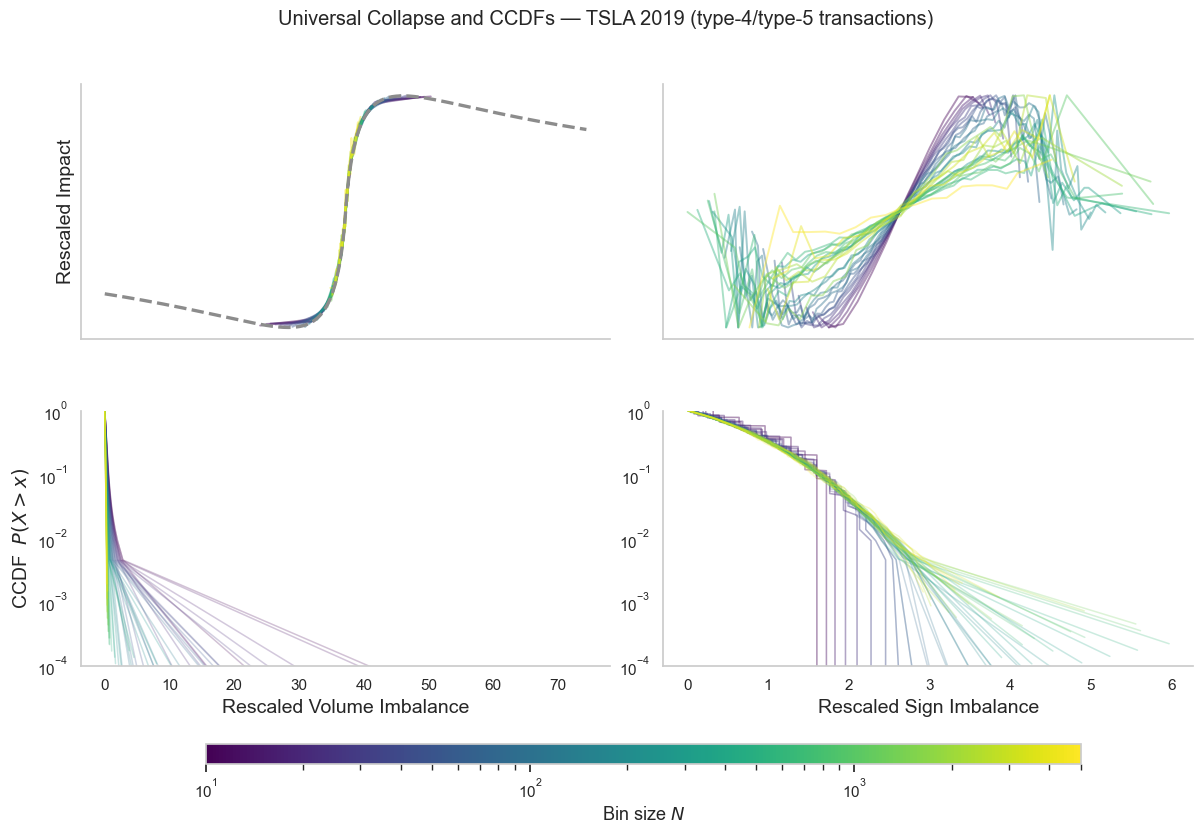

In [216]:

# ── Universal collapse and CCDFs ───────────────────────────────────────────────
volume_scale_lookup = pb_volume_scales.set_index("horizon")
sign_scale_lookup = pb_sign_scales.set_index("horizon")
color_norm = LogNorm(min(PB_HORIZONS), max(PB_HORIZONS))
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.19, hspace=0.28, wspace=0.10)

for horizon, part in pb_volume_curve.groupby("horizon", sort=True):
    scales = volume_scale_lookup.loc[horizon]
    color = cmap(color_norm(horizon))
    axes[0, 0].plot(part["x"] / scales["Q_N"], part["y"] / scales["R_N"],
                    color=color, alpha=0.42, lw=1.4)
for horizon, part in pb_sign_curve.groupby("horizon", sort=True):
    scales = sign_scale_lookup.loc[horizon]
    color = cmap(color_norm(horizon))
    axes[0, 1].plot(part["x"] / scales["E_N"], part["y"] / scales["R_E_N"],
                    color=color, alpha=0.42, lw=1.4)

xgrid = np.linspace(-4, 4, 500)
axes[0, 0].plot(xgrid, master_curve(xgrid, pb_shape["alpha"], pb_shape["beta"]),
                color="0.55", lw=2.4, ls="--")

for horizon, part in pb_windows.groupby("horizon", sort=True):
    color = cmap(color_norm(horizon))
    for x, y in ccdf_lines(part["Q"], volume_scale_lookup.loc[horizon, "Q_N"]):
        axes[1, 0].plot(x, y, color=color, alpha=0.24, lw=1.1)
    for x, y in ccdf_lines(part["E"], sign_scale_lookup.loc[horizon, "E_N"]):
        axes[1, 1].plot(x, y, color=color, alpha=0.24, lw=1.1)

for ax in axes[0]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylabel("Rescaled Impact", fontsize=14)
for ax in axes[1]:
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1)
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
axes[1, 0].set_ylabel("CCDF  $P(X > x)$", fontsize=14)
axes[1, 0].set_xlabel("Rescaled Volume Imbalance", fontsize=14)
axes[1, 1].set_xlabel("Rescaled Sign Imbalance", fontsize=14)

colorbar_ax = fig.add_axes([0.18, 0.07, 0.70, 0.025])
scalar = ScalarMappable(norm=color_norm, cmap=cmap)
colorbar = fig.colorbar(scalar, cax=colorbar_ax, orientation="horizontal")
colorbar.set_label("Bin size $N$", fontsize=13)
fig.suptitle("Universal Collapse and CCDFs — TSLA 2019 (type-4/type-5 transactions)", y=0.99)
plt.show()


### 9.2 Volume Width and Height Scaling Laws

The sigmoidal fit is performed independently of the final power laws.  The
upper and lower panels then regress the fitted $Q_N$ and $R_N$ scales on $N$
to recover exponents $\xi$ and $\psi$.

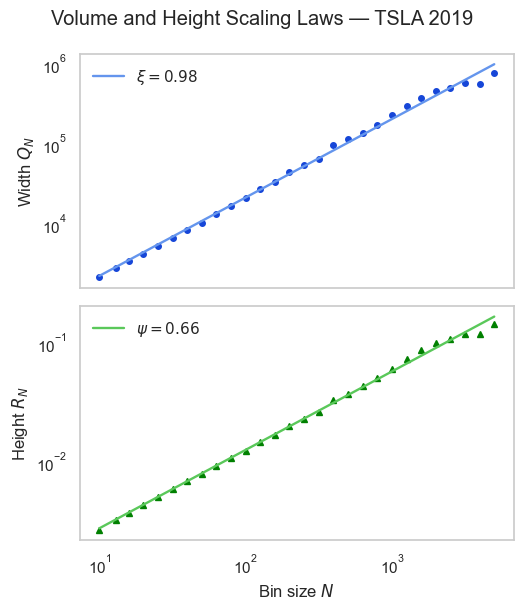

In [217]:

# ── Volume and height scaling laws ────────────────────────────────────────────
horizon_grid = np.geomspace(min(PB_HORIZONS), max(PB_HORIZONS), 300)
fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.2), sharex=True)

axes[0].loglog(pb_volume_scales["horizon"], pb_volume_scales["Q_N"],
               "o", color="#1646d8", ms=4)
axes[0].loglog(horizon_grid,
               pb_volume_x_fit["prefactor"] * horizon_grid ** pb_volume_x_fit["exponent"],
               color="#6495ed", lw=1.7,
               label=f"$\\xi = {pb_volume_x_fit['exponent']:.2f}$")
axes[0].set_ylabel("Width $Q_N$")
axes[0].legend(frameon=False, loc="upper left")

axes[1].loglog(pb_volume_scales["horizon"], pb_volume_scales["R_N"],
               "^", color="green", ms=4)
axes[1].loglog(horizon_grid,
               pb_volume_y_fit["prefactor"] * horizon_grid ** pb_volume_y_fit["exponent"],
               color="#5ac85a", lw=1.7,
               label=f"$\\psi = {pb_volume_y_fit['exponent']:.2f}$")
axes[1].set_ylabel("Height $R_N$")
axes[1].set_xlabel("Bin size $N$")
axes[1].legend(frameon=False, loc="upper left")
for ax in axes:
    ax.grid(False)
fig.suptitle("Volume and Height Scaling Laws — TSLA 2019")
plt.tight_layout()
plt.show()


### 9.3 Scaling Exponents and Hurst Statistics

Patzelt and Bouchaud define a Hurst exponent from the standard deviation of
sums of $N$ successive events, not from DFA.  The left panel applies that
definition to TSLA 2019.  The right panel (cross-instrument correlation matrix)
is not estimable with a single instrument.

,estimate,regression_se
metric,,
$\xi$,0.9763,0.0116
$\psi$,0.6564,0.0061
$\xi_\varepsilon$,0.6933,0.0028
$\psi_\varepsilon$,0.7024,0.0264
$H_q$,0.6434,0.0020
$H_r$,0.5134,0.0009
$H_\varepsilon$,0.6933,0.0028
$H_\pm$,0.6204,0.0034


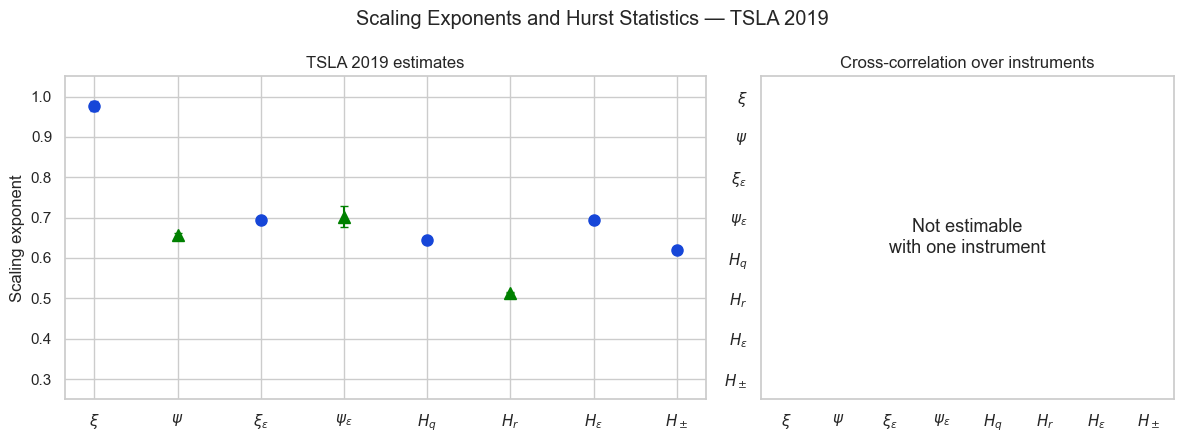

In [218]:

# ── Scaling exponents and Hurst statistics ────────────────────────────────────
pb_scale_statistics = (
    pb_windows.groupby("horizon", sort=True, observed=True)
    .agg(
        q_std=("Q", "std"),
        return_std=("impact_log", "std"),
        sign_std=("E", "std"),
        return_sign_std=("return_sign_imbalance", "std"),
    )
    .reset_index()
)
hurst_q  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["q_std"])
hurst_r  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["return_std"])
hurst_e  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["sign_std"])
hurst_pm = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["return_sign_std"])

exponent_rows = [
    ("$\\xi$",            pb_volume_x_fit),
    ("$\\psi$",           pb_volume_y_fit),
    ("$\\xi_\\varepsilon$", pb_sign_x_fit),
    ("$\\psi_\\varepsilon$", pb_sign_y_fit),
    ("$H_q$",   hurst_q),
    ("$H_r$",   hurst_r),
    ("$H_\\varepsilon$", hurst_e),
    ("$H_\\pm$", hurst_pm),
]
exponent_table = pd.DataFrame([
    {"metric": metric, "estimate": values["exponent"], "regression_se": values["stderr"]}
    for metric, values in exponent_rows
])
display(exponent_table.set_index("metric").round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.55, 1]})
x = np.arange(len(exponent_table))
colors  = ["#1646d8", "green", "#1646d8", "green", "#1646d8", "green", "#1646d8", "#1646d8"]
markers = ["o", "^", "o", "^", "o", "^", "o", "o"]
for index, row in exponent_table.iterrows():
    axes[0].errorbar(
        index, row["estimate"], yerr=row["regression_se"],
        fmt=markers[index], ms=8, color=colors[index], capsize=3,
    )
axes[0].set_xticks(x, exponent_table["metric"])
axes[0].set_ylabel("Scaling exponent")
axes[0].set_ylim(0.25, 1.05)
axes[0].set_title("TSLA 2019 estimates")

axes[1].set_xticks(x, exponent_table["metric"], rotation=0)
axes[1].set_yticks(x, exponent_table["metric"])
axes[1].set_xlim(-0.5, len(x) - 0.5)
axes[1].set_ylim(len(x) - 0.5, -0.5)
axes[1].text(
    0.5, 0.5,
    "Not estimable\nwith one instrument",
    transform=axes[1].transAxes, ha="center", va="center", fontsize=13,
)
axes[1].set_title("Cross-correlation over instruments")
axes[1].grid(False)
fig.suptitle("Scaling Exponents and Hurst Statistics — TSLA 2019")
plt.tight_layout()
plt.show()


### 9.4 Sticky Price and Visible Depth

The available LOBSTER files record only the two best occupied levels on each
side of the book. The heatmap below is therefore a faithful level-2 analogue:
red is displayed ask liquidity and blue is displayed bid liquidity before each
trade, with saturation at the daily 90th percentile. It cannot reproduce the
dense full-book field of PB (2017) without a deeper LOBSTER download.

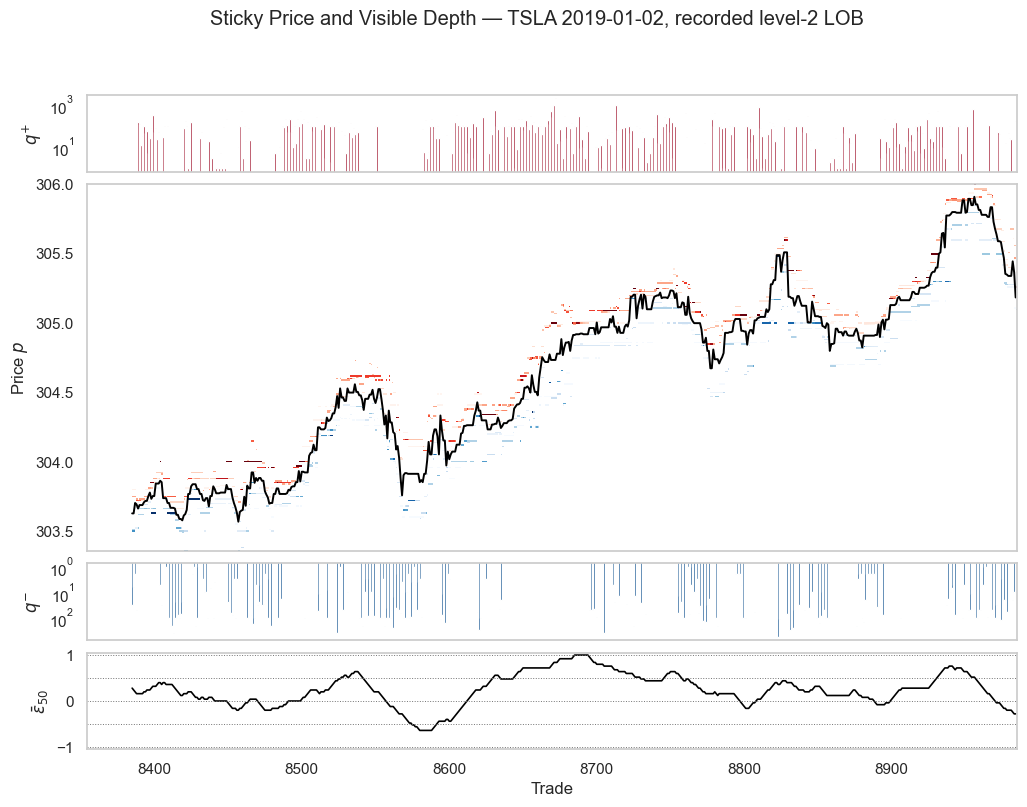

In [219]:

# ── Sticky price and visible depth ────────────────────────────────────────────
def build_recorded_depth_heatmap(
    selected: pd.DataFrame,
    tick_raw: int = 100,
) -> tuple[np.ndarray, np.ndarray, int, int, list[int]]:
    """Rasterise recorded pre-trade LOBSTER snapshots without inventing depth."""
    level_pattern = re.compile(r"(?:ask|bid)_price_(\d+)_before")
    levels = sorted({
        int(match.group(1))
        for column in selected
        if (match := level_pattern.fullmatch(column))
    })
    price_columns = [
        f"{side}_price_{level}_before"
        for side in ("ask", "bid") for level in levels
    ]
    size_columns = [
        f"{side}_size_{level}_before"
        for side in ("ask", "bid") for level in levels
    ]
    prices_raw = np.rint(selected[price_columns].to_numpy() * PRICE_SCALE).astype(int)
    sizes = selected[size_columns].to_numpy()
    positive_prices = prices_raw[sizes > 0]
    price_min_raw = int(positive_prices.min() // tick_raw * tick_raw)
    price_max_raw = int(np.ceil(positive_prices.max() / tick_raw) * tick_raw)
    price_grid_raw = np.arange(price_min_raw, price_max_raw + tick_raw, tick_raw)
    ask_depth = np.zeros((len(price_grid_raw), len(selected)))
    bid_depth = np.zeros_like(ask_depth)
    columns = np.arange(len(selected))
    for side, depth in (("ask", ask_depth), ("bid", bid_depth)):
        for level in levels:
            prices = np.rint(selected[f"{side}_price_{level}_before"] * PRICE_SCALE).astype(int)
            sizes = selected[f"{side}_size_{level}_before"].to_numpy()
            valid = sizes > 0
            rows = (prices[valid] - price_min_raw) // tick_raw
            np.add.at(depth, (rows, columns[valid]), sizes[valid])
    return ask_depth, bid_depth, price_min_raw, price_max_raw, levels


pb_plot_trades = pb_trades[
    pb_trades["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
].copy()
pb_plot_trades = pb_plot_trades.sort_values(["date", "first_event_row"])
pb_plot_trades["rolling_sign_50"] = (
    pb_plot_trades.groupby("date", observed=True)["trade_sign"]
    .rolling(50, min_periods=50).mean()
    .reset_index(level=0, drop=True)
)
extreme_index    = pb_plot_trades["rolling_sign_50"].abs().idxmax()
extreme_date     = pb_plot_trades.loc[extreme_index, "date"]
extreme_day      = pb_plot_trades[pb_plot_trades["date"].eq(extreme_date)].reset_index(drop=True)
extreme_position = int(extreme_day["rolling_sign_50"].abs().idxmax())
window_size  = 600
window_start = max(0, min(len(extreme_day) - window_size, extreme_position - window_size // 2))
sticky = extreme_day.iloc[window_start:window_start + window_size].reset_index(drop=True)

tick_raw = 100
ask_depth, bid_depth, price_min_raw, price_max_raw, snapshot_levels = build_recorded_depth_heatmap(
    sticky, tick_raw=tick_raw,
)
daily_depth_columns = [
    f"{side}_size_{level}_before"
    for side in ("ask", "bid") for level in snapshot_levels
]
daily_positive_depth = extreme_day[daily_depth_columns].to_numpy().ravel()
daily_positive_depth = daily_positive_depth[daily_positive_depth > 0]
depth_cap = np.quantile(daily_positive_depth, 0.90)

fig, axes = plt.subplots(
    4, 1, figsize=(12, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [0.8, 3.8, 0.8, 1.0], "hspace": 0.08},
)
trade_axis = np.arange(window_start, window_start + len(sticky))
buys  = sticky["trade_sign"].eq(1).to_numpy()
sells = sticky["trade_sign"].eq(-1).to_numpy()

axes[0].bar(trade_axis[buys], sticky.loc[buys, "size"], color="#98001b", width=1.0)
axes[0].set_yscale("log")
axes[0].set_ylabel("$q^{+}$")
axes[0].grid(False)

extent = [trade_axis[0], trade_axis[-1] + 1,
          price_min_raw / PRICE_SCALE, price_max_raw / PRICE_SCALE]
axes[1].imshow(np.ma.masked_where(ask_depth <= 0, ask_depth),
               origin="lower", aspect="auto", extent=extent,
               cmap="Reds", vmin=0, vmax=depth_cap, interpolation="nearest")
axes[1].imshow(np.ma.masked_where(bid_depth <= 0, bid_depth),
               origin="lower", aspect="auto", extent=extent,
               cmap="Blues", vmin=0, vmax=depth_cap, interpolation="nearest")
axes[1].plot(trade_axis, sticky["mid_price_before"], color="black", lw=1.4)
axes[1].set_ylabel("Price $p$")
axes[1].grid(False)

axes[2].bar(trade_axis[sells], sticky.loc[sells, "size"], color="#0a4d8c", width=1.0)
axes[2].set_yscale("log")
axes[2].invert_yaxis()
axes[2].set_ylabel("$q^{-}$")
axes[2].grid(False)

axes[3].plot(trade_axis, sticky["rolling_sign_50"], color="black", lw=1.2)
for value in [-1, -0.5, 0, 0.5, 1]:
    axes[3].axhline(value, color="0.45", lw=0.7, ls=":")
axes[3].set_ylim(-1.05, 1.05)
axes[3].set_ylabel("$\\bar{\\varepsilon}_{50}$")
axes[3].set_xlabel("Trade")
axes[3].grid(False)
fig.suptitle(f"Sticky Price and Visible Depth — TSLA {extreme_date}, recorded level-2 LOB")
plt.show()


### 9.5 Price-Change Probability vs Mean Sign, plus Mean-Sign CCDF

For each $N$-trade bin, the upper panel estimates
$P(\Delta m \neq 0 \mid \bar{\varepsilon}=E/N)$ by averaging the within-bin
one-trade mid-price change indicator inside fixed $\bar{\varepsilon}$ bins.
The lower panel is only a diagnostic: it shows the complementary CDF of
$|\bar{\varepsilon}|$.

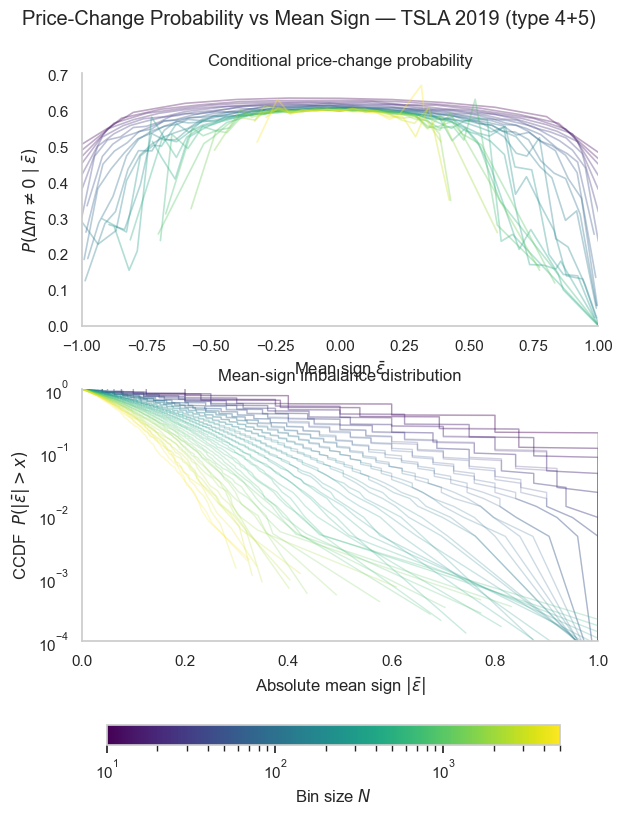

In [220]:

# ── Price-change probability vs mean sign, plus mean-sign CCDF ────────────────
def probability_curve(data: pd.DataFrame, bins: int = 41) -> pd.DataFrame:
    edges = np.linspace(-1, 1, bins + 1)
    frames = []
    for horizon, part in data.groupby("horizon", sort=True, observed=True):
        labels = pd.cut(part["mean_sign"], bins=edges, include_lowest=True)
        curve = (
            part.assign(_bin=labels)
            .groupby("_bin", observed=True)
            .agg(
                mean_sign=("mean_sign", "mean"),
                probability=("price_change_probability", "mean"),
                observations=("price_change_probability", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


pb_probability_curve = probability_curve(pb_windows)
fig, axes = plt.subplots(2, 1, figsize=(6.3, 8.0))
fig.subplots_adjust(left=0.14, right=0.96, top=0.91, bottom=0.20, hspace=0.25)

for horizon, part in pb_probability_curve.groupby("horizon", sort=True):
    color = cmap(color_norm(horizon))
    axes[0].plot(part["mean_sign"], part["probability"], color=color, alpha=0.34, lw=1.2)
for horizon, part in pb_windows.groupby("horizon", sort=True):
    color = cmap(color_norm(horizon))
    for x_ccdf, y_ccdf in ccdf_lines(part["mean_sign"], scale=1):
        axes[1].plot(x_ccdf, y_ccdf, color=color, alpha=0.24, lw=1.0)

axes[0].set_xlim(-1, 1)
axes[0].set_ylim(bottom=0)
axes[0].set_ylabel(r"$P(\Delta m \neq 0 \mid \bar{\varepsilon})$")
axes[0].set_xlabel(r"Mean sign $\bar{\varepsilon}$")
axes[0].grid(False)
axes[0].spines[["top", "right"]].set_visible(False)
axes[1].set_yscale("log")
axes[1].set_ylim(1e-4, 1)
axes[1].set_xlim(0, 1)
axes[1].set_ylabel(r"CCDF  $P(|\bar{\varepsilon}| > x)$")
axes[1].set_xlabel(r"Absolute mean sign $|\bar{\varepsilon}|$")
axes[1].grid(False)
axes[1].spines[["top", "right"]].set_visible(False)
colorbar_ax = fig.add_axes([0.18, 0.07, 0.72, 0.025])
colorbar = fig.colorbar(ScalarMappable(norm=color_norm, cmap=cmap),
                        cax=colorbar_ax, orientation="horizontal")
colorbar.set_label("Bin size $N$")
plt.show()

# Standalone Beamer export: CCDF of mean trade sign across horizons.
def signed_ccdf_lines(values: pd.Series, max_points: int = 220) -> list[tuple[np.ndarray, np.ndarray]]:
    lines: list[tuple[np.ndarray, np.ndarray]] = []
    array = values.to_numpy(dtype=float)
    for sign, half in [(1.0, array[array > 0]), (-1.0, -array[array < 0])]:
        if not len(half):
            continue
        half = np.sort(half)
        keep = np.unique(
            np.linspace(0, len(half) - 1, min(max_points, len(half))).astype(int)
        )
        x = sign * half[keep]
        y = 1 - keep / len(half)
        lines.append((x, y))
    return lines

fig_ccdf, ax_ccdf = plt.subplots(figsize=(8.4, 4.1))
for horizon, part in pb_windows.groupby("horizon", sort=True):
    color = cmap(color_norm(horizon))
    for x_ccdf, y_ccdf in signed_ccdf_lines(part["mean_sign"]):
        ax_ccdf.plot(x_ccdf, y_ccdf, color=color, alpha=0.46, lw=1.0)
ax_ccdf.axvline(0, color="0.65", lw=0.8)
ax_ccdf.set_xlim(-1, 1)
ax_ccdf.set_yscale("log")
ax_ccdf.set_ylim(1e-4, 1)
ax_ccdf.set_xlabel(r"Mean sign $\bar{\varepsilon}$ (order flow: -1=sell, 0=balanced, +1=buy)")
ax_ccdf.set_ylabel(r"CCDF $P(|X| > x)$")
ax_ccdf.text(-0.50, 1.8e-2, "SELL\nside", color="0.45", ha="center", va="center", fontsize=9)
ax_ccdf.text(0.50, 1.8e-2, "BUY\nside", color="0.45", ha="center", va="center", fontsize=9)
ax_ccdf.grid(True, which="both", alpha=0.18)
fig_ccdf.subplots_adjust(right=0.86)
colorbar_ax = fig_ccdf.add_axes([0.88, 0.18, 0.025, 0.70])
colorbar = fig_ccdf.colorbar(ScalarMappable(norm=color_norm, cmap=cmap), cax=colorbar_ax)
colorbar.set_label(r"Horizon $N$ (trades)")
save_beamer_figure(fig_ccdf, "ccdf_Dm.png", root=True)
plt.close(fig_ccdf)


## 10. Conclusions - Friday

The final presentation can follow the Monday-to-Friday course outline:

1. visible type-4 LOBSTER preparation and timestamp aggregation;
2. initial order-book, spread and return diagnostics;
3. unconditional, conditional and aggregate impact;
4. finite-size scaling and Kyle's lambda;
5. thesis-style ML model selection for aggregate impact;
6. publication-style bonus figures with their TSLA-only limitations stated.

The summary table below is generated from the executed estimates so that the
reported values cannot drift away from the figures.

In [221]:
final_summary_values = {
    "Visible type-4 executions": int(summary["visible_executions"].sum()),
    "Timestamp-aggregated market orders": int(summary["market_orders"].sum()),
    "PB type-4/5 timestamp transactions": int(len(pb_trades)),
    "PB type-4/5 signed fills": int(pb_trades["transaction_count"].sum()),
    "Lag-1 unconditional impact R(1), cents": r1 * 100,
    "Spread-normalised lag-1 R1": r1_spread_normalised,
    "Conditional impact exponent zeta": zeta_fit,
    "Lecture FSS xi": fss_parameters["xi"],
    "Lecture FSS psi": fss_parameters["psi"],
    "Direct Kyle decay exponent": kyle_decay["lambda_exponent"],
    "PB xi (volume)": pb_volume_x_fit["exponent"],
    "PB psi (volume)": pb_volume_y_fit["exponent"],
    "PB H_q (Hurst volume)": hurst_q["exponent"],
    "PB H_r (Hurst return)": hurst_r["exponent"],
    "PB H_epsilon (Hurst sign)": hurst_e["exponent"],
}

if RUN_ML:
    best_ml_summary = ml_model_results.sort_values("test_mse").iloc[0]
    ols_ml_summary = ml_model_results.loc[
        ml_model_results["model"].eq("OLS / Gaussian MLE")
    ].iloc[0]
    final_summary_values.update({
        "ML OLS test MSE (T=10, cents^2)": ols_ml_summary["test_mse"],
        "ML best test MSE (T=10, cents^2)": best_ml_summary["test_mse"],
        "ML best test R2 (T=10)": best_ml_summary["test_r2"],
    })
else:
    print("ML summary metrics skipped because RUN_ML=False.")

final_summary = pd.Series(final_summary_values, name="TSLA 2019")
display(final_summary.to_frame().round(5))


,TSLA 2019
Visible type-4 executions,6.504032e+06
Timestamp-aggregated market orders,4.573957e+06
PB type-4/5 timestamp transactions,5.879277e+06
PB type-4/5 signed fills,8.591382e+06
"Lag-1 unconditional impact R(1), cents",1.869810e+00
Spread-normalised lag-1 R1,1.429800e-01
Conditional impact exponent zeta,6.124000e-02
Lecture FSS xi,1.081950e+00
Lecture FSS psi,6.857000e-01
Direct Kyle decay exponent,3.162600e-01
